In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

csv_files = sorted(DATA_DIR.glob("xApvaV01*.csv"))

tables = {}
for path in csv_files:
    name = path.stem.replace("xApvaV01", "")
    tables[name] = pd.read_csv(path)
    print(f"{name:45s} {tables[name].shape}")

list(tables.keys())

BirthQuality                                  (79, 9)
DurationBucketProbabilities                   (156, 7)
DurationBucketTransitions                     (156, 6)
EntryStats                                    (81, 8)
HazardRates                                   (487, 8)
IncubationQualityBucketProbabilities          (160, 7)
IncubationQualityBuckets                      (160, 6)
IncubationQualityConditionalProbabilities     (160, 8)
PersistenceStats                              (79, 6)
PrecursorStats                                (81, 17)
RunLengths                                    (38, 8)
SessionStats                                  (8, 13)
SponsorStates                                 (73, 6)
SponsorTransitions                            (279, 5)
StateLog_ES                                   (448, 20)
StateQuadrupletProbabilities                  (434, 7)
StateQuadruplets                              (434, 5)
StateTripletProbabilities                     (257, 7)
StateTriplets  

['BirthQuality',
 'DurationBucketProbabilities',
 'DurationBucketTransitions',
 'EntryStats',
 'HazardRates',
 'IncubationQualityBucketProbabilities',
 'IncubationQualityBuckets',
 'IncubationQualityConditionalProbabilities',
 'PersistenceStats',
 'PrecursorStats',
 'RunLengths',
 'SessionStats',
 'SponsorStates',
 'SponsorTransitions',
 'StateLog_ES',
 'StateQuadrupletProbabilities',
 'StateQuadruplets',
 'StateTripletProbabilities',
 'StateTriplets',
 'TransitionExpectancy',
 'TransitionProbabilities',
 'Transitions']

In [5]:
precursor = tables["PrecursorStats"]
expectancy = tables["TransitionExpectancy"]
birth = tables["BirthQuality"]
incub_cond = tables["IncubationQualityConditionalProbabilities"]

latest_bar = precursor["TotalBars"].max()

precursor_latest = precursor[precursor["TotalBars"] == latest_bar].copy()
expectancy_latest = expectancy[expectancy["TotalBars"] == latest_bar].copy()
birth_latest = birth[birth["TotalBars"] == latest_bar].copy()
incub_latest = incub_cond[incub_cond["TotalBars"] == latest_bar].copy()

latest_bar

np.int64(400)

In [6]:
cols = [
    "Transition",
    "Entries",
    "MeanPriorRunLength",
    "MeanIncubationQuality",
    "MeanStructuralCompression",
    "MeanEntropicCompression",
    "MeanExpansionPressure",
]

precursor_latest[cols].sort_values(
    "MeanIncubationQuality",
    ascending=False
)

,Transition,Entries,MeanPriorRunLength,MeanIncubationQuality,MeanStructuralCompression,MeanEntropicCompression,MeanExpansionPressure
70,Unresolved->Unknown,1,4.00,0.763,0.446,0.130,0.447
72,Directional->Degrading,10,2.70,0.741,0.466,0.333,0.612
79,Degrading->Directional,3,1.67,0.594,0.523,0.503,0.574
80,Directional->Unresolved,1,3.00,0.590,0.454,0.315,0.451
69,Unknown->Unresolved,2,3.00,0.541,0.458,0.214,0.297
74,Degrading->Balance,5,1.60,0.410,0.525,0.576,0.461
71,Unresolved->Directional,8,13.75,0.378,0.449,0.472,0.394
73,Degrading->Unresolved,17,2.06,0.367,0.457,0.573,0.479
75,Balance->Degrading,4,2.00,0.330,0.543,0.707,0.494
78,Unresolved->Degrading,11,7.27,0.267,0.465,0.612,0.408


In [7]:
precursor_latest.sort_values(
    "MeanIncubationQuality",
    ascending=False
)[
    [
        "Transition",
        "Entries",
        "MeanIncubationQuality",
        "MeanNextRunLength"
    ]
]

KeyError: "['MeanNextRunLength'] not in index"

In [10]:
merged = precursor_latest.merge(
    expectancy_latest[
        [
            "Transition",
            "MeanNextRunLength",
            "ImmediateFailurePct",
            "DirectionalContinuationPct"
        ]
    ],
    on="Transition",
    how="left"
)

merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
)

,Instrument,SessionContext,TotalBars,Transition,Entries,MeanPriorRunLength,MeanSponsorConfidence,MaxSponsorConfidence,MeanDominanceScore,MeanDegradationScore,MeanBalanceScore,EventCount,MeanCompressionScore,MeanExpansionPressure,MeanStructuralCompression,MeanEntropicCompression,MeanIncubationQuality,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
1,ES,RTH,400,Unresolved->Unknown,1,4.00,0.200,0.200,0.256,0.000,0.000,0,0.193,0.447,0.446,0.130,0.763,3.00,0.00,0.00
3,ES,RTH,400,Directional->Degrading,10,2.70,0.632,0.700,0.567,0.449,0.270,11,0.295,0.612,0.466,0.333,0.741,2.20,70.00,0.00
10,ES,RTH,400,Degrading->Directional,3,1.67,0.517,0.600,0.530,0.635,0.410,5,0.414,0.574,0.523,0.503,0.594,1.67,66.67,33.33
11,ES,RTH,400,Directional->Unresolved,1,3.00,0.350,0.550,0.395,0.327,0.249,0,0.330,0.451,0.454,0.315,0.590,2.00,0.00,0.00
0,ES,RTH,400,Unknown->Unresolved,2,3.00,0.250,0.250,0.122,0.066,0.074,4,0.352,0.297,0.458,0.214,0.541,20.50,0.00,0.00
5,ES,RTH,400,Degrading->Balance,5,1.60,0.602,0.700,0.410,0.718,0.506,8,0.460,0.461,0.525,0.576,0.410,1.00,100.00,0.00
2,ES,RTH,400,Unresolved->Directional,8,13.75,0.369,0.800,0.193,0.587,0.394,54,0.347,0.394,0.449,0.472,0.378,3.13,25.00,75.00
4,ES,RTH,400,Degrading->Unresolved,17,2.06,0.548,0.717,0.388,0.765,0.458,34,0.376,0.479,0.457,0.573,0.367,5.53,29.41,0.00
6,ES,RTH,400,Balance->Degrading,4,2.00,0.408,0.700,0.322,0.933,0.636,8,0.437,0.494,0.543,0.707,0.330,1.50,50.00,0.00
9,ES,RTH,400,Unresolved->Degrading,11,7.27,0.369,0.800,0.228,0.810,0.532,52,0.374,0.408,0.465,0.612,0.267,1.82,63.64,0.00


In [9]:
precursor_latest.sort_values(
    "MeanIncubationQuality",
    ascending=False
)[
    [
        "Transition",
        "Entries",
        "MeanIncubationQuality",
        "MeanNextRunLength"
    ]
]

KeyError: "['MeanNextRunLength'] not in index"

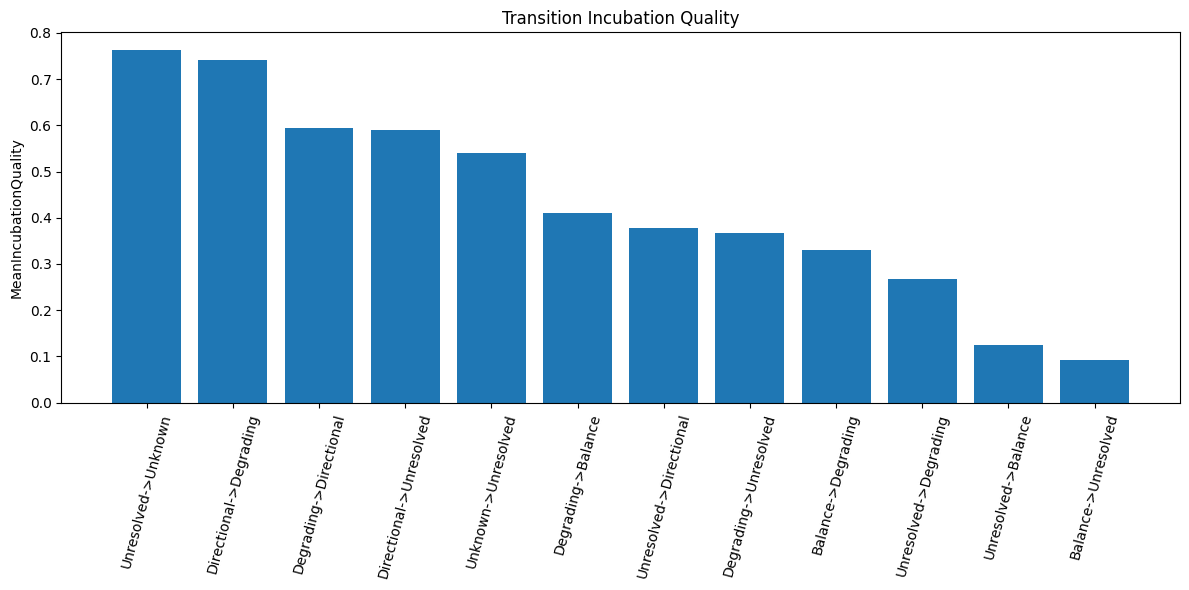

In [11]:
plt.figure(figsize=(12,6))

plot_df = merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
)

plt.bar(
    plot_df["Transition"],
    plot_df["MeanIncubationQuality"]
)

plt.xticks(rotation=75)
plt.ylabel("MeanIncubationQuality")
plt.title("Transition Incubation Quality")

plt.tight_layout()
plt.show()

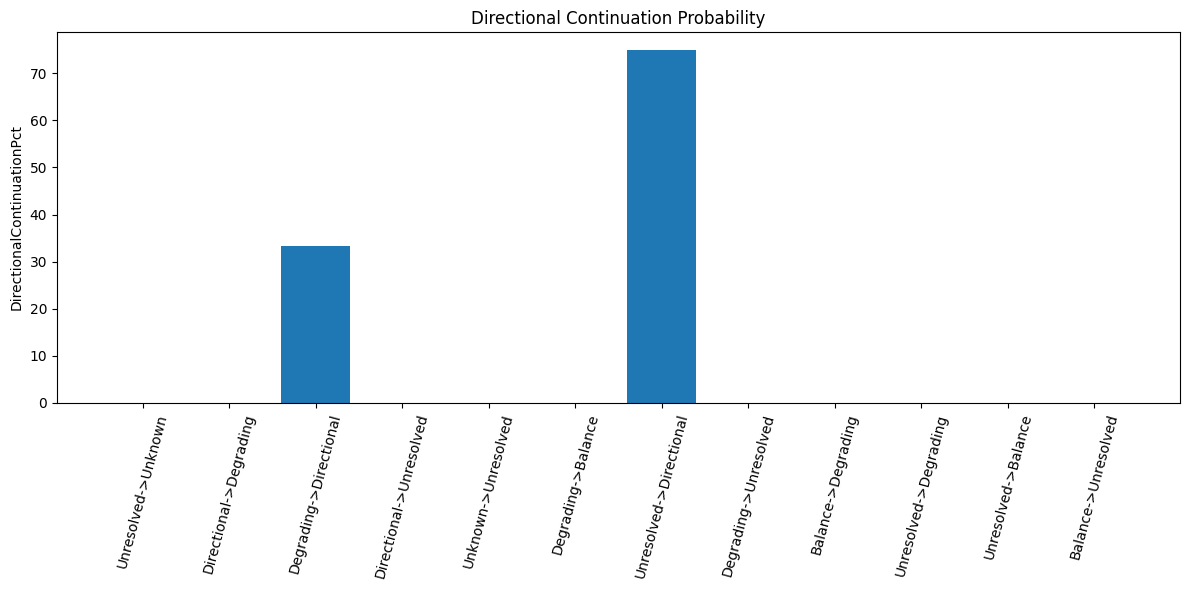

In [12]:
plt.figure(figsize=(12,6))

plt.bar(
    plot_df["Transition"],
    plot_df["DirectionalContinuationPct"].fillna(0)
)

plt.xticks(rotation=75)
plt.ylabel("DirectionalContinuationPct")
plt.title("Directional Continuation Probability")

plt.tight_layout()
plt.show()

In [13]:
merged[
    merged["Transition"].str.contains("Directional", na=False)
].sort_values(
    [
        "DirectionalContinuationPct",
        "MeanIncubationQuality"
    ],
    ascending=False
)

,Instrument,SessionContext,TotalBars,Transition,Entries,MeanPriorRunLength,MeanSponsorConfidence,MaxSponsorConfidence,MeanDominanceScore,MeanDegradationScore,MeanBalanceScore,EventCount,MeanCompressionScore,MeanExpansionPressure,MeanStructuralCompression,MeanEntropicCompression,MeanIncubationQuality,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
2,ES,RTH,400,Unresolved->Directional,8,13.75,0.369,0.80,0.193,0.587,0.394,54,0.347,0.394,0.449,0.472,0.378,3.13,25.00,75.00
10,ES,RTH,400,Degrading->Directional,3,1.67,0.517,0.60,0.530,0.635,0.410,5,0.414,0.574,0.523,0.503,0.594,1.67,66.67,33.33
3,ES,RTH,400,Directional->Degrading,10,2.70,0.632,0.70,0.567,0.449,0.270,11,0.295,0.612,0.466,0.333,0.741,2.20,70.00,0.00
11,ES,RTH,400,Directional->Unresolved,1,3.00,0.350,0.55,0.395,0.327,0.249,0,0.330,0.451,0.454,0.315,0.590,2.00,0.00,0.00


In [14]:
merged.sort_values(
    "ImmediateFailurePct",
    ascending=False
)[
    [
        "Transition",
        "ImmediateFailurePct",
        "MeanNextRunLength",
        "MeanIncubationQuality"
    ]
]

,Transition,ImmediateFailurePct,MeanNextRunLength,MeanIncubationQuality
5,Degrading->Balance,100.00,1.00,0.410
3,Directional->Degrading,70.00,2.20,0.741
10,Degrading->Directional,66.67,1.67,0.594
9,Unresolved->Degrading,63.64,1.82,0.267
7,Unresolved->Balance,63.16,1.63,0.124
6,Balance->Degrading,50.00,1.50,0.330
4,Degrading->Unresolved,29.41,5.53,0.367
2,Unresolved->Directional,25.00,3.13,0.378
8,Balance->Unresolved,21.05,7.26,0.092
1,Unresolved->Unknown,0.00,3.00,0.763


In [15]:
numeric_cols = [
    "MeanPriorRunLength",
    "MeanIncubationQuality",
    "MeanStructuralCompression",
    "MeanEntropicCompression",
    "MeanExpansionPressure",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct"
]

corr = merged[numeric_cols].corr()

corr

,MeanPriorRunLength,MeanIncubationQuality,MeanStructuralCompression,MeanEntropicCompression,MeanExpansionPressure,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
MeanPriorRunLength,1.000000,-0.109841,-0.436849,-0.057384,-0.207656,-0.104399,-0.139856,0.754286
MeanIncubationQuality,-0.109841,1.000000,-0.150453,-0.860936,0.630183,0.035604,-0.199792,0.022434
MeanStructuralCompression,-0.436849,-0.150453,1.000000,0.514579,0.353374,-0.313619,0.641604,-0.075438
MeanEntropicCompression,-0.057384,-0.860936,0.514579,1.000000,-0.161155,-0.370209,0.546031,-0.008528
MeanExpansionPressure,-0.207656,0.630183,0.353374,-0.161155,1.000000,-0.520780,0.401345,0.063707
MeanNextRunLength,-0.104399,0.035604,-0.313619,-0.370209,-0.520780,1.000000,-0.526824,-0.125968
ImmediateFailurePct,-0.139856,-0.199792,0.641604,0.546031,0.401345,-0.526824,1.000000,-0.038266
DirectionalContinuationPct,0.754286,0.022434,-0.075438,-0.008528,0.063707,-0.125968,-0.038266,1.000000


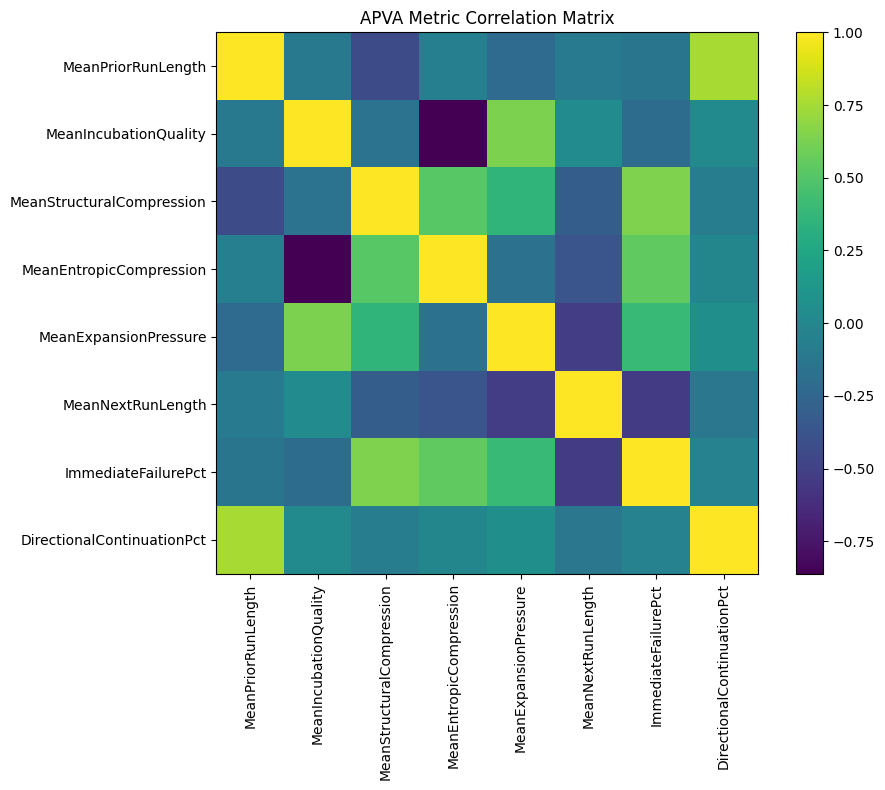

In [16]:
plt.figure(figsize=(10,8))

plt.imshow(corr, interpolation='nearest')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()
plt.title("APVA Metric Correlation Matrix")

plt.tight_layout()
plt.show()

In [17]:
# 1. Save merged master table
merged.to_csv("apva_merged_latest.csv", index=False)

# 2. Save top incubation-quality table
merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
).to_csv("apva_top_incubation_quality.csv", index=False)

# 3. Save top directional-continuation table
merged.sort_values(
    "DirectionalContinuationPct",
    ascending=False
).to_csv("apva_top_directional_continuation.csv", index=False)

# 4. Save worst immediate-failure table
merged.sort_values(
    "ImmediateFailurePct",
    ascending=False
).to_csv("apva_worst_immediate_failure.csv", index=False)

# 5. Save correlation matrix
corr.to_csv("apva_correlation_matrix.csv")

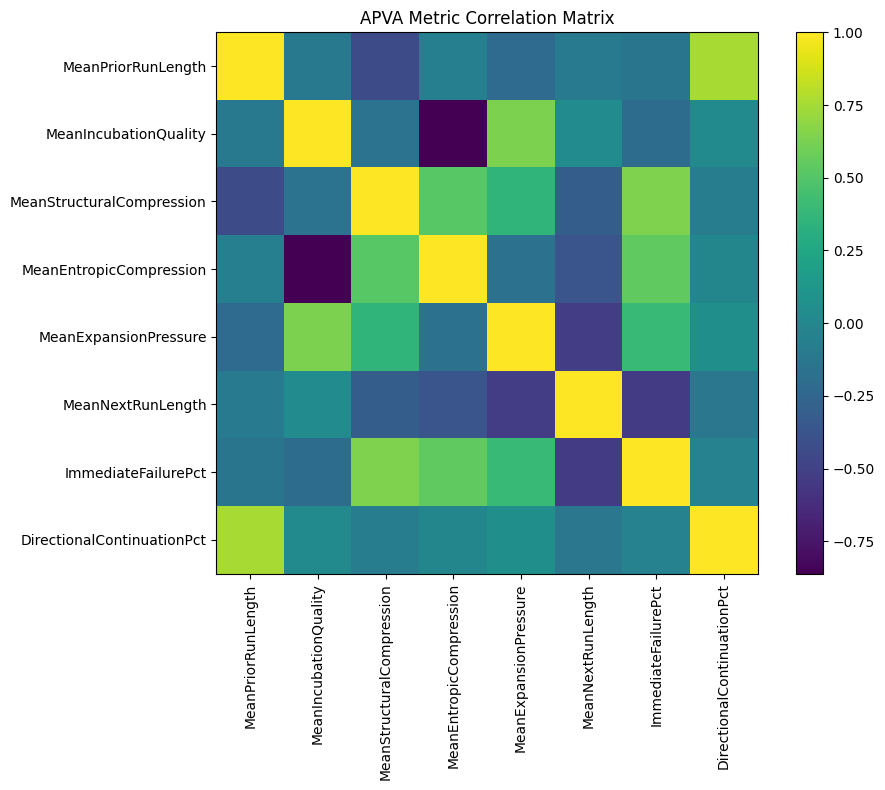

In [18]:
plt.figure(figsize=(10,8))
plt.imshow(corr, interpolation="nearest")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("APVA Metric Correlation Matrix")
plt.tight_layout()
plt.savefig("apva_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
reduced_cols = [
    "Transition",
    "MeanPriorRunLength",
    "MeanEntropicCompression",
    "MeanExpansionPressure",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct"
]

reduced = merged[reduced_cols].copy()

reduced

,Transition,MeanPriorRunLength,MeanEntropicCompression,MeanExpansionPressure,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct
0,Unknown->Unresolved,3.00,0.214,0.297,20.50,0.00,0.00
1,Unresolved->Unknown,4.00,0.130,0.447,3.00,0.00,0.00
2,Unresolved->Directional,13.75,0.472,0.394,3.13,25.00,75.00
3,Directional->Degrading,2.70,0.333,0.612,2.20,70.00,0.00
4,Degrading->Unresolved,2.06,0.573,0.479,5.53,29.41,0.00
5,Degrading->Balance,1.60,0.576,0.461,1.00,100.00,0.00
6,Balance->Degrading,2.00,0.707,0.494,1.50,50.00,0.00
7,Unresolved->Balance,4.26,0.697,0.308,1.63,63.16,0.00
8,Balance->Unresolved,1.40,0.693,0.284,7.26,21.05,0.00
9,Unresolved->Degrading,7.27,0.612,0.408,1.82,63.64,0.00


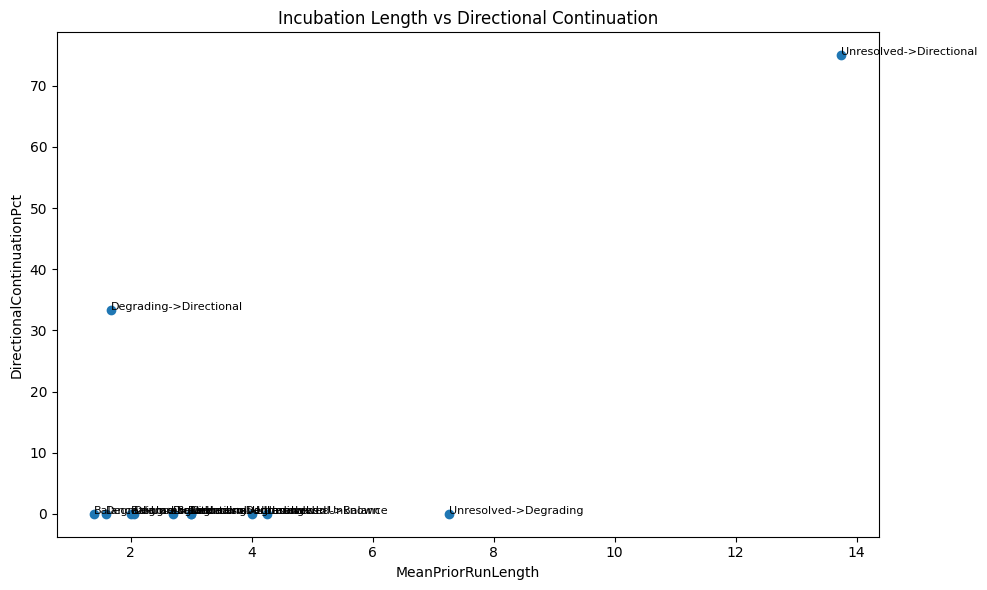

In [20]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged["MeanPriorRunLength"],
    merged["DirectionalContinuationPct"]
)

for _, row in merged.iterrows():
    plt.text(
        row["MeanPriorRunLength"],
        row["DirectionalContinuationPct"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("MeanPriorRunLength")
plt.ylabel("DirectionalContinuationPct")
plt.title("Incubation Length vs Directional Continuation")

plt.tight_layout()
plt.show()

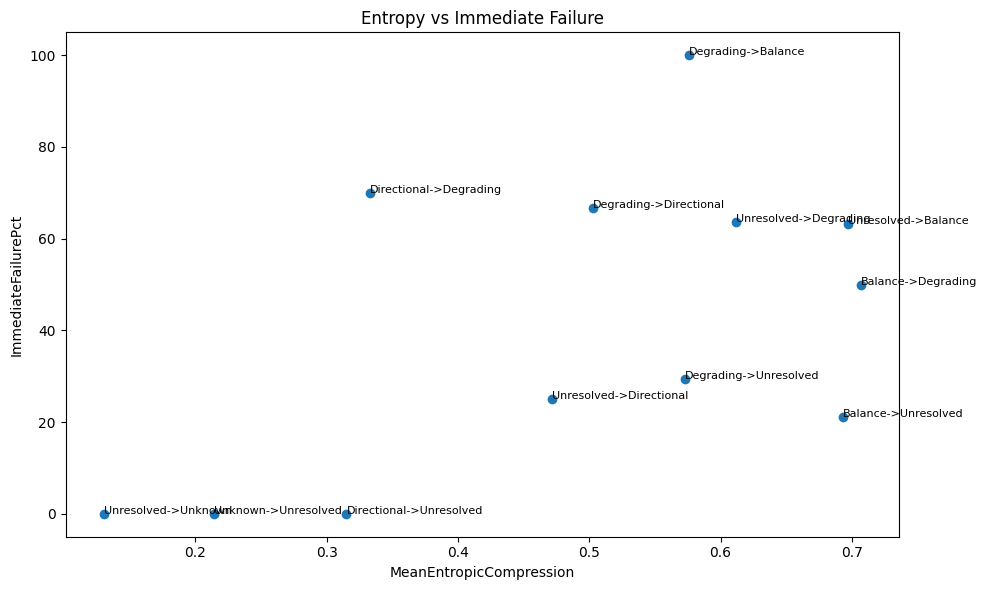

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged["MeanEntropicCompression"],
    merged["ImmediateFailurePct"]
)

for _, row in merged.iterrows():
    plt.text(
        row["MeanEntropicCompression"],
        row["ImmediateFailurePct"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("MeanEntropicCompression")
plt.ylabel("ImmediateFailurePct")
plt.title("Entropy vs Immediate Failure")

plt.tight_layout()
plt.show()

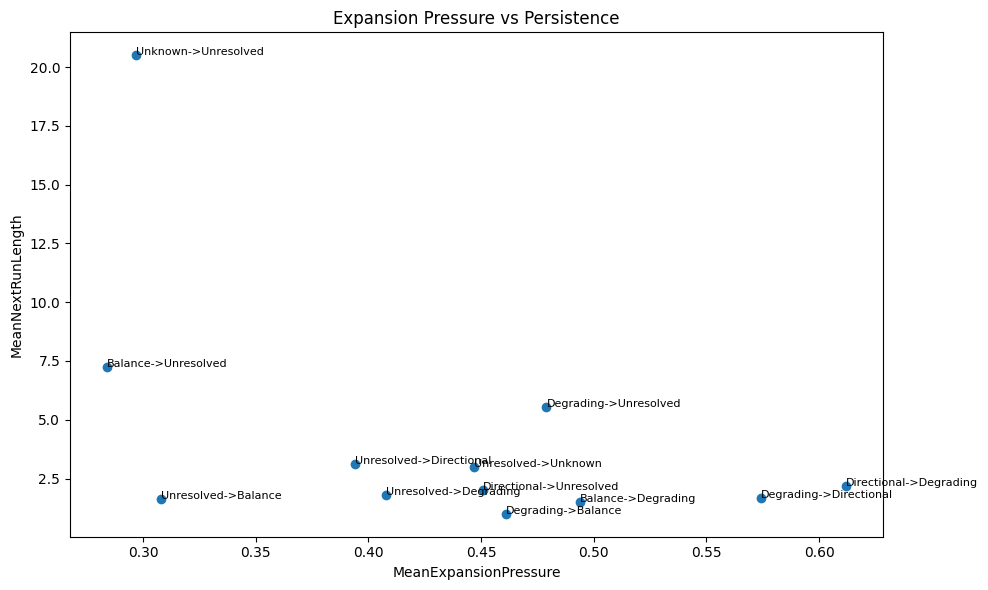

In [22]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged["MeanExpansionPressure"],
    merged["MeanNextRunLength"]
)

for _, row in merged.iterrows():
    plt.text(
        row["MeanExpansionPressure"],
        row["MeanNextRunLength"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("MeanExpansionPressure")
plt.ylabel("MeanNextRunLength")
plt.title("Expansion Pressure vs Persistence")

plt.tight_layout()
plt.show()

In [23]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# DIRECTORY SETUP
# ---------------------------------------------------------

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"

DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

merged.to_csv(
    DATA_DIR / "apva_merged_latest.csv",
    index=False
)

merged.sort_values(
    "MeanIncubationQuality",
    ascending=False
).to_csv(
    TABLE_DIR / "apva_top_incubation_quality.csv",
    index=False
)

merged.sort_values(
    "DirectionalContinuationPct",
    ascending=False
).to_csv(
    TABLE_DIR / "apva_top_directional_continuation.csv",
    index=False
)

merged.sort_values(
    "ImmediateFailurePct",
    ascending=False
).to_csv(
    TABLE_DIR / "apva_worst_immediate_failure.csv",
    index=False
)

corr.to_csv(
    DATA_DIR / "apva_correlation_matrix.csv"
)

# ---------------------------------------------------------
# CORRELATION HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(10,8))

plt.imshow(corr, interpolation="nearest")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("APVA Metric Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# INCUBATION VS CONTINUATION
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    merged["MeanPriorRunLength"],
    merged["DirectionalContinuationPct"]
)

for _, row in merged.iterrows():
    plt.text(
        row["MeanPriorRunLength"],
        row["DirectionalContinuationPct"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("MeanPriorRunLength")
plt.ylabel("DirectionalContinuationPct")

plt.title(
    "Incubation Length vs Directional Continuation"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "incubation_vs_continuation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# ENTROPY VS FAILURE
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    merged["MeanEntropicCompression"],
    merged["ImmediateFailurePct"]
)

for _, row in merged.iterrows():
    plt.text(
        row["MeanEntropicCompression"],
        row["ImmediateFailurePct"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("MeanEntropicCompression")
plt.ylabel("ImmediateFailurePct")

plt.title(
    "Entropy vs Immediate Failure"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "entropy_vs_failure.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# EXPANSION VS PERSISTENCE
# ---------------------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    merged["MeanExpansionPressure"],
    merged["MeanNextRunLength"]
)

for _, row in merged.iterrows():
    plt.text(
        row["MeanExpansionPressure"],
        row["MeanNextRunLength"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("MeanExpansionPressure")
plt.ylabel("MeanNextRunLength")

plt.title(
    "Expansion Pressure vs Persistence"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "expansion_vs_persistence.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("All APVA tables and figures exported successfully.")

All APVA tables and figures exported successfully.


In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# FEATURE SET
# ---------------------------------------------------------

feature_cols = [
    "MeanPriorRunLength",
    "MeanEntropicCompression",
    "MeanExpansionPressure",
    "MeanIncubationQuality",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct",
]

cluster_df = merged.copy()

X = cluster_df[feature_cols].fillna(0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# CORRELATION / REDUNDANCY TABLE
# ---------------------------------------------------------

corr_reduced = cluster_df[feature_cols].corr()

corr_reduced.to_csv(
    DATA_DIR / "apva_reduced_feature_correlation_matrix.csv"
)

# Highly correlated feature pairs
pairs = []

for i, col_a in enumerate(feature_cols):
    for col_b in feature_cols[i + 1:]:
        corr_value = corr_reduced.loc[col_a, col_b]
        pairs.append({
            "FeatureA": col_a,
            "FeatureB": col_b,
            "Correlation": corr_value,
            "AbsCorrelation": abs(corr_value),
        })

redundancy = pd.DataFrame(pairs).sort_values(
    "AbsCorrelation",
    ascending=False
)

redundancy.to_csv(
    TABLE_DIR / "apva_feature_redundancy_pairs.csv",
    index=False
)

# ---------------------------------------------------------
# PCA: LATENT AXES
# ---------------------------------------------------------

pca = PCA(n_components=3)
pca_values = pca.fit_transform(X_scaled)

pca_columns = ["PC1", "PC2", "PC3"]

pca_df = pd.DataFrame(
    pca_values,
    columns=pca_columns
)

pca_df["Transition"] = cluster_df["Transition"].values

explained = pd.DataFrame({
    "Component": pca_columns,
    "ExplainedVarianceRatio": pca.explained_variance_ratio_,
    "CumulativeExplainedVariance": np.cumsum(pca.explained_variance_ratio_)
})

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=pca_columns
).reset_index().rename(columns={"index": "Feature"})

explained.to_csv(
    TABLE_DIR / "apva_pca_explained_variance.csv",
    index=False
)

loadings.to_csv(
    TABLE_DIR / "apva_pca_feature_loadings.csv",
    index=False
)

pca_df.to_csv(
    TABLE_DIR / "apva_transition_pca_coordinates.csv",
    index=False
)

# ---------------------------------------------------------
# KMEANS CLUSTERING
# ---------------------------------------------------------

k = min(4, len(cluster_df))

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = cluster_df.groupby("Cluster")[feature_cols].mean().reset_index()

cluster_members = cluster_df[
    ["Cluster", "Transition"] + feature_cols
].sort_values(
    ["Cluster", "Transition"]
)

cluster_summary.to_csv(
    TABLE_DIR / "apva_cluster_summary.csv",
    index=False
)

cluster_members.to_csv(
    TABLE_DIR / "apva_cluster_members.csv",
    index=False
)

# ---------------------------------------------------------
# PCA SCATTER PLOT WITH CLUSTERS
# ---------------------------------------------------------

plot_df = pca_df.copy()
plot_df["Cluster"] = cluster_df["Cluster"].values

plt.figure(figsize=(11, 7))

plt.scatter(
    plot_df["PC1"],
    plot_df["PC2"],
    c=plot_df["Cluster"]
)

for _, row in plot_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["Transition"],
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("APVA Transition Clusters in PCA Space")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_transition_clusters_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# REDUCED FEATURE HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(
    corr_reduced,
    interpolation="nearest"
)

plt.xticks(
    range(len(corr_reduced.columns)),
    corr_reduced.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_reduced.columns)),
    corr_reduced.columns
)

plt.colorbar()
plt.title("APVA Reduced Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_reduced_feature_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# CLUSTER SUMMARY BAR CHARTS
# ---------------------------------------------------------

for col in feature_cols:
    plt.figure(figsize=(8, 5))

    plt.bar(
        cluster_summary["Cluster"].astype(str),
        cluster_summary[col]
    )

    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.title(f"Cluster Mean: {col}")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"cluster_mean_{col}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

print("Feature pruning and clustering artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Feature pruning and clustering artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [26]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# DIRECTORY SETUP
# ---------------------------------------------------------

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD QUADRUPLET DATA
# ---------------------------------------------------------

quad_path = DATA_DIR / "xApvaV01StateQuadruplets.csv"
quad_prob_path = DATA_DIR / "xApvaV01StateQuadrupletProbabilities.csv"

quad = pd.read_csv(quad_path)
quad_prob = pd.read_csv(quad_prob_path)

latest_bar = quad["TotalBars"].max()

quad_latest = quad[quad["TotalBars"] == latest_bar].copy()
quad_prob_latest = quad_prob[quad_prob["TotalBars"] == latest_bar].copy()

# ---------------------------------------------------------
# TRAJECTORY FEATURE EXTRACTION
# ---------------------------------------------------------

def split_states(path):
    return str(path).split("->")

def count_state(states, name):
    return sum(1 for s in states if s == name)

def transitions_count(states):
    return sum(1 for i in range(1, len(states)) if states[i] != states[i - 1])

def has_pattern(states, pattern):
    pat = pattern.split("->")
    for i in range(0, len(states) - len(pat) + 1):
        if states[i:i + len(pat)] == pat:
            return 1
    return 0

rows = []

for _, row in quad_latest.iterrows():
    states = split_states(row["Quadruplet"])

    if len(states) != 4:
        continue

    rows.append({
        "Quadruplet": row["Quadruplet"],
        "Count": row["Count"],

        "FirstState": states[0],
        "SecondState": states[1],
        "ThirdState": states[2],
        "FourthState": states[3],

        "UnresolvedCount": count_state(states, "Unresolved"),
        "DirectionalCount": count_state(states, "Directional"),
        "DegradingCount": count_state(states, "Degrading"),
        "BalanceCount": count_state(states, "Balance"),
        "UnknownCount": count_state(states, "Unknown"),

        "StateChanges": transitions_count(states),

        "EndsDirectional": 1 if states[-1] == "Directional" else 0,
        "EndsDegrading": 1 if states[-1] == "Degrading" else 0,
        "EndsBalance": 1 if states[-1] == "Balance" else 0,
        "EndsUnresolved": 1 if states[-1] == "Unresolved" else 0,

        "PersistentUnresolved": 1 if states == ["Unresolved"] * 4 else 0,
        "PersistentDirectional": 1 if states == ["Directional"] * 4 else 0,
        "PersistentDegrading": 1 if states == ["Degrading"] * 4 else 0,
        "PersistentBalance": 1 if states == ["Balance"] * 4 else 0,

        "UnresolvedToDirectional": has_pattern(states, "Unresolved->Directional"),
        "DirectionalToDegrading": has_pattern(states, "Directional->Degrading"),
        "BalanceUnresolvedLoop": has_pattern(states, "Balance->Unresolved") or has_pattern(states, "Unresolved->Balance"),
        "DegradingUnresolvedLoop": has_pattern(states, "Degrading->Unresolved") or has_pattern(states, "Unresolved->Degrading"),
    })

traj = pd.DataFrame(rows)

# ---------------------------------------------------------
# MERGE CONDITIONAL PROBABILITY
# ---------------------------------------------------------

prob_cols = [
    "Quadruplet",
    "ConditionalProbability"
]

traj = traj.merge(
    quad_prob_latest[prob_cols],
    on="Quadruplet",
    how="left"
)

traj["ConditionalProbability"] = traj["ConditionalProbability"].fillna(0.0)

# ---------------------------------------------------------
# EXPORT RAW TRAJECTORY FEATURE TABLE
# ---------------------------------------------------------

traj.to_csv(
    TABLE_DIR / "apva_trajectory_features.csv",
    index=False
)

# ---------------------------------------------------------
# CLUSTER TRAJECTORIES
# ---------------------------------------------------------

feature_cols = [
    "Count",
    "ConditionalProbability",
    "UnresolvedCount",
    "DirectionalCount",
    "DegradingCount",
    "BalanceCount",
    "StateChanges",
    "EndsDirectional",
    "EndsDegrading",
    "EndsBalance",
    "EndsUnresolved",
    "PersistentUnresolved",
    "PersistentDirectional",
    "PersistentDegrading",
    "PersistentBalance",
    "UnresolvedToDirectional",
    "DirectionalToDegrading",
    "BalanceUnresolvedLoop",
    "DegradingUnresolvedLoop",
]

X = traj[feature_cols].fillna(0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = min(5, len(traj))

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=20
)

traj["TrajectoryCluster"] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# PCA FOR TRAJECTORY VISUALIZATION
# ---------------------------------------------------------

pca = PCA(n_components=3)
pca_values = pca.fit_transform(X_scaled)

traj["PC1"] = pca_values[:, 0]
traj["PC2"] = pca_values[:, 1]
traj["PC3"] = pca_values[:, 2]

traj_cluster_summary = traj.groupby("TrajectoryCluster")[feature_cols].mean().reset_index()

member_cols = [
    "TrajectoryCluster",
    "Quadruplet",
    "PC1",
    "PC2",
    "PC3",
] + feature_cols

member_cols = list(dict.fromkeys(member_cols))

traj_cluster_members = traj[member_cols].sort_values(
    ["TrajectoryCluster", "Count"],
    ascending=[True, False]
)

pca_explained = pd.DataFrame({
    "Component": ["PC1", "PC2", "PC3"],
    "ExplainedVarianceRatio": pca.explained_variance_ratio_,
    "CumulativeExplainedVariance": np.cumsum(pca.explained_variance_ratio_)
})

pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2", "PC3"]
).reset_index().rename(columns={"index": "Feature"})

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

traj_cluster_summary.to_csv(
    TABLE_DIR / "apva_trajectory_cluster_summary.csv",
    index=False
)

traj_cluster_members.to_csv(
    TABLE_DIR / "apva_trajectory_cluster_members.csv",
    index=False
)

pca_explained.to_csv(
    TABLE_DIR / "apva_trajectory_pca_explained_variance.csv",
    index=False
)

pca_loadings.to_csv(
    TABLE_DIR / "apva_trajectory_pca_feature_loadings.csv",
    index=False
)

traj.sort_values(
    "Count",
    ascending=False
).to_csv(
    TABLE_DIR / "apva_top_trajectory_motifs.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: PCA CLUSTERS
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.scatter(
    traj["PC1"],
    traj["PC2"],
    c=traj["TrajectoryCluster"]
)

for _, row in traj.iterrows():
    if row["Count"] >= traj["Count"].quantile(0.75):
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Quadruplet"],
            fontsize=7
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("APVA Trajectory Motif Clusters")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_trajectory_motif_clusters_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: TOP MOTIFS
# ---------------------------------------------------------

top_motifs = traj.sort_values("Count", ascending=False).head(20)

plt.figure(figsize=(12, 7))

plt.barh(
    top_motifs["Quadruplet"],
    top_motifs["Count"]
)

plt.xlabel("Count")
plt.ylabel("Quadruplet")
plt.title("Top APVA Trajectory Motifs")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_top_trajectory_motifs.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: CLUSTER MEANS
# ---------------------------------------------------------

for col in [
    "UnresolvedCount",
    "DirectionalCount",
    "DegradingCount",
    "BalanceCount",
    "StateChanges",
    "EndsDirectional",
    "EndsDegrading",
    "EndsBalance",
    "EndsUnresolved",
]:
    plt.figure(figsize=(8, 5))

    plt.bar(
        traj_cluster_summary["TrajectoryCluster"].astype(str),
        traj_cluster_summary[col]
    )

    plt.xlabel("TrajectoryCluster")
    plt.ylabel(col)
    plt.title(f"Trajectory Cluster Mean: {col}")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"trajectory_cluster_mean_{col}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

print("Trajectory-family extraction artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Trajectory-family extraction artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [27]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
FIG_DIR = BASE_DIR / "figures"
TABLE_DIR = BASE_DIR / "tables"

FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD REQUIRED TABLES
# ---------------------------------------------------------

traj_members = pd.read_csv(
    TABLE_DIR / "apva_trajectory_cluster_members.csv"
)

transition_expectancy = pd.read_csv(
    DATA_DIR / "xApvaV01TransitionExpectancy.csv"
)

latest_bar = transition_expectancy["TotalBars"].max()

transition_expectancy_latest = transition_expectancy[
    transition_expectancy["TotalBars"] == latest_bar
].copy()

# ---------------------------------------------------------
# DERIVE FINAL TRANSITION FROM EACH QUADRUPLET
# ---------------------------------------------------------

def final_transition(quadruplet):
    states = str(quadruplet).split("->")

    if len(states) != 4:
        return None

    return states[-2] + "->" + states[-1]

traj_expectancy = traj_members.copy()

traj_expectancy["FinalTransition"] = traj_expectancy["Quadruplet"].apply(
    final_transition
)

# ---------------------------------------------------------
# MERGE FINAL-TRANSITION EXPECTANCY
# ---------------------------------------------------------

expectancy_cols = [
    "Transition",
    "Occurrences",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct",
]

traj_expectancy = traj_expectancy.merge(
    transition_expectancy_latest[expectancy_cols],
    left_on="FinalTransition",
    right_on="Transition",
    how="left"
)

traj_expectancy = traj_expectancy.drop(
    columns=["Transition"],
    errors="ignore"
)

for col in [
    "Occurrences",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct",
]:
    traj_expectancy[col] = traj_expectancy[col].fillna(0.0)

# ---------------------------------------------------------
# ADD TRAJECTORY EXPECTANCY LABELS
# ---------------------------------------------------------

def classify_trajectory_expectancy(row):
    if row["DirectionalContinuationPct"] >= 60:
        return "DirectionalContinuation"

    if row["ImmediateFailurePct"] >= 60:
        return "ImmediateFailure"

    if row["MeanNextRunLength"] >= 5:
        return "PersistentNonDirectional"

    if row["EndsBalance"] == 1 or row["BalanceUnresolvedLoop"] == 1:
        return "RotationalChurn"

    if row["EndsDegrading"] == 1 or row["DegradingUnresolvedLoop"] == 1:
        return "DegradationCycle"

    return "Mixed"

traj_expectancy["ExpectancyFamily"] = traj_expectancy.apply(
    classify_trajectory_expectancy,
    axis=1
)

# ---------------------------------------------------------
# EXPORT TRAJECTORY EXPECTANCY TABLE
# ---------------------------------------------------------

traj_expectancy.to_csv(
    TABLE_DIR / "apva_trajectory_expectancy.csv",
    index=False
)

# ---------------------------------------------------------
# CLUSTER EXPECTANCY SUMMARY
# ---------------------------------------------------------

expectancy_summary = traj_expectancy.groupby(
    "TrajectoryCluster"
).agg(
    MotifCount=("Quadruplet", "count"),
    TotalOccurrences=("Count", "sum"),
    MeanConditionalProbability=("ConditionalProbability", "mean"),
    MeanNextRunLength=("MeanNextRunLength", "mean"),
    MeanImmediateFailurePct=("ImmediateFailurePct", "mean"),
    MeanDirectionalContinuationPct=("DirectionalContinuationPct", "mean"),
    MeanUnresolvedCount=("UnresolvedCount", "mean"),
    MeanDirectionalCount=("DirectionalCount", "mean"),
    MeanDegradingCount=("DegradingCount", "mean"),
    MeanBalanceCount=("BalanceCount", "mean"),
    MeanStateChanges=("StateChanges", "mean"),
).reset_index()

expectancy_summary.to_csv(
    TABLE_DIR / "apva_trajectory_expectancy_cluster_summary.csv",
    index=False
)

# ---------------------------------------------------------
# EXPECTANCY FAMILY COUNTS
# ---------------------------------------------------------

family_counts = traj_expectancy.groupby(
    ["TrajectoryCluster", "ExpectancyFamily"]
).agg(
    MotifCount=("Quadruplet", "count"),
    TotalOccurrences=("Count", "sum"),
    MeanNextRunLength=("MeanNextRunLength", "mean"),
    MeanImmediateFailurePct=("ImmediateFailurePct", "mean"),
    MeanDirectionalContinuationPct=("DirectionalContinuationPct", "mean"),
).reset_index()

family_counts.to_csv(
    TABLE_DIR / "apva_trajectory_expectancy_family_counts.csv",
    index=False
)

# ---------------------------------------------------------
# TOP TRAJECTORIES BY DIRECTIONAL CONTINUATION
# ---------------------------------------------------------

top_directional_trajectories = traj_expectancy.sort_values(
    [
        "DirectionalContinuationPct",
        "Count",
        "ConditionalProbability",
    ],
    ascending=[False, False, False]
)

top_directional_trajectories.to_csv(
    TABLE_DIR / "apva_top_directional_trajectory_expectancy.csv",
    index=False
)

# ---------------------------------------------------------
# TOP TRAJECTORIES BY IMMEDIATE FAILURE
# ---------------------------------------------------------

top_failure_trajectories = traj_expectancy.sort_values(
    [
        "ImmediateFailurePct",
        "Count",
        "ConditionalProbability",
    ],
    ascending=[False, False, False]
)

top_failure_trajectories.to_csv(
    TABLE_DIR / "apva_top_failure_trajectory_expectancy.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: TRAJECTORY CLUSTER EXPECTANCY
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    expectancy_summary["TrajectoryCluster"].astype(str),
    expectancy_summary["MeanDirectionalContinuationPct"]
)

plt.xlabel("TrajectoryCluster")
plt.ylabel("MeanDirectionalContinuationPct")
plt.title("Trajectory Cluster Directional Continuation Expectancy")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_trajectory_cluster_directional_expectancy.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: TRAJECTORY CLUSTER FAILURE
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    expectancy_summary["TrajectoryCluster"].astype(str),
    expectancy_summary["MeanImmediateFailurePct"]
)

plt.xlabel("TrajectoryCluster")
plt.ylabel("MeanImmediateFailurePct")
plt.title("Trajectory Cluster Immediate Failure Expectancy")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_trajectory_cluster_failure_expectancy.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: CONTINUATION VS FAILURE SCATTER
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    traj_expectancy["ImmediateFailurePct"],
    traj_expectancy["DirectionalContinuationPct"],
    c=traj_expectancy["TrajectoryCluster"]
)

for _, row in traj_expectancy.iterrows():
    if (
        row["DirectionalContinuationPct"] >= 50
        or row["ImmediateFailurePct"] >= 75
        or row["Count"] >= traj_expectancy["Count"].quantile(0.90)
    ):
        plt.text(
            row["ImmediateFailurePct"],
            row["DirectionalContinuationPct"],
            row["Quadruplet"],
            fontsize=7
        )

plt.xlabel("ImmediateFailurePct")
plt.ylabel("DirectionalContinuationPct")
plt.title("Trajectory Expectancy: Failure vs Directional Continuation")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_trajectory_expectancy_failure_vs_continuation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: FAMILY COUNTS
# ---------------------------------------------------------

family_pivot = family_counts.pivot_table(
    index="TrajectoryCluster",
    columns="ExpectancyFamily",
    values="MotifCount",
    fill_value=0
)

family_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7)
)

plt.xlabel("TrajectoryCluster")
plt.ylabel("MotifCount")
plt.title("Trajectory Expectancy Families by Cluster")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_trajectory_expectancy_families_by_cluster.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Trajectory expectancy artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Trajectory expectancy artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [28]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
TABLE_DIR = BASE_DIR / "tables"

summary = pd.read_csv(TABLE_DIR / "apva_trajectory_expectancy_cluster_summary.csv")
families = pd.read_csv(TABLE_DIR / "apva_trajectory_expectancy_family_counts.csv")
members = pd.read_csv(TABLE_DIR / "apva_trajectory_cluster_members.csv")

archetype_names = {
    0: "Degradation / Exhaustion Collapse",
    1: "Fragile Rotational Churn",
    2: "Persistent Non-Directional Compression",
    3: "Directional Continuation / Sponsor Release",
    4: "Pure Unresolved Compression Equilibrium",
}

summary["Archetype"] = summary["TrajectoryCluster"].map(archetype_names)
families["Archetype"] = families["TrajectoryCluster"].map(archetype_names)
members["Archetype"] = members["TrajectoryCluster"].map(archetype_names)

summary.to_csv(TABLE_DIR / "apva_auction_archetype_summary.csv", index=False)
families.to_csv(TABLE_DIR / "apva_auction_archetype_family_counts.csv", index=False)
members.to_csv(TABLE_DIR / "apva_auction_archetype_members.csv", index=False)

report_lines = []
report_lines.append("# APVA Auction Archetype Report\n")

for cluster_id, name in archetype_names.items():
    row = summary[summary["TrajectoryCluster"] == cluster_id].iloc[0]

    report_lines.append(f"## Cluster {cluster_id}: {name}\n")
    report_lines.append(f"- MotifCount: {row['MotifCount']}")
    report_lines.append(f"- TotalOccurrences: {row['TotalOccurrences']}")
    report_lines.append(f"- MeanNextRunLength: {row['MeanNextRunLength']:.2f}")
    report_lines.append(f"- MeanImmediateFailurePct: {row['MeanImmediateFailurePct']:.2f}")
    report_lines.append(f"- MeanDirectionalContinuationPct: {row['MeanDirectionalContinuationPct']:.2f}")
    report_lines.append(f"- MeanUnresolvedCount: {row['MeanUnresolvedCount']:.2f}")
    report_lines.append(f"- MeanDirectionalCount: {row['MeanDirectionalCount']:.2f}")
    report_lines.append(f"- MeanDegradingCount: {row['MeanDegradingCount']:.2f}")
    report_lines.append(f"- MeanBalanceCount: {row['MeanBalanceCount']:.2f}\n")

    top_members = members[members["TrajectoryCluster"] == cluster_id].sort_values(
        "Count",
        ascending=False
    ).head(5)

    report_lines.append("Top motifs:\n")

    for _, m in top_members.iterrows():
        report_lines.append(f"- `{m['Quadruplet']}` count={m['Count']}")

    report_lines.append("\n")

report_path = TABLE_DIR / "apva_auction_archetype_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Auction archetype report exported:")
print(report_path)

Auction archetype report exported:
C:\Users\rz0\Documents\ApvaAnalysis\tables\apva_auction_archetype_report.md


In [29]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
TABLE_DIR = BASE_DIR / "tables"

TABLE_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD TABLES
# ---------------------------------------------------------

traj_expectancy = pd.read_csv(
    TABLE_DIR / "apva_trajectory_expectancy.csv"
)

cluster_summary = pd.read_csv(
    TABLE_DIR / "apva_trajectory_expectancy_cluster_summary.csv"
)

# ---------------------------------------------------------
# ARCHETYPE NAMES
# ---------------------------------------------------------

archetype_names = {
    0: "Sponsor Exhaustion Collapse",
    1: "Unstable Rotational Balance",
    2: "Stable Compression Basin",
    3: "Directional Continuation / Sponsor Release",
    4: "Pure Unresolved Compression Equilibrium",
}

traj_expectancy["Archetype"] = (
    traj_expectancy["TrajectoryCluster"]
    .map(archetype_names)
)

# ---------------------------------------------------------
# ONLINE ARCHETYPE LOOKUP TABLE
# ---------------------------------------------------------

lookup_cols = [
    "Quadruplet",
    "TrajectoryCluster",
    "Archetype",
    "ExpectancyFamily",
    "Count",
    "ConditionalProbability",
    "FinalTransition",
    "MeanNextRunLength",
    "ImmediateFailurePct",
    "DirectionalContinuationPct",
    "UnresolvedCount",
    "DirectionalCount",
    "DegradingCount",
    "BalanceCount",
    "StateChanges",
    "EndsDirectional",
    "EndsDegrading",
    "EndsBalance",
    "EndsUnresolved",
    "PersistentUnresolved",
    "PersistentDirectional",
    "PersistentDegrading",
    "PersistentBalance",
    "UnresolvedToDirectional",
    "DirectionalToDegrading",
    "BalanceUnresolvedLoop",
    "DegradingUnresolvedLoop",
]

online_lookup = traj_expectancy[lookup_cols].copy()

online_lookup = online_lookup.sort_values(
    [
        "Count",
        "ConditionalProbability",
        "DirectionalContinuationPct",
    ],
    ascending=[False, False, False]
)

online_lookup.to_csv(
    TABLE_DIR / "apva_online_archetype_lookup.csv",
    index=False
)

# ---------------------------------------------------------
# ARCHETYPE INFERENCE RULES TABLE
# ---------------------------------------------------------

rules = []

for _, row in cluster_summary.iterrows():
    cluster_id = int(row["TrajectoryCluster"])
    archetype = archetype_names.get(cluster_id, "Unknown Archetype")

    directional = row["MeanDirectionalContinuationPct"]
    failure = row["MeanImmediateFailurePct"]
    next_len = row["MeanNextRunLength"]

    if cluster_id == 0:
        implication = (
            "Sponsor structure is deteriorating. Expect degradation persistence "
            "or exhaustion behavior. Avoid treating directional movement as durable."
        )
        action_bias = "Avoid continuation entries; monitor for failed breakout or exhaustion."
    elif cluster_id == 1:
        implication = (
            "Auction is rotating unstably. Balance is present but fragile. "
            "Expect churn and false resolution attempts."
        )
        action_bias = "Avoid directional commitment; wait for cleaner incubation or release."
    elif cluster_id == 2:
        implication = (
            "Auction is in a stable compression basin. Non-directional persistence "
            "is likely. This may mature into later directional release."
        )
        action_bias = "Monitor compression quality; prepare but do not anticipate prematurely."
    elif cluster_id == 3:
        implication = (
            "Auction shows directional continuation structure. Sponsor release is active, "
            "but degradation must be monitored."
        )
        action_bias = "Continuation favored while degradation remains contained."
    elif cluster_id == 4:
        implication = (
            "Auction is in pure unresolved compression equilibrium. This is the dominant "
            "resting basin. Await transition into compression basin, release, or degradation."
        )
        action_bias = "No action bias; observe for transition out of pure unresolved state."
    else:
        implication = "No rule available."
        action_bias = "No action bias."

    rules.append({
        "TrajectoryCluster": cluster_id,
        "Archetype": archetype,
        "MeanNextRunLength": next_len,
        "MeanImmediateFailurePct": failure,
        "MeanDirectionalContinuationPct": directional,
        "Implication": implication,
        "ActionBias": action_bias,
    })

rules_df = pd.DataFrame(rules).sort_values(
    "TrajectoryCluster"
)

rules_df.to_csv(
    TABLE_DIR / "apva_archetype_inference_rules.csv",
    index=False
)

# ---------------------------------------------------------
# SIMPLE INFERENCE FUNCTION FOR NOTEBOOK USE
# ---------------------------------------------------------

def infer_archetype(quadruplet):
    match = online_lookup[
        online_lookup["Quadruplet"] == quadruplet
    ]

    if match.empty:
        return {
            "Quadruplet": quadruplet,
            "Known": False,
            "Message": "Trajectory not observed in current dataset."
        }

    row = match.iloc[0]

    rule = rules_df[
        rules_df["TrajectoryCluster"] == row["TrajectoryCluster"]
    ].iloc[0]

    return {
        "Quadruplet": row["Quadruplet"],
        "Known": True,
        "TrajectoryCluster": int(row["TrajectoryCluster"]),
        "Archetype": row["Archetype"],
        "ExpectancyFamily": row["ExpectancyFamily"],
        "Count": int(row["Count"]),
        "ConditionalProbability": float(row["ConditionalProbability"]),
        "FinalTransition": row["FinalTransition"],
        "MeanNextRunLength": float(row["MeanNextRunLength"]),
        "ImmediateFailurePct": float(row["ImmediateFailurePct"]),
        "DirectionalContinuationPct": float(row["DirectionalContinuationPct"]),
        "Implication": rule["Implication"],
        "ActionBias": rule["ActionBias"],
    }

# ---------------------------------------------------------
# TEST EXAMPLES
# ---------------------------------------------------------

examples = [
    "Unresolved->Unresolved->Unresolved->Unresolved",
    "Unresolved->Unresolved->Directional->Directional",
    "Unresolved->Directional->Directional->Directional",
    "Directional->Directional->Directional->Degrading",
    "Unresolved->Unresolved->Unresolved->Balance",
]

results = [infer_archetype(x) for x in examples]

example_results = pd.DataFrame(results)

example_results.to_csv(
    TABLE_DIR / "apva_online_archetype_inference_examples.csv",
    index=False
)

example_results

,Quadruplet,Known,TrajectoryCluster,Archetype,ExpectancyFamily,Count,ConditionalProbability,FinalTransition,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct,Implication,ActionBias
0,Unresolved->Unresolved->Unresolved->Unresolved,True,4,Pure Unresolved Compression Equilibrium,Mixed,186,89.42,Unresolved->Unresolved,0.00,0.00,0.0,Auction is in pure unresolved compression equi...,No action bias; observe for transition out of ...
1,Unresolved->Unresolved->Directional->Directional,True,3,Directional Continuation / Sponsor Release,Mixed,5,71.43,Directional->Directional,0.00,0.00,0.0,Auction shows directional continuation structu...,Continuation favored while degradation remains...
2,Unresolved->Directional->Directional->Directional,True,3,Directional Continuation / Sponsor Release,Mixed,3,50.00,Directional->Directional,0.00,0.00,0.0,Auction shows directional continuation structu...,Continuation favored while degradation remains...
3,Directional->Directional->Directional->Degrading,True,0,Sponsor Exhaustion Collapse,ImmediateFailure,3,25.00,Directional->Degrading,2.20,70.00,0.0,Sponsor structure is deteriorating. Expect deg...,Avoid continuation entries; monitor for failed...
4,Unresolved->Unresolved->Unresolved->Balance,True,1,Unstable Rotational Balance,ImmediateFailure,10,4.81,Unresolved->Balance,1.63,63.16,0.0,Auction is rotating unstably. Balance is prese...,Avoid directional commitment; wait for cleaner...


In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD CHRONOLOGICAL STATE LOG
# ---------------------------------------------------------

state_log = pd.read_csv(
    DATA_DIR / "xApvaV01StateLog_ES.csv"
)

# ---------------------------------------------------------
# CLEAN / SORT
# ---------------------------------------------------------

state_log = state_log.sort_values("BarIndex")

states = (
    state_log["MacroState"]
    .fillna("Unknown")
    .astype(str)
    .tolist()
)

# ---------------------------------------------------------
# BUILD 4 -> NEXT-STATE SEQUENCE MODEL
# ---------------------------------------------------------

records = []

for i in range(len(states) - 4):

    current_quad = "->".join(states[i:i+4])

    next_state = states[i + 4]

    records.append({
        "CurrentQuadruplet": current_quad,
        "NextState": next_state
    })

seq_df = pd.DataFrame(records)

# ---------------------------------------------------------
# COUNT NEXT-STATE DISTRIBUTIONS
# ---------------------------------------------------------

counts = (
    seq_df
    .groupby(["CurrentQuadruplet", "NextState"])
    .size()
    .reset_index(name="Count")
)

totals = (
    counts
    .groupby("CurrentQuadruplet")["Count"]
    .sum()
    .reset_index(name="TotalCount")
)

counts = counts.merge(
    totals,
    on="CurrentQuadruplet",
    how="left"
)

counts["Probability"] = (
    counts["Count"] / counts["TotalCount"]
)

# ---------------------------------------------------------
# DOMINANT NEXT STATE
# ---------------------------------------------------------

dominant = (
    counts
    .sort_values(
        ["CurrentQuadruplet", "Probability"],
        ascending=[True, False]
    )
    .groupby("CurrentQuadruplet")
    .head(1)
    .reset_index(drop=True)
)

dominant = dominant.rename(columns={
    "NextState": "DominantNextState",
    "Probability": "DominantNextStateProbability",
    "Count": "DominantNextStateCount"
})

# ---------------------------------------------------------
# ENTROPY OF NEXT-STATE DISTRIBUTION
# ---------------------------------------------------------

entropy_rows = []

for quad, group in counts.groupby("CurrentQuadruplet"):

    probs = group["Probability"].values

    entropy = -np.sum(
        probs * np.log2(probs + 1e-12)
    )

    entropy_rows.append({
        "CurrentQuadruplet": quad,
        "NextStateEntropy": entropy,
        "DistinctNextStates": len(group)
    })

entropy_df = pd.DataFrame(entropy_rows)

# ---------------------------------------------------------
# FINAL SEQUENCE MODEL
# ---------------------------------------------------------

sequence_model = dominant.merge(
    entropy_df,
    on="CurrentQuadruplet",
    how="left"
)

sequence_model = sequence_model.sort_values(
    [
        "DominantNextStateProbability",
        "DominantNextStateCount"
    ],
    ascending=[False, False]
)

# ---------------------------------------------------------
# CLASSIFY PREDICTABILITY
# ---------------------------------------------------------

def classify_predictability(prob, entropy):

    if prob >= 0.85 and entropy < 0.50:
        return "Highly Predictable"

    if prob >= 0.65 and entropy < 1.00:
        return "Moderately Predictable"

    if entropy >= 1.50:
        return "Chaotic"

    return "Mixed"

sequence_model["PredictabilityClass"] = (
    sequence_model.apply(
        lambda r: classify_predictability(
            r["DominantNextStateProbability"],
            r["NextStateEntropy"]
        ),
        axis=1
    )
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

counts.to_csv(
    TABLE_DIR / "apva_next_state_transition_surface.csv",
    index=False
)

sequence_model.to_csv(
    TABLE_DIR / "apva_sequence_space_model.csv",
    index=False
)

# ---------------------------------------------------------
# TOP PREDICTABLE TRAJECTORIES
# ---------------------------------------------------------

top_predictable = sequence_model.sort_values(
    [
        "DominantNextStateProbability",
        "NextStateEntropy"
    ],
    ascending=[False, True]
)

top_predictable.to_csv(
    TABLE_DIR / "apva_top_predictable_trajectories.csv",
    index=False
)

# ---------------------------------------------------------
# MOST CHAOTIC TRAJECTORIES
# ---------------------------------------------------------

most_chaotic = sequence_model.sort_values(
    [
        "NextStateEntropy",
        "DominantNextStateProbability"
    ],
    ascending=[False, True]
)

most_chaotic.to_csv(
    TABLE_DIR / "apva_most_chaotic_trajectories.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: ENTROPY VS PREDICTABILITY
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    sequence_model["NextStateEntropy"],
    sequence_model["DominantNextStateProbability"]
)

for _, row in sequence_model.iterrows():

    if (
        row["DominantNextStateProbability"] >= 0.80
        or row["NextStateEntropy"] >= 1.5
    ):
        plt.text(
            row["NextStateEntropy"],
            row["DominantNextStateProbability"],
            row["CurrentQuadruplet"],
            fontsize=7
        )

plt.xlabel("Next-State Entropy")
plt.ylabel("Dominant Next-State Probability")

plt.title(
    "APVA Sequence-Space Predictability Surface"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_sequence_predictability_surface.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: PREDICTABILITY CLASS COUNTS
# ---------------------------------------------------------

predict_counts = (
    sequence_model["PredictabilityClass"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    predict_counts.index,
    predict_counts.values
)

plt.xlabel("PredictabilityClass")
plt.ylabel("Count")

plt.title("APVA Sequence Predictability Classes")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_predictability_class_counts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Sequence-space Markov artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Sequence-space Markov artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD EXISTING SEQUENCE MODEL
# ---------------------------------------------------------

seq_model = pd.read_csv(
    TABLE_DIR / "apva_sequence_space_model.csv"
)

# ---------------------------------------------------------
# MINIMUM SUPPORT FILTER
# ---------------------------------------------------------

MIN_SUPPORT = 5

supported = seq_model[
    seq_model["TotalCount"] >= MIN_SUPPORT
].copy()

# ---------------------------------------------------------
# SORT BY TRUE PREDICTABILITY
# ---------------------------------------------------------

supported = supported.sort_values(
    [
        "DominantNextStateProbability",
        "NextStateEntropy",
        "TotalCount"
    ],
    ascending=[False, True, False]
)

# ---------------------------------------------------------
# PERSISTENCE CLASSIFICATION
# ---------------------------------------------------------

def classify_behavior(row):

    quad = row["CurrentQuadruplet"]
    next_state = row["DominantNextState"]

    unresolved_count = quad.count("Unresolved")
    directional_count = quad.count("Directional")
    degrading_count = quad.count("Degrading")
    balance_count = quad.count("Balance")

    if unresolved_count >= 3 and next_state == "Unresolved":
        return "Persistent Compression"

    if directional_count >= 3 and next_state == "Directional":
        return "Persistent Directional Continuation"

    if degrading_count >= 2 and next_state == "Degrading":
        return "Persistent Degradation"

    if balance_count >= 2 and next_state == "Balance":
        return "Rotational Balance"

    if next_state == "Directional":
        return "Directional Release"

    if next_state == "Degrading":
        return "Exhaustion / Collapse"

    if next_state == "Balance":
        return "Rotational Drift"

    return "Mixed"

supported["BehaviorClass"] = supported.apply(
    classify_behavior,
    axis=1
)

# ---------------------------------------------------------
# STABILITY SCORE
# ---------------------------------------------------------

supported["StabilityScore"] = (
    supported["DominantNextStateProbability"]
    * np.log1p(supported["TotalCount"])
    / (1.0 + supported["NextStateEntropy"])
)

# ---------------------------------------------------------
# EXPORT FILTERED MODEL
# ---------------------------------------------------------

supported.to_csv(
    TABLE_DIR / "apva_supported_sequence_space_model.csv",
    index=False
)

# ---------------------------------------------------------
# TOP STABLE TRAJECTORIES
# ---------------------------------------------------------

top_stable = supported.sort_values(
    "StabilityScore",
    ascending=False
)

top_stable.to_csv(
    TABLE_DIR / "apva_top_stable_trajectories.csv",
    index=False
)

# ---------------------------------------------------------
# MOST CHAOTIC SUPPORTED TRAJECTORIES
# ---------------------------------------------------------

chaotic = supported.sort_values(
    [
        "NextStateEntropy",
        "DominantNextStateProbability"
    ],
    ascending=[False, True]
)

chaotic.to_csv(
    TABLE_DIR / "apva_supported_chaotic_trajectories.csv",
    index=False
)

# ---------------------------------------------------------
# BEHAVIOR CLASS SUMMARY
# ---------------------------------------------------------

behavior_summary = supported.groupby(
    "BehaviorClass"
).agg(
    TrajectoryCount=("CurrentQuadruplet", "count"),
    MeanProbability=("DominantNextStateProbability", "mean"),
    MeanEntropy=("NextStateEntropy", "mean"),
    MeanSupport=("TotalCount", "mean"),
    MeanStability=("StabilityScore", "mean")
).reset_index()

behavior_summary = behavior_summary.sort_values(
    "MeanStability",
    ascending=False
)

behavior_summary.to_csv(
    TABLE_DIR / "apva_behavior_class_summary.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: STABILITY VS ENTROPY
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    supported["NextStateEntropy"],
    supported["StabilityScore"]
)

for _, row in supported.iterrows():

    if (
        row["StabilityScore"] >= supported["StabilityScore"].quantile(0.80)
        or row["NextStateEntropy"] >= 1.25
    ):
        plt.text(
            row["NextStateEntropy"],
            row["StabilityScore"],
            row["CurrentQuadruplet"],
            fontsize=7
        )

plt.xlabel("Next-State Entropy")
plt.ylabel("StabilityScore")

plt.title(
    "APVA Supported Trajectory Stability Surface"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_supported_stability_surface.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: BEHAVIOR CLASS STABILITY
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    behavior_summary["BehaviorClass"],
    behavior_summary["MeanStability"]
)

plt.xticks(rotation=20)

plt.xlabel("BehaviorClass")
plt.ylabel("MeanStability")

plt.title(
    "APVA Behavior-Class Stability"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_behavior_class_stability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: SUPPORT VS PREDICTABILITY
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    supported["TotalCount"],
    supported["DominantNextStateProbability"]
)

for _, row in supported.iterrows():

    if row["TotalCount"] >= 10:
        plt.text(
            row["TotalCount"],
            row["DominantNextStateProbability"],
            row["CurrentQuadruplet"],
            fontsize=7
        )

plt.xlabel("TotalCount")
plt.ylabel("DominantNextStateProbability")

plt.title(
    "APVA Support vs Predictability"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_support_vs_predictability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Supported sequence-space artifacts exported.")
print("MIN_SUPPORT =", MIN_SUPPORT)
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Supported sequence-space artifacts exported.
MIN_SUPPORT = 5
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [32]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

VALIDATION_DIR = BASE_DIR / "data" / "validation"

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# FIND RAW STATE LOG FILES
# ---------------------------------------------------------

def find_state_logs(folder):

    files = list(folder.glob("*.csv"))

    result = []

    for f in files:

        name = f.name.lower()

        if (
            "statelog" in name
            and "sequence" not in name
            and "trajectory" not in name
            and "expectancy" not in name
            and "cluster" not in name
        ):
            result.append(f)

    return result

instrument_dirs = {
    "ES": VALIDATION_DIR / "ES",
    "NQ": VALIDATION_DIR / "NQ",
    "6E": VALIDATION_DIR / "6E",
}

# ---------------------------------------------------------
# BUILD VALIDATION DATASET
# ---------------------------------------------------------

validation_rows = []

for instrument, folder in instrument_dirs.items():

    files = find_state_logs(folder)

    for file in files:

        try:

            df = pd.read_csv(file)

            if "MacroState" not in df.columns:
                continue

            states = (
                df["MacroState"]
                .fillna("Unknown")
                .astype(str)
                .tolist()
            )

            total = len(states)

            unresolved_pct = (
                sum(s == "Unresolved" for s in states) / total
            )

            directional_pct = (
                sum(s == "Directional" for s in states) / total
            )

            degrading_pct = (
                sum(s == "Degrading" for s in states) / total
            )

            balance_pct = (
                sum(s == "Balance" for s in states) / total
            )

            # -------------------------------------------------
            # STATE TRANSITIONS
            # -------------------------------------------------

            transitions = []

            for i in range(len(states) - 1):

                transitions.append(
                    states[i] + "->" + states[i + 1]
                )

            trans_counts = pd.Series(transitions).value_counts()

            top_transition = (
                trans_counts.index[0]
                if len(trans_counts) > 0
                else "None"
            )

            top_transition_pct = (
                trans_counts.iloc[0] / len(transitions)
                if len(transitions) > 0
                else 0.0
            )

            # -------------------------------------------------
            # PERSISTENCE
            # -------------------------------------------------

            run_lengths = []

            current_run = 1

            for i in range(1, len(states)):

                if states[i] == states[i - 1]:
                    current_run += 1
                else:
                    run_lengths.append(current_run)
                    current_run = 1

            run_lengths.append(current_run)

            mean_run = np.mean(run_lengths)

            # -------------------------------------------------
            # ENTROPY
            # -------------------------------------------------

            probs = (
                pd.Series(states)
                .value_counts(normalize=True)
                .values
            )

            entropy = -np.sum(
                probs * np.log2(probs + 1e-12)
            )

            # -------------------------------------------------
            # DIRECTIONAL STICKINESS
            # -------------------------------------------------

            directional_runs = []

            run = 0

            for s in states:

                if s == "Directional":
                    run += 1
                else:
                    if run > 0:
                        directional_runs.append(run)
                    run = 0

            if run > 0:
                directional_runs.append(run)

            mean_directional_run = (
                np.mean(directional_runs)
                if len(directional_runs) > 0
                else 0.0
            )

            validation_rows.append({
                "Instrument": instrument,
                "File": file.name,
                "Bars": total,

                "UnresolvedPct": unresolved_pct,
                "DirectionalPct": directional_pct,
                "DegradingPct": degrading_pct,
                "BalancePct": balance_pct,

                "TopTransition": top_transition,
                "TopTransitionPct": top_transition_pct,

                "MeanRunLength": mean_run,
                "Entropy": entropy,

                "MeanDirectionalRunLength": mean_directional_run,
            })

        except Exception as ex:

            print("FAILED:", file.name, ex)

validation = pd.DataFrame(validation_rows)

# ---------------------------------------------------------
# EXPORT RAW VALIDATION TABLE
# ---------------------------------------------------------

validation.to_csv(
    TABLE_DIR / "apva_cross_instrument_validation.csv",
    index=False
)

# ---------------------------------------------------------
# INSTRUMENT SUMMARY
# ---------------------------------------------------------

summary = validation.groupby(
    "Instrument"
).agg(
    Files=("File", "count"),
    MeanBars=("Bars", "mean"),

    MeanUnresolvedPct=("UnresolvedPct", "mean"),
    MeanDirectionalPct=("DirectionalPct", "mean"),
    MeanDegradingPct=("DegradingPct", "mean"),
    MeanBalancePct=("BalancePct", "mean"),

    MeanEntropy=("Entropy", "mean"),
    MeanRunLength=("MeanRunLength", "mean"),

    MeanDirectionalRunLength=("MeanDirectionalRunLength", "mean"),
).reset_index()

summary.to_csv(
    TABLE_DIR / "apva_cross_instrument_summary.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: STATE DISTRIBUTION
# ---------------------------------------------------------

state_cols = [
    "MeanUnresolvedPct",
    "MeanDirectionalPct",
    "MeanDegradingPct",
    "MeanBalancePct",
]

plot_df = summary.set_index("Instrument")[state_cols]

plot_df.plot(
    kind="bar",
    figsize=(11, 7)
)

plt.ylabel("Percentage")
plt.title("APVA State Distribution by Instrument")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_state_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: ENTROPY
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    summary["Instrument"],
    summary["MeanEntropy"]
)

plt.ylabel("Entropy")

plt.title(
    "APVA Auction Entropy by Instrument"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_entropy.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: DIRECTIONAL STICKINESS
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    summary["Instrument"],
    summary["MeanDirectionalRunLength"]
)

plt.ylabel("MeanDirectionalRunLength")

plt.title(
    "APVA Directional Persistence by Instrument"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_directional_persistence.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: MEAN RUN LENGTH
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    summary["Instrument"],
    summary["MeanRunLength"]
)

plt.ylabel("MeanRunLength")

plt.title(
    "APVA Mean Auction Persistence by Instrument"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_mean_persistence.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Cross-instrument validation artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Cross-instrument validation artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD STATE LOG
# ---------------------------------------------------------

state_log = pd.read_csv(
    DATA_DIR / "xApvaV01StateLog_ES.csv"
)

states = (
    state_log["MacroState"]
    .fillna("Unknown")
    .astype(str)
    .tolist()
)

# ---------------------------------------------------------
# BUILD QUADRUPLETS
# ---------------------------------------------------------

quads = []

for i in range(len(states) - 3):

    quad = "->".join(states[i:i+4])

    quads.append(quad)

# ---------------------------------------------------------
# LOAD ONLINE ARCHETYPE LOOKUP
# ---------------------------------------------------------

lookup = pd.read_csv(
    TABLE_DIR / "apva_online_archetype_lookup.csv"
)

quad_to_archetype = dict(
    zip(
        lookup["Quadruplet"],
        lookup["Archetype"]
    )
)

# ---------------------------------------------------------
# MAP QUADRUPLETS TO ARCHETYPES
# ---------------------------------------------------------

archetype_sequence = []

for quad in quads:

    archetype = quad_to_archetype.get(
        quad,
        "Unknown"
    )

    archetype_sequence.append(archetype)

# ---------------------------------------------------------
# BUILD REGIME TRANSITIONS
# ---------------------------------------------------------

regime_rows = []

for i in range(len(archetype_sequence) - 1):

    current_arch = archetype_sequence[i]
    next_arch = archetype_sequence[i + 1]

    regime_rows.append({
        "CurrentArchetype": current_arch,
        "NextArchetype": next_arch
    })

regime_df = pd.DataFrame(regime_rows)

# ---------------------------------------------------------
# TRANSITION COUNTS
# ---------------------------------------------------------

counts = (
    regime_df
    .groupby(
        ["CurrentArchetype", "NextArchetype"]
    )
    .size()
    .reset_index(name="Count")
)

totals = (
    counts
    .groupby("CurrentArchetype")["Count"]
    .sum()
    .reset_index(name="Total")
)

counts = counts.merge(
    totals,
    on="CurrentArchetype",
    how="left"
)

counts["Probability"] = (
    counts["Count"] / counts["Total"]
)

# ---------------------------------------------------------
# REGIME STABILITY
# ---------------------------------------------------------

counts["IsSelfLoop"] = (
    counts["CurrentArchetype"]
    == counts["NextArchetype"]
).astype(int)

# ---------------------------------------------------------
# EXPORT REGIME SURFACE
# ---------------------------------------------------------

counts.to_csv(
    TABLE_DIR / "apva_regime_transition_surface.csv",
    index=False
)

# ---------------------------------------------------------
# STABILITY SUMMARY
# ---------------------------------------------------------

stability = counts.groupby(
    "CurrentArchetype"
).agg(
    TotalTransitions=("Count", "sum"),
    SelfLoopProbability=(
        "Probability",
        lambda x: x[counts.loc[x.index, "IsSelfLoop"] == 1].sum()
    ),
    DistinctTargets=("NextArchetype", "nunique")
).reset_index()

stability.to_csv(
    TABLE_DIR / "apva_regime_stability_summary.csv",
    index=False
)

# ---------------------------------------------------------
# DOMINANT REGIME PATHS
# ---------------------------------------------------------

dominant = (
    counts
    .sort_values(
        ["CurrentArchetype", "Probability"],
        ascending=[True, False]
    )
    .groupby("CurrentArchetype")
    .head(3)
)

dominant.to_csv(
    TABLE_DIR / "apva_dominant_regime_paths.csv",
    index=False
)

# ---------------------------------------------------------
# REGIME TOPOLOGY MATRIX
# ---------------------------------------------------------

pivot = counts.pivot_table(
    index="CurrentArchetype",
    columns="NextArchetype",
    values="Probability",
    fill_value=0.0
)

pivot.to_csv(
    TABLE_DIR / "apva_regime_transition_matrix.csv"
)

# ---------------------------------------------------------
# FIGURE: REGIME TRANSITION HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(12, 9))

plt.imshow(
    pivot.values,
    interpolation="nearest"
)

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.colorbar()

plt.title(
    "APVA Archetype Transition Surface"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_regime_transition_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: SELF-LOOP STABILITY
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    stability["CurrentArchetype"],
    stability["SelfLoopProbability"]
)

plt.xticks(rotation=25)

plt.ylabel("SelfLoopProbability")

plt.title(
    "APVA Archetype Stability"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_regime_self_loop_stability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: REGIME COMPLEXITY
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    stability["CurrentArchetype"],
    stability["DistinctTargets"]
)

plt.xticks(rotation=25)

plt.ylabel("DistinctTargets")

plt.title(
    "APVA Archetype Regime Complexity"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_regime_complexity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Regime topology artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\rz0\\Documents\\ApvaAnalysis\\data\\xApvaV01StateLog_ES.csv'

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD STATE LOG
# ---------------------------------------------------------

VALIDATION_DIR = DATA_DIR / "validation"

state_log = pd.read_csv(
    VALIDATION_DIR
    / "ES"
    / "xApvaV01StateLog_ES.csv"
)

states = (
    state_log["MacroState"]
    .fillna("Unknown")
    .astype(str)
    .tolist()
)

# ---------------------------------------------------------
# BUILD QUADRUPLETS
# ---------------------------------------------------------

quads = []

for i in range(len(states) - 3):

    quad = "->".join(states[i:i+4])

    quads.append(quad)

# ---------------------------------------------------------
# LOAD ONLINE ARCHETYPE LOOKUP
# ---------------------------------------------------------

lookup = pd.read_csv(
    TABLE_DIR / "apva_online_archetype_lookup.csv"
)

quad_to_archetype = dict(
    zip(
        lookup["Quadruplet"],
        lookup["Archetype"]
    )
)

# ---------------------------------------------------------
# MAP QUADRUPLETS TO ARCHETYPES
# ---------------------------------------------------------

archetype_sequence = []

for quad in quads:

    archetype = quad_to_archetype.get(
        quad,
        "Unknown"
    )

    archetype_sequence.append(archetype)

# ---------------------------------------------------------
# BUILD REGIME TRANSITIONS
# ---------------------------------------------------------

regime_rows = []

for i in range(len(archetype_sequence) - 1):

    current_arch = archetype_sequence[i]
    next_arch = archetype_sequence[i + 1]

    regime_rows.append({
        "CurrentArchetype": current_arch,
        "NextArchetype": next_arch
    })

regime_df = pd.DataFrame(regime_rows)

# ---------------------------------------------------------
# TRANSITION COUNTS
# ---------------------------------------------------------

counts = (
    regime_df
    .groupby(
        ["CurrentArchetype", "NextArchetype"]
    )
    .size()
    .reset_index(name="Count")
)

totals = (
    counts
    .groupby("CurrentArchetype")["Count"]
    .sum()
    .reset_index(name="Total")
)

counts = counts.merge(
    totals,
    on="CurrentArchetype",
    how="left"
)

counts["Probability"] = (
    counts["Count"] / counts["Total"]
)

# ---------------------------------------------------------
# REGIME STABILITY
# ---------------------------------------------------------

counts["IsSelfLoop"] = (
    counts["CurrentArchetype"]
    == counts["NextArchetype"]
).astype(int)

# ---------------------------------------------------------
# EXPORT REGIME SURFACE
# ---------------------------------------------------------

counts.to_csv(
    TABLE_DIR / "apva_regime_transition_surface.csv",
    index=False
)

# ---------------------------------------------------------
# STABILITY SUMMARY
# ---------------------------------------------------------

stability = counts.groupby(
    "CurrentArchetype"
).agg(
    TotalTransitions=("Count", "sum"),
    SelfLoopProbability=(
        "Probability",
        lambda x: x[counts.loc[x.index, "IsSelfLoop"] == 1].sum()
    ),
    DistinctTargets=("NextArchetype", "nunique")
).reset_index()

stability.to_csv(
    TABLE_DIR / "apva_regime_stability_summary.csv",
    index=False
)

# ---------------------------------------------------------
# DOMINANT REGIME PATHS
# ---------------------------------------------------------

dominant = (
    counts
    .sort_values(
        ["CurrentArchetype", "Probability"],
        ascending=[True, False]
    )
    .groupby("CurrentArchetype")
    .head(3)
)

dominant.to_csv(
    TABLE_DIR / "apva_dominant_regime_paths.csv",
    index=False
)

# ---------------------------------------------------------
# REGIME TOPOLOGY MATRIX
# ---------------------------------------------------------

pivot = counts.pivot_table(
    index="CurrentArchetype",
    columns="NextArchetype",
    values="Probability",
    fill_value=0.0
)

pivot.to_csv(
    TABLE_DIR / "apva_regime_transition_matrix.csv"
)

# ---------------------------------------------------------
# FIGURE: REGIME TRANSITION HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(12, 9))

plt.imshow(
    pivot.values,
    interpolation="nearest"
)

plt.xticks(
    range(len(pivot.columns)),
    pivot.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(pivot.index)),
    pivot.index
)

plt.colorbar()

plt.title(
    "APVA Archetype Transition Surface"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_regime_transition_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: SELF-LOOP STABILITY
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    stability["CurrentArchetype"],
    stability["SelfLoopProbability"]
)

plt.xticks(rotation=25)

plt.ylabel("SelfLoopProbability")

plt.title(
    "APVA Archetype Stability"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_regime_self_loop_stability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: REGIME COMPLEXITY
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    stability["CurrentArchetype"],
    stability["DistinctTargets"]
)

plt.xticks(rotation=25)

plt.ylabel("DistinctTargets")

plt.title(
    "APVA Archetype Regime Complexity"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_regime_complexity.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Regime topology artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)

Regime topology artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


In [35]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

DATA_DIR = BASE_DIR / "data"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD INPUTS
# ---------------------------------------------------------

state_log = pd.read_csv(
    DATA_DIR / "validation" / "ES" / "xApvaV01StateLog_ES.csv"
)

lookup = pd.read_csv(
    TABLE_DIR / "apva_online_archetype_lookup.csv"
)

regime_surface = pd.read_csv(
    TABLE_DIR / "apva_regime_transition_surface.csv"
)

rules = pd.read_csv(
    TABLE_DIR / "apva_archetype_inference_rules.csv"
)

state_log = state_log.sort_values("BarIndex").reset_index(drop=True)

# ---------------------------------------------------------
# LOOKUPS
# ---------------------------------------------------------

quad_to_lookup = lookup.set_index("Quadruplet").to_dict("index")

# Dominant next archetype per current archetype
dominant_regime = (
    regime_surface
    .sort_values(
        ["CurrentArchetype", "Probability"],
        ascending=[True, False]
    )
    .groupby("CurrentArchetype")
    .head(1)
    .reset_index(drop=True)
)

archetype_to_next = dominant_regime.set_index("CurrentArchetype").to_dict("index")
archetype_to_rule = rules.set_index("Archetype").to_dict("index")

# ---------------------------------------------------------
# ONLINE INFERENCE ROWS
# ---------------------------------------------------------

states = (
    state_log["MacroState"]
    .fillna("Unknown")
    .astype(str)
    .tolist()
)

rows = []

for i in range(len(states) - 3):

    window_states = states[i:i+4]
    quadruplet = "->".join(window_states)

    bar_index = state_log.loc[i + 3, "BarIndex"]
    time_value = state_log.loc[i + 3, "Time"]

    info = quad_to_lookup.get(quadruplet)

    if info is None:
        archetype = "Unknown"
        expectancy_family = "Unknown"
        trajectory_cluster = -1
        conditional_probability = 0.0
        count = 0
        final_transition = window_states[-2] + "->" + window_states[-1]
        mean_next_run_length = 0.0
        immediate_failure = 0.0
        directional_continuation = 0.0
    else:
        archetype = info.get("Archetype", "Unknown")
        expectancy_family = info.get("ExpectancyFamily", "Unknown")
        trajectory_cluster = info.get("TrajectoryCluster", -1)
        conditional_probability = info.get("ConditionalProbability", 0.0)
        count = info.get("Count", 0)
        final_transition = info.get(
            "FinalTransition",
            window_states[-2] + "->" + window_states[-1]
        )
        mean_next_run_length = info.get("MeanNextRunLength", 0.0)
        immediate_failure = info.get("ImmediateFailurePct", 0.0)
        directional_continuation = info.get("DirectionalContinuationPct", 0.0)

    next_info = archetype_to_next.get(archetype)

    if next_info is None:
        dominant_next_archetype = "Unknown"
        regime_migration_probability = 0.0
        is_self_loop = 0
    else:
        dominant_next_archetype = next_info.get("NextArchetype", "Unknown")
        regime_migration_probability = next_info.get("Probability", 0.0)
        is_self_loop = int(next_info.get("IsSelfLoop", 0))

    rule = archetype_to_rule.get(archetype)

    if rule is None:
        implication = "No inference rule available."
        action_bias = "No action bias."
    else:
        implication = rule.get("Implication", "No inference rule available.")
        action_bias = rule.get("ActionBias", "No action bias.")

    rows.append({
        "BarIndex": bar_index,
        "Time": time_value,
        "Quadruplet": quadruplet,

        "TrajectoryCluster": trajectory_cluster,
        "Archetype": archetype,
        "ExpectancyFamily": expectancy_family,

        "Count": count,
        "ConditionalProbability": conditional_probability,
        "FinalTransition": final_transition,

        "MeanNextRunLength": mean_next_run_length,
        "ImmediateFailurePct": immediate_failure,
        "DirectionalContinuationPct": directional_continuation,

        "DominantNextArchetype": dominant_next_archetype,
        "RegimeMigrationProbability": regime_migration_probability,
        "IsSelfLoopDominant": is_self_loop,

        "Implication": implication,
        "ActionBias": action_bias,
    })

online = pd.DataFrame(rows)

# ---------------------------------------------------------
# EXPORT FULL ONLINE INFERENCE TIMELINE
# ---------------------------------------------------------

online.to_csv(
    TABLE_DIR / "apva_online_regime_inference_timeline.csv",
    index=False
)

# ---------------------------------------------------------
# LATEST INFERENCE SNAPSHOT
# ---------------------------------------------------------

latest = online.tail(25).copy()

latest.to_csv(
    TABLE_DIR / "apva_latest_regime_inference_snapshot.csv",
    index=False
)

# ---------------------------------------------------------
# ARCHETYPE OCCURRENCE OVER TIME
# ---------------------------------------------------------

archetype_counts = (
    online["Archetype"]
    .value_counts()
    .reset_index()
)

archetype_counts.columns = [
    "Archetype",
    "Count"
]

archetype_counts.to_csv(
    TABLE_DIR / "apva_online_archetype_counts.csv",
    index=False
)

# ---------------------------------------------------------
# ACTION BIAS COUNTS
# ---------------------------------------------------------

action_counts = (
    online["ActionBias"]
    .value_counts()
    .reset_index()
)

action_counts.columns = [
    "ActionBias",
    "Count"
]

action_counts.to_csv(
    TABLE_DIR / "apva_online_action_bias_counts.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: ARCHETYPE FREQUENCY
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    archetype_counts["Archetype"],
    archetype_counts["Count"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("APVA Online Inference Archetype Frequency")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_online_archetype_frequency.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: REGIME MIGRATION PROBABILITY OVER TIME
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    online["BarIndex"],
    online["RegimeMigrationProbability"]
)

plt.xlabel("BarIndex")
plt.ylabel("Dominant Regime Migration Probability")
plt.title("APVA Online Regime Migration Probability")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_online_regime_migration_probability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: LATEST ARCHETYPE SEQUENCE
# ---------------------------------------------------------

latest_plot = online.tail(100).copy()

codes = {
    name: idx
    for idx, name in enumerate(sorted(latest_plot["Archetype"].unique()))
}

latest_plot["ArchetypeCode"] = latest_plot["Archetype"].map(codes)

plt.figure(figsize=(13, 6))

plt.step(
    latest_plot["BarIndex"],
    latest_plot["ArchetypeCode"],
    where="post"
)

plt.yticks(
    list(codes.values()),
    list(codes.keys())
)

plt.xlabel("BarIndex")
plt.ylabel("Archetype")
plt.title("APVA Latest Online Archetype Sequence")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_latest_online_archetype_sequence.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Online regime inference artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)
print()
print("Latest inference:")
display(latest.tail(5))

Online regime inference artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures

Latest inference:


,BarIndex,Time,Quadruplet,TrajectoryCluster,Archetype,ExpectancyFamily,Count,ConditionalProbability,FinalTransition,MeanNextRunLength,ImmediateFailurePct,DirectionalContinuationPct,DominantNextArchetype,RegimeMigrationProbability,IsSelfLoopDominant,Implication,ActionBias
3140,3144,2026-05-22 13:35:00,Unresolved->Unresolved->Balance->Balance,1,Unstable Rotational Balance,RotationalChurn,5,33.33,Balance->Balance,0.00,0.00,0.0,Stable Compression Basin,0.515873,0,Auction is rotating unstably. Balance is prese...,Avoid directional commitment; wait for cleaner...
3141,3145,2026-05-22 13:40:00,Unresolved->Balance->Balance->Unresolved,2,Stable Compression Basin,PersistentNonDirectional,5,71.43,Balance->Unresolved,7.26,21.05,0.0,Stable Compression Basin,0.544629,1,Auction is in a stable compression basin. Non-...,Monitor compression quality; prepare but do no...
3142,3146,2026-05-22 13:45:00,Balance->Balance->Unresolved->Directional,-1,Unknown,Unknown,0,0.00,Unresolved->Directional,0.00,0.00,0.0,Unknown,0.485477,1,No inference rule available.,No action bias.
3143,3147,2026-05-22 13:50:00,Balance->Unresolved->Directional->Directional,-1,Unknown,Unknown,0,0.00,Directional->Directional,0.00,0.00,0.0,Unknown,0.485477,1,No inference rule available.,No action bias.
3144,3148,2026-05-22 13:55:00,Unresolved->Directional->Directional->Balance,-1,Unknown,Unknown,0,0.00,Directional->Balance,0.00,0.00,0.0,Unknown,0.485477,1,No inference rule available.,No action bias.


In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD TABLES
# ---------------------------------------------------------

online = pd.read_csv(
    TABLE_DIR / "apva_online_regime_inference_timeline.csv"
)

known_members = pd.read_csv(
    TABLE_DIR / "apva_auction_archetype_members.csv"
)

rules = pd.read_csv(
    TABLE_DIR / "apva_archetype_inference_rules.csv"
)

# ---------------------------------------------------------
# FEATURE EXTRACTION FOR ANY QUADRUPLET
# ---------------------------------------------------------

def split_states(path):
    return str(path).split("->")

def count_state(states, name):
    return sum(1 for s in states if s == name)

def transitions_count(states):
    return sum(
        1 for i in range(1, len(states))
        if states[i] != states[i - 1]
    )

def has_pattern(states, pattern):
    pat = pattern.split("->")

    for i in range(0, len(states) - len(pat) + 1):
        if states[i:i + len(pat)] == pat:
            return 1

    return 0

def vectorize_quadruplet(quadruplet):
    states = split_states(quadruplet)

    if len(states) != 4:
        return None

    return {
        "Quadruplet": quadruplet,

        "UnresolvedCount": count_state(states, "Unresolved"),
        "DirectionalCount": count_state(states, "Directional"),
        "DegradingCount": count_state(states, "Degrading"),
        "BalanceCount": count_state(states, "Balance"),
        "UnknownCount": count_state(states, "Unknown"),

        "StateChanges": transitions_count(states),

        "EndsDirectional": 1 if states[-1] == "Directional" else 0,
        "EndsDegrading": 1 if states[-1] == "Degrading" else 0,
        "EndsBalance": 1 if states[-1] == "Balance" else 0,
        "EndsUnresolved": 1 if states[-1] == "Unresolved" else 0,

        "PersistentUnresolved": 1 if states == ["Unresolved"] * 4 else 0,
        "PersistentDirectional": 1 if states == ["Directional"] * 4 else 0,
        "PersistentDegrading": 1 if states == ["Degrading"] * 4 else 0,
        "PersistentBalance": 1 if states == ["Balance"] * 4 else 0,

        "UnresolvedToDirectional": has_pattern(
            states,
            "Unresolved->Directional"
        ),

        "DirectionalToDegrading": has_pattern(
            states,
            "Directional->Degrading"
        ),

        "BalanceUnresolvedLoop": (
            has_pattern(states, "Balance->Unresolved")
            or has_pattern(states, "Unresolved->Balance")
        ),

        "DegradingUnresolvedLoop": (
            has_pattern(states, "Degrading->Unresolved")
            or has_pattern(states, "Unresolved->Degrading")
        ),
    }

feature_cols = [
    "UnresolvedCount",
    "DirectionalCount",
    "DegradingCount",
    "BalanceCount",
    "UnknownCount",
    "StateChanges",
    "EndsDirectional",
    "EndsDegrading",
    "EndsBalance",
    "EndsUnresolved",
    "PersistentUnresolved",
    "PersistentDirectional",
    "PersistentDegrading",
    "PersistentBalance",
    "UnresolvedToDirectional",
    "DirectionalToDegrading",
    "BalanceUnresolvedLoop",
    "DegradingUnresolvedLoop",
]

# ---------------------------------------------------------
# BUILD KNOWN FEATURE SPACE
# ---------------------------------------------------------

known_vectors = []

for _, row in known_members.iterrows():
    v = vectorize_quadruplet(row["Quadruplet"])

    if v is None:
        continue

    v["KnownArchetype"] = row["Archetype"]
    v["KnownTrajectoryCluster"] = row["TrajectoryCluster"]
    v["KnownCount"] = row["Count"]

    known_vectors.append(v)

known_vec = pd.DataFrame(known_vectors)

X_known = known_vec[feature_cols].fillna(0.0)

scaler = StandardScaler()
X_known_scaled = scaler.fit_transform(X_known)

nearest = NearestNeighbors(
    n_neighbors=min(5, len(known_vec)),
    metric="euclidean"
)

nearest.fit(X_known_scaled)

# ---------------------------------------------------------
# EXTRACT UNKNOWN ONLINE TRAJECTORIES
# ---------------------------------------------------------

unknown_online = online[
    online["Archetype"] == "Unknown"
].copy()

unknown_quads = (
    unknown_online["Quadruplet"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

unknown_vectors = []

for quad in unknown_quads:
    v = vectorize_quadruplet(quad)

    if v is not None:
        unknown_vectors.append(v)

unknown_vec = pd.DataFrame(unknown_vectors)

# ---------------------------------------------------------
# SOFT ASSIGNMENT
# ---------------------------------------------------------

soft_rows = []

if len(unknown_vec) > 0:

    X_unknown = unknown_vec[feature_cols].fillna(0.0)
    X_unknown_scaled = scaler.transform(X_unknown)

    distances, indices = nearest.kneighbors(X_unknown_scaled)

    for i, quad in enumerate(unknown_vec["Quadruplet"]):

        neighbor_rows = []

        for rank, idx in enumerate(indices[i]):

            neighbor = known_vec.iloc[idx]
            dist = distances[i][rank]

            similarity = 1.0 / (1.0 + dist)

            neighbor_rows.append({
                "Rank": rank + 1,
                "NeighborQuadruplet": neighbor["Quadruplet"],
                "NeighborArchetype": neighbor["KnownArchetype"],
                "NeighborTrajectoryCluster": neighbor["KnownTrajectoryCluster"],
                "NeighborCount": neighbor["KnownCount"],
                "Distance": dist,
                "Similarity": similarity,
            })

        neighbor_df = pd.DataFrame(neighbor_rows)

        archetype_votes = (
            neighbor_df
            .groupby("NeighborArchetype")
            .agg(
                VoteSimilarity=("Similarity", "sum"),
                MeanDistance=("Distance", "mean"),
                NeighborCount=("NeighborQuadruplet", "count"),
            )
            .reset_index()
            .sort_values(
                "VoteSimilarity",
                ascending=False
            )
        )

        best = archetype_votes.iloc[0]

        soft_rows.append({
            "Quadruplet": quad,
            "SoftArchetype": best["NeighborArchetype"],
            "SoftVoteSimilarity": best["VoteSimilarity"],
            "SoftMeanDistance": best["MeanDistance"],
            "SoftNeighborCount": best["NeighborCount"],
            "NearestNeighbor": neighbor_df.iloc[0]["NeighborQuadruplet"],
            "NearestNeighborArchetype": neighbor_df.iloc[0]["NeighborArchetype"],
            "NearestNeighborDistance": neighbor_df.iloc[0]["Distance"],
        })

soft_assignments = pd.DataFrame(soft_rows)

# ---------------------------------------------------------
# ADD RULES / ACTION BIAS
# ---------------------------------------------------------

if len(soft_assignments) > 0:

    soft_assignments = soft_assignments.merge(
        rules[
            [
                "Archetype",
                "Implication",
                "ActionBias",
            ]
        ],
        left_on="SoftArchetype",
        right_on="Archetype",
        how="left"
    )

    soft_assignments = soft_assignments.drop(
        columns=["Archetype"],
        errors="ignore"
    )

# ---------------------------------------------------------
# EXPORT SOFT UNKNOWN ASSIGNMENTS
# ---------------------------------------------------------

soft_assignments.to_csv(
    TABLE_DIR / "apva_unknown_trajectory_soft_assignments.csv",
    index=False
)

# ---------------------------------------------------------
# AUGMENT ONLINE TIMELINE WITH SOFT ARCHETYPES
# ---------------------------------------------------------

online_soft = online.merge(
    soft_assignments[
        [
            "Quadrulet" if False else "Quadruplet",
            "SoftArchetype",
            "SoftVoteSimilarity",
            "SoftMeanDistance",
            "NearestNeighbor",
            "NearestNeighborArchetype",
            "Implication",
            "ActionBias",
        ]
    ],
    on="Quadruplet",
    how="left",
    suffixes=("", "_Soft")
)

online_soft["ResolvedArchetype"] = np.where(
    online_soft["Archetype"] == "Unknown",
    online_soft["SoftArchetype"],
    online_soft["Archetype"]
)

online_soft["ResolvedActionBias"] = np.where(
    online_soft["Archetype"] == "Unknown",
    online_soft["ActionBias_Soft"],
    online_soft["ActionBias"]
)

online_soft["ResolvedImplication"] = np.where(
    online_soft["Archetype"] == "Unknown",
    online_soft["Implication_Soft"],
    online_soft["Implication"]
)

online_soft.to_csv(
    TABLE_DIR / "apva_online_regime_inference_soft_resolved.csv",
    index=False
)

# ---------------------------------------------------------
# LATEST SOFT-RESOLVED SNAPSHOT
# ---------------------------------------------------------

latest_soft = online_soft.tail(25).copy()

latest_soft.to_csv(
    TABLE_DIR / "apva_latest_soft_resolved_snapshot.csv",
    index=False
)

# ---------------------------------------------------------
# SUMMARY COUNTS
# ---------------------------------------------------------

resolved_counts = (
    online_soft["ResolvedArchetype"]
    .value_counts()
    .reset_index()
)

resolved_counts.columns = [
    "ResolvedArchetype",
    "Count"
]

resolved_counts.to_csv(
    TABLE_DIR / "apva_soft_resolved_archetype_counts.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: RESOLVED ARCHETYPE FREQUENCY
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    resolved_counts["ResolvedArchetype"],
    resolved_counts["Count"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("APVA Soft-Resolved Archetype Frequency")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_soft_resolved_archetype_frequency.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: UNKNOWN SOFT ASSIGNMENT DISTANCES
# ---------------------------------------------------------

if len(soft_assignments) > 0:

    plt.figure(figsize=(11, 6))

    plt.bar(
        soft_assignments["Quadruplet"],
        soft_assignments["NearestNeighborDistance"]
    )

    plt.xticks(rotation=60, ha="right")
    plt.ylabel("NearestNeighborDistance")
    plt.title("APVA Unknown Trajectory Soft-Assignment Distance")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "apva_unknown_soft_assignment_distances.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

print("Unknown trajectory soft-assignment artifacts exported.")
print("Unknown unique trajectories:", len(unknown_quads))
print("Soft assignments:", len(soft_assignments))
display(latest_soft.tail(10))

Unknown trajectory soft-assignment artifacts exported.
Unknown unique trajectories: 68
Soft assignments: 68


,BarIndex,Time,Quadruplet,TrajectoryCluster,Archetype,ExpectancyFamily,Count,ConditionalProbability,FinalTransition,MeanNextRunLength,...,SoftArchetype,SoftVoteSimilarity,SoftMeanDistance,NearestNeighbor,NearestNeighborArchetype,Implication_Soft,ActionBias_Soft,ResolvedArchetype,ResolvedActionBias,ResolvedImplication
3135,3139,2026-05-22 13:10:00,Balance->Unresolved->Unresolved->Balance,1,Unstable Rotational Balance,ImmediateFailure,2,12.50,Unresolved->Balance,1.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unstable Rotational Balance,Avoid directional commitment; wait for cleaner...,Auction is rotating unstably. Balance is prese...
3136,3140,2026-05-22 13:15:00,Unresolved->Unresolved->Balance->Unresolved,2,Stable Compression Basin,PersistentNonDirectional,10,66.67,Balance->Unresolved,7.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...
3137,3141,2026-05-22 13:20:00,Unresolved->Balance->Unresolved->Unresolved,2,Stable Compression Basin,RotationalChurn,10,83.33,Unresolved->Unresolved,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...
3138,3142,2026-05-22 13:25:00,Balance->Unresolved->Unresolved->Unresolved,2,Stable Compression Basin,RotationalChurn,14,87.50,Unresolved->Unresolved,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...
3139,3143,2026-05-22 13:30:00,Unresolved->Unresolved->Unresolved->Balance,1,Unstable Rotational Balance,ImmediateFailure,10,4.81,Unresolved->Balance,1.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unstable Rotational Balance,Avoid directional commitment; wait for cleaner...,Auction is rotating unstably. Balance is prese...
3140,3144,2026-05-22 13:35:00,Unresolved->Unresolved->Balance->Balance,1,Unstable Rotational Balance,RotationalChurn,5,33.33,Balance->Balance,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unstable Rotational Balance,Avoid directional commitment; wait for cleaner...,Auction is rotating unstably. Balance is prese...
3141,3145,2026-05-22 13:40:00,Unresolved->Balance->Balance->Unresolved,2,Stable Compression Basin,PersistentNonDirectional,5,71.43,Balance->Unresolved,7.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...
3142,3146,2026-05-22 13:45:00,Balance->Balance->Unresolved->Directional,-1,Unknown,Unknown,0,0.00,Unresolved->Directional,0.00,...,Directional Continuation / Sponsor Release,1.056397,3.742732,Directional->Unresolved->Unresolved->Directional,Directional Continuation / Sponsor Release,Auction shows directional continuation structu...,Continuation favored while degradation remains...,Directional Continuation / Sponsor Release,Continuation favored while degradation remains...,Auction shows directional continuation structu...
3143,3147,2026-05-22 13:50:00,Balance->Unresolved->Directional->Directional,-1,Unknown,Unknown,0,0.00,Directional->Directional,0.00,...,Directional Continuation / Sponsor Release,1.223123,3.111723,Directional->Unresolved->Unresolved->Directional,Directional Continuation / Sponsor Release,Auction shows directional continuation structu...,Continuation favored while degradation remains...,Directional Continuation / Sponsor Release,Continuation favored while degradation remains...,Auction shows directional continuation structu...
3144,3148,2026-05-22 13:55:00,Unresolved->Directional->Directional->Balance,-1,Unknown,Unknown,0,0.00,Directional->Balance,0.00,...,Directional Continuation / Sponsor Release,0.570256,4.262107,Directional->Unresolved->Unresolved->Directional,Directional Continuation / Sponsor Release,Auction shows directional continuation structu...,Continuation favored while degradation remains...,Directional Continuation / Sponsor Release,Continuati

In [37]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"

# ---------------------------------------------------------
# LOAD TABLES
# ---------------------------------------------------------

soft = pd.read_csv(
    TABLE_DIR / "apva_unknown_trajectory_soft_assignments.csv"
)

online_soft = pd.read_csv(
    TABLE_DIR / "apva_online_regime_inference_soft_resolved.csv"
)

rules = pd.read_csv(
    TABLE_DIR / "apva_archetype_inference_rules.csv"
)

# ---------------------------------------------------------
# CANONICAL APVA ARCHETYPE NAMES
# ---------------------------------------------------------

canonical_names = {

    # OLD -> NEW

    "Persistent Non-Directional Compression":
        "Stable Compression Basin",

    "Fragile Rotational Churn":
        "Unstable Rotational Balance",

    "Degradation / Exhaustion Collapse":
        "Sponsor Exhaustion Collapse",

    # Preserve already-correct names

    "Stable Compression Basin":
        "Stable Compression Basin",

    "Unstable Rotational Balance":
        "Unstable Rotational Balance",

    "Sponsor Exhaustion Collapse":
        "Sponsor Exhaustion Collapse",

    "Directional Continuation / Sponsor Release":
        "Directional Continuation / Sponsor Release",

    "Pure Unresolved Compression Equilibrium":
        "Pure Unresolved Compression Equilibrium",
}

# ---------------------------------------------------------
# NORMALIZE SOFT ASSIGNMENTS
# ---------------------------------------------------------

soft["SoftArchetype"] = (
    soft["SoftArchetype"]
    .map(lambda x: canonical_names.get(x, x))
)

soft["NearestNeighborArchetype"] = (
    soft["NearestNeighborArchetype"]
    .map(lambda x: canonical_names.get(x, x))
)

# ---------------------------------------------------------
# NORMALIZE ONLINE TABLE
# ---------------------------------------------------------

online_soft["ResolvedArchetype"] = (
    online_soft["ResolvedArchetype"]
    .map(lambda x: canonical_names.get(x, x))
)

online_soft["SoftArchetype"] = (
    online_soft["SoftArchetype"]
    .map(lambda x: canonical_names.get(x, x))
)

online_soft["NearestNeighborArchetype"] = (
    online_soft["NearestNeighborArchetype"]
    .map(lambda x: canonical_names.get(x, x))
)

# ---------------------------------------------------------
# REBUILD RULE LOOKUP
# ---------------------------------------------------------

rule_lookup = rules.set_index("Archetype").to_dict("index")

# ---------------------------------------------------------
# REATTACH IMPLICATIONS / ACTIONS
# ---------------------------------------------------------

resolved_implications = []
resolved_actions = []

for _, row in online_soft.iterrows():

    arch = row["ResolvedArchetype"]

    rule = rule_lookup.get(arch)

    if rule is None:

        resolved_implications.append(
            "No canonical inference rule available."
        )

        resolved_actions.append(
            "No canonical action bias."
        )

    else:

        resolved_implications.append(
            rule.get(
                "Implication",
                "No canonical inference rule available."
            )
        )

        resolved_actions.append(
            rule.get(
                "ActionBias",
                "No canonical action bias."
            )
        )

online_soft["CanonicalImplication"] = resolved_implications
online_soft["CanonicalActionBias"] = resolved_actions

# ---------------------------------------------------------
# CLEAN SUMMARY COUNTS
# ---------------------------------------------------------

canonical_counts = (
    online_soft["ResolvedArchetype"]
    .value_counts()
    .reset_index()
)

canonical_counts.columns = [
    "CanonicalArchetype",
    "Count"
]

# ---------------------------------------------------------
# EXPORT CLEAN TABLES
# ---------------------------------------------------------

soft.to_csv(
    TABLE_DIR / "apva_unknown_trajectory_soft_assignments_normalized.csv",
    index=False
)

online_soft.to_csv(
    TABLE_DIR / "apva_online_regime_inference_soft_resolved_normalized.csv",
    index=False
)

canonical_counts.to_csv(
    TABLE_DIR / "apva_canonical_archetype_counts.csv",
    index=False
)

# ---------------------------------------------------------
# LATEST CLEAN SNAPSHOT
# ---------------------------------------------------------

latest_clean = online_soft.tail(25).copy()

latest_clean.to_csv(
    TABLE_DIR / "apva_latest_canonical_snapshot.csv",
    index=False
)

# ---------------------------------------------------------
# CONSISTENCY AUDIT
# ---------------------------------------------------------

missing_rules = online_soft[
    online_soft["CanonicalImplication"]
    == "No canonical inference rule available."
]

audit = pd.DataFrame({
    "Metric": [
        "TotalRows",
        "RowsMissingCanonicalRules",
        "DistinctCanonicalArchetypes",
    ],
    "Value": [
        len(online_soft),
        len(missing_rules),
        online_soft["ResolvedArchetype"].nunique(),
    ]
})

audit.to_csv(
    TABLE_DIR / "apva_canonical_consistency_audit.csv",
    index=False
)

print("Canonical ontology normalization exported.")
print()
print(audit)
print()
display(latest_clean.tail(10))

Canonical ontology normalization exported.

                        Metric  Value
0                    TotalRows   3145
1    RowsMissingCanonicalRules      0
2  DistinctCanonicalArchetypes      5



,BarIndex,Time,Quadruplet,TrajectoryCluster,Archetype,ExpectancyFamily,Count,ConditionalProbability,FinalTransition,MeanNextRunLength,...,SoftMeanDistance,NearestNeighbor,NearestNeighborArchetype,Implication_Soft,ActionBias_Soft,ResolvedArchetype,ResolvedActionBias,ResolvedImplication,CanonicalImplication,CanonicalActionBias
3135,3139,2026-05-22 13:10:00,Balance->Unresolved->Unresolved->Balance,1,Unstable Rotational Balance,ImmediateFailure,2,12.50,Unresolved->Balance,1.63,...,NaN,NaN,NaN,NaN,NaN,Unstable Rotational Balance,Avoid directional commitment; wait for cleaner...,Auction is rotating unstably. Balance is prese...,Auction is rotating unstably. Balance is prese...,Avoid directional commitment; wait for cleaner...
3136,3140,2026-05-22 13:15:00,Unresolved->Unresolved->Balance->Unresolved,2,Stable Compression Basin,PersistentNonDirectional,10,66.67,Balance->Unresolved,7.26,...,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...,Auction is in a stable compression basin. Non-...,Monitor compression quality; prepare but do no...
3137,3141,2026-05-22 13:20:00,Unresolved->Balance->Unresolved->Unresolved,2,Stable Compression Basin,RotationalChurn,10,83.33,Unresolved->Unresolved,0.00,...,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...,Auction is in a stable compression basin. Non-...,Monitor compression quality; prepare but do no...
3138,3142,2026-05-22 13:25:00,Balance->Unresolved->Unresolved->Unresolved,2,Stable Compression Basin,RotationalChurn,14,87.50,Unresolved->Unresolved,0.00,...,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...,Auction is in a stable compression basin. Non-...,Monitor compression quality; prepare but do no...
3139,3143,2026-05-22 13:30:00,Unresolved->Unresolved->Unresolved->Balance,1,Unstable Rotational Balance,ImmediateFailure,10,4.81,Unresolved->Balance,1.63,...,NaN,NaN,NaN,NaN,NaN,Unstable Rotational Balance,Avoid directional commitment; wait for cleaner...,Auction is rotating unstably. Balance is prese...,Auction is rotating unstably. Balance is prese...,Avoid directional commitment; wait for cleaner...
3140,3144,2026-05-22 13:35:00,Unresolved->Unresolved->Balance->Balance,1,Unstable Rotational Balance,RotationalChurn,5,33.33,Balance->Balance,0.00,...,NaN,NaN,NaN,NaN,NaN,Unstable Rotational Balance,Avoid directional commitment; wait for cleaner...,Auction is rotating unstably. Balance is prese...,Auction is rotating unstably. Balance is prese...,Avoid directional commitment; wait for cleaner...
3141,3145,2026-05-22 13:40:00,Unresolved->Balance->Balance->Unresolved,2,Stable Compression Basin,PersistentNonDirectional,5,71.43,Balance->Unresolved,7.26,...,NaN,NaN,NaN,NaN,NaN,Stable Compression Basin,Monitor compression quality; prepare but do no...,Auction is in a stable compression basin. Non-...,Auction is in a stable compression basin. Non-...,Monitor compression quality; prepare but do no...
3142,3146,2026-05-22 13:45:00,Balance->Balance->Unresolved->Directional,-1,Unknown,Unknown,0,0.00,Unresolved->Directional,0.00,...,3.742732,Directional->Unresolved->Unresolved->Directional,Directional Continuation / Sponsor Release,Auction shows directional continuation structu...,Continuation favored while degradation remains...,Directional Continuation / Sponsor Release,Continuation favored while degradation remains...,Auction shows directional continuation structu...,Auction shows directional continuation structu...,Continuation favored while degradation remains...
3143,3147,2026-05-22 13:50:00,Balance->Unresolved->Directional->Directional,-1,Unknown,Unknown,0,0.00,Directional->Directional,0.00,...,3.111723,Directional->Unresolved->Unresolved->Directional,Directional Continuation / Sponsor Release,Auction shows directional continu

In [38]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD CANONICAL ONLINE INFERENCE TIMELINE
# ---------------------------------------------------------

online = pd.read_csv(
    TABLE_DIR / "apva_online_regime_inference_soft_resolved_normalized.csv"
)

online = online.sort_values("BarIndex").reset_index(drop=True)

# ---------------------------------------------------------
# PRECURSOR FEATURE HELPERS
# ---------------------------------------------------------

def state_entropy(values):
    if len(values) == 0:
        return 0.0

    probs = (
        pd.Series(values)
        .value_counts(normalize=True)
        .values
    )

    return -np.sum(probs * np.log2(probs + 1e-12))


def transition_velocity(values):
    if len(values) < 2:
        return 0.0

    changes = sum(
        1 for i in range(1, len(values))
        if values[i] != values[i - 1]
    )

    return changes / (len(values) - 1)


def dominant_fraction(values):
    if len(values) == 0:
        return 0.0

    counts = pd.Series(values).value_counts(normalize=True)

    return counts.iloc[0]


# ---------------------------------------------------------
# FIND REGIME TRANSITIONS
# ---------------------------------------------------------

rows = []

WINDOWS = [5, 10, 20]

for i in range(1, len(online)):

    prev_arch = online.loc[i - 1, "ResolvedArchetype"]
    curr_arch = online.loc[i, "ResolvedArchetype"]

    if prev_arch == curr_arch:
        continue

    transition = f"{prev_arch}->{curr_arch}"

    row = {
        "BarIndex": online.loc[i, "BarIndex"],
        "Time": online.loc[i, "Time"],
        "Transition": transition,
        "FromArchetype": prev_arch,
        "ToArchetype": curr_arch,
        "Quadruplet": online.loc[i, "Quadruplet"],
    }

    for w in WINDOWS:

        start = max(0, i - w)
        segment = online.iloc[start:i]

        arch_values = (
            segment["ResolvedArchetype"]
            .fillna("Unknown")
            .astype(str)
            .tolist()
        )

        quad_values = (
            segment["Quadruplet"]
            .fillna("Unknown")
            .astype(str)
            .tolist()
        )

        failure_values = (
            segment["ImmediateFailurePct"]
            .fillna(0.0)
            .astype(float)
            .values
        )

        continuation_values = (
            segment["DirectionalContinuationPct"]
            .fillna(0.0)
            .astype(float)
            .values
        )

        migration_values = (
            segment["RegimeMigrationProbability"]
            .fillna(0.0)
            .astype(float)
            .values
        )

        row[f"PreEntropy_{w}"] = state_entropy(arch_values)
        row[f"PreVelocity_{w}"] = transition_velocity(arch_values)
        row[f"PreDominantFraction_{w}"] = dominant_fraction(arch_values)

        row[f"PreMeanFailure_{w}"] = (
            np.mean(failure_values)
            if len(failure_values) > 0
            else 0.0
        )

        row[f"PreMeanContinuation_{w}"] = (
            np.mean(continuation_values)
            if len(continuation_values) > 0
            else 0.0
        )

        row[f"PreMeanMigrationProb_{w}"] = (
            np.mean(migration_values)
            if len(migration_values) > 0
            else 0.0
        )

        row[f"PreUniqueArchetypes_{w}"] = len(set(arch_values))

    rows.append(row)

precursors = pd.DataFrame(rows)

# ---------------------------------------------------------
# EXPORT EVENT-LEVEL PRECURSORS
# ---------------------------------------------------------

precursors.to_csv(
    TABLE_DIR / "apva_regime_transition_precursor_events.csv",
    index=False
)

# ---------------------------------------------------------
# SUMMARY BY TRANSITION
# ---------------------------------------------------------

numeric_cols = [
    c for c in precursors.columns
    if c.startswith("Pre")
]

summary = (
    precursors
    .groupby("Transition")
    .agg(
        EventCount=("Transition", "count"),
        FromArchetype=("FromArchetype", "first"),
        ToArchetype=("ToArchetype", "first"),
        **{
            c: (c, "mean")
            for c in numeric_cols
        }
    )
    .reset_index()
)

summary = summary.sort_values(
    ["EventCount"],
    ascending=False
)

summary.to_csv(
    TABLE_DIR / "apva_regime_transition_precursor_summary.csv",
    index=False
)

# ---------------------------------------------------------
# SUMMARY BY TO-ARCHETYPE
# ---------------------------------------------------------

to_summary = (
    precursors
    .groupby("ToArchetype")
    .agg(
        EventCount=("ToArchetype", "count"),
        **{
            c: (c, "mean")
            for c in numeric_cols
        }
    )
    .reset_index()
    .sort_values("EventCount", ascending=False)
)

to_summary.to_csv(
    TABLE_DIR / "apva_regime_birth_precursor_summary.csv",
    index=False
)

# ---------------------------------------------------------
# SUMMARY BY FROM-ARCHETYPE
# ---------------------------------------------------------

from_summary = (
    precursors
    .groupby("FromArchetype")
    .agg(
        EventCount=("FromArchetype", "count"),
        **{
            c: (c, "mean")
            for c in numeric_cols
        }
    )
    .reset_index()
    .sort_values("EventCount", ascending=False)
)

from_summary.to_csv(
    TABLE_DIR / "apva_regime_death_precursor_summary.csv",
    index=False
)

# ---------------------------------------------------------
# TOP TRANSITIONS
# ---------------------------------------------------------

top_transitions = summary.head(20).copy()

top_transitions.to_csv(
    TABLE_DIR / "apva_top_regime_transition_precursors.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: PRE-TRANSITION ENTROPY BY TO-ARCHETYPE
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    to_summary["ToArchetype"],
    to_summary["PreEntropy_10"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("PreEntropy_10")

plt.title(
    "APVA Pre-Transition Entropy by Destination Archetype"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_pretransition_entropy_by_destination.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: PRE-TRANSITION VELOCITY BY TO-ARCHETYPE
# ---------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    to_summary["ToArchetype"],
    to_summary["PreVelocity_10"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("PreVelocity_10")

plt.title(
    "APVA Pre-Transition Velocity by Destination Archetype"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_pretransition_velocity_by_destination.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: TRANSITION EVENT COUNTS
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

plt.barh(
    top_transitions["Transition"],
    top_transitions["EventCount"]
)

plt.xlabel("EventCount")
plt.ylabel("Transition")

plt.title(
    "Top APVA Regime Transitions"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_top_regime_transition_counts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: FAILURE VS CONTINUATION PRECURSOR SPACE
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    precursors["PreMeanFailure_10"],
    precursors["PreMeanContinuation_10"]
)

for _, row in summary.head(10).iterrows():

    matching = precursors[
        precursors["Transition"] == row["Transition"]
    ]

    if len(matching) == 0:
        continue

    x = matching["PreMeanFailure_10"].mean()
    y = matching["PreMeanContinuation_10"].mean()

    plt.text(
        x,
        y,
        row["Transition"],
        fontsize=7
    )

plt.xlabel("PreMeanFailure_10")
plt.ylabel("PreMeanContinuation_10")

plt.title(
    "APVA Precursor Space: Failure vs Continuation"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_precursor_failure_vs_continuation.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Regime-transition precursor artifacts exported.")
print("Transition events:", len(precursors))
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)
display(to_summary)

Regime-transition precursor artifacts exported.
Transition events: 957
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


,ToArchetype,EventCount,PreEntropy_5,PreVelocity_5,PreDominantFraction_5,PreMeanFailure_5,PreMeanContinuation_5,PreMeanMigrationProb_5,PreUniqueArchetypes_5,PreEntropy_10,...,PreMeanContinuation_10,PreMeanMigrationProb_10,PreUniqueArchetypes_10,PreEntropy_20,PreVelocity_20,PreDominantFraction_20,PreMeanFailure_20,PreMeanContinuation_20,PreMeanMigrationProb_20,PreUniqueArchetypes_20
3,Stable Compression Basin,329,1.115676,0.476444,0.621277,17.901970,2.259356,0.580022,2.492401,1.431264,...,2.184000,0.607988,3.276596,1.669766,0.375670,0.490995,12.800184,2.144106,0.642607,4.060790
2,Sponsor Exhaustion Collapse,205,0.980789,0.397561,0.663415,12.173951,4.471493,0.635648,2.302439,1.288534,...,3.426790,0.654690,3.073171,1.536406,0.324900,0.537162,9.984525,2.621368,0.674254,3.834146
4,Unstable Rotational Balance,188,1.120338,0.478723,0.610638,13.372713,1.968064,0.595348,2.484043,1.458148,...,1.954771,0.613955,3.313830,1.667530,0.389045,0.496298,11.896441,2.045006,0.644231,4.079787
1,Pure Unresolved Compression Equilibrium,147,1.015114,0.392857,0.658503,13.708367,1.167796,0.542849,2.292517,1.398222,...,1.434224,0.585539,3.108844,1.689221,0.394558,0.471088,12.919847,1.777194,0.617021,4.020408
0,Directional Continuation / Sponsor Release,88,0.568073,0.224432,0.806818,6.426023,2.196955,0.751256,1.750000,0.897889,...,2.111727,0.742497,2.409091,1.217598,0.249535,0.627841,7.626528,2.050176,0.725645,3.215909


In [39]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD CANONICAL ONLINE TIMELINE
# ---------------------------------------------------------

online = pd.read_csv(
    TABLE_DIR / "apva_online_regime_inference_soft_resolved_normalized.csv"
)

online = online.sort_values("BarIndex").reset_index(drop=True)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------

def state_entropy(values):
    if len(values) == 0:
        return 0.0

    probs = (
        pd.Series(values)
        .value_counts(normalize=True)
        .values
    )

    return -np.sum(probs * np.log2(probs + 1e-12))


def transition_velocity(values):
    if len(values) < 2:
        return 0.0

    changes = sum(
        1 for i in range(1, len(values))
        if values[i] != values[i - 1]
    )

    return changes / (len(values) - 1)


def dominant_fraction(values):
    if len(values) == 0:
        return 0.0

    return pd.Series(values).value_counts(normalize=True).iloc[0]


def clamp01(x):
    return max(0.0, min(1.0, x))


def normalize_inverse(value, low, high):
    if high <= low:
        return 0.0

    return clamp01((high - value) / (high - low))


def normalize_forward(value, low, high):
    if high <= low:
        return 0.0

    return clamp01((value - low) / (high - low))


# ---------------------------------------------------------
# ROLLING PRESSURE FEATURES
# ---------------------------------------------------------

WINDOW = 10

rows = []

for i in range(len(online)):

    start = max(0, i - WINDOW + 1)
    segment = online.iloc[start:i+1]

    arch_values = (
        segment["ResolvedArchetype"]
        .fillna("Unknown")
        .astype(str)
        .tolist()
    )

    failure_values = (
        segment["ImmediateFailurePct"]
        .fillna(0.0)
        .astype(float)
        .values
    )

    continuation_values = (
        segment["DirectionalContinuationPct"]
        .fillna(0.0)
        .astype(float)
        .values
    )

    migration_values = (
        segment["RegimeMigrationProbability"]
        .fillna(0.0)
        .astype(float)
        .values
    )

    entropy = state_entropy(arch_values)
    velocity = transition_velocity(arch_values)
    dom_frac = dominant_fraction(arch_values)

    mean_failure = float(np.mean(failure_values)) if len(failure_values) else 0.0
    mean_continuation = float(np.mean(continuation_values)) if len(continuation_values) else 0.0
    mean_migration = float(np.mean(migration_values)) if len(migration_values) else 0.0

    # -----------------------------------------------------
    # PRESSURE MODEL
    #
    # Based on observed precursor mechanics:
    #
    # Directional release:
    #   low entropy, low velocity, high dominance coherence
    #
    # Exhaustion:
    #   continuation saturation + rising failure risk
    #
    # Compression:
    #   high unresolved/compression dominance + low directional pressure
    #
    # Rotational pressure:
    #   high velocity + high entropy + balance/churn signatures
    # -----------------------------------------------------

    low_entropy = normalize_inverse(entropy, 0.0, 1.6)
    low_velocity = normalize_inverse(velocity, 0.0, 0.8)
    high_dominance = normalize_forward(dom_frac, 0.4, 1.0)

    high_failure = normalize_forward(mean_failure, 0.0, 70.0)
    high_continuation = normalize_forward(mean_continuation, 0.0, 75.0)
    high_entropy = normalize_forward(entropy, 0.0, 1.6)
    high_velocity = normalize_forward(velocity, 0.0, 0.8)

    current_arch = online.loc[i, "ResolvedArchetype"]

    is_compression = 1.0 if current_arch in [
        "Pure Unresolved Compression Equilibrium",
        "Stable Compression Basin"
    ] else 0.0

    is_rotational = 1.0 if current_arch == "Unstable Rotational Balance" else 0.0
    is_directional = 1.0 if current_arch == "Directional Continuation / Sponsor Release" else 0.0
    is_exhaustion = 1.0 if current_arch == "Sponsor Exhaustion Collapse" else 0.0

    directional_release_pressure = clamp01(
        0.35 * low_entropy +
        0.30 * low_velocity +
        0.25 * high_dominance +
        0.10 * is_compression
    )

    exhaustion_pressure = clamp01(
        0.40 * high_continuation +
        0.25 * high_failure +
        0.20 * is_directional +
        0.15 * high_velocity
    )

    compression_pressure = clamp01(
        0.45 * is_compression +
        0.25 * high_dominance +
        0.20 * low_velocity +
        0.10 * low_entropy
    )

    rotational_pressure = clamp01(
        0.35 * high_entropy +
        0.30 * high_velocity +
        0.25 * is_rotational +
        0.10 * high_failure
    )

    pressures = {
        "DirectionalReleasePressure": directional_release_pressure,
        "ExhaustionPressure": exhaustion_pressure,
        "CompressionPressure": compression_pressure,
        "RotationalPressure": rotational_pressure,
    }

    dominant_pressure = max(
        pressures,
        key=pressures.get
    )

    rows.append({
        "BarIndex": online.loc[i, "BarIndex"],
        "Time": online.loc[i, "Time"],
        "ResolvedArchetype": current_arch,
        "Quadruplet": online.loc[i, "Quadruplet"],

        "RollingEntropy": entropy,
        "RollingVelocity": velocity,
        "RollingDominantFraction": dom_frac,
        "RollingMeanFailure": mean_failure,
        "RollingMeanContinuation": mean_continuation,
        "RollingMeanMigrationProbability": mean_migration,

        "DirectionalReleasePressure": directional_release_pressure,
        "ExhaustionPressure": exhaustion_pressure,
        "CompressionPressure": compression_pressure,
        "RotationalPressure": rotational_pressure,

        "DominantPressure": dominant_pressure,
        "DominantPressureValue": pressures[dominant_pressure],
    })

pressure = pd.DataFrame(rows)

# ---------------------------------------------------------
# EXPORT FULL PRESSURE TIMELINE
# ---------------------------------------------------------

pressure.to_csv(
    TABLE_DIR / "apva_regime_pressure_timeline.csv",
    index=False
)

# ---------------------------------------------------------
# LATEST PRESSURE SNAPSHOT
# ---------------------------------------------------------

latest_pressure = pressure.tail(50).copy()

latest_pressure.to_csv(
    TABLE_DIR / "apva_latest_regime_pressure_snapshot.csv",
    index=False
)

# ---------------------------------------------------------
# PRESSURE SUMMARY
# ---------------------------------------------------------

pressure_summary = (
    pressure
    .groupby("ResolvedArchetype")
    .agg(
        Rows=("ResolvedArchetype", "count"),
        MeanDirectionalReleasePressure=("DirectionalReleasePressure", "mean"),
        MeanExhaustionPressure=("ExhaustionPressure", "mean"),
        MeanCompressionPressure=("CompressionPressure", "mean"),
        MeanRotationalPressure=("RotationalPressure", "mean"),
        MeanEntropy=("RollingEntropy", "mean"),
        MeanVelocity=("RollingVelocity", "mean"),
        MeanDominantFraction=("RollingDominantFraction", "mean"),
    )
    .reset_index()
)

pressure_summary.to_csv(
    TABLE_DIR / "apva_regime_pressure_summary.csv",
    index=False
)

# ---------------------------------------------------------
# DOMINANT PRESSURE COUNTS
# ---------------------------------------------------------

dominant_counts = (
    pressure["DominantPressure"]
    .value_counts()
    .reset_index()
)

dominant_counts.columns = [
    "DominantPressure",
    "Count"
]

dominant_counts.to_csv(
    TABLE_DIR / "apva_dominant_pressure_counts.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: LATEST PRESSURES
# ---------------------------------------------------------

plt.figure(figsize=(13, 7))

plt.plot(
    latest_pressure["BarIndex"],
    latest_pressure["DirectionalReleasePressure"],
    label="DirectionalRelease"
)

plt.plot(
    latest_pressure["BarIndex"],
    latest_pressure["ExhaustionPressure"],
    label="Exhaustion"
)

plt.plot(
    latest_pressure["BarIndex"],
    latest_pressure["CompressionPressure"],
    label="Compression"
)

plt.plot(
    latest_pressure["BarIndex"],
    latest_pressure["RotationalPressure"],
    label="Rotational"
)

plt.xlabel("BarIndex")
plt.ylabel("Pressure")
plt.title("APVA Latest Regime Pressure Fields")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_latest_regime_pressure_fields.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: PRESSURE SUMMARY BY ARCHETYPE
# ---------------------------------------------------------

plot_df = pressure_summary.set_index("ResolvedArchetype")[
    [
        "MeanDirectionalReleasePressure",
        "MeanExhaustionPressure",
        "MeanCompressionPressure",
        "MeanRotationalPressure",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.ylabel("MeanPressure")
plt.title("APVA Regime Pressure Profile by Archetype")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_pressure_profile_by_archetype.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: DOMINANT PRESSURE COUNTS
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    dominant_counts["DominantPressure"],
    dominant_counts["Count"]
)

plt.xticks(rotation=25)
plt.ylabel("Count")
plt.title("APVA Dominant Pressure Counts")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_dominant_pressure_counts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Regime pressure artifacts exported.")
print("Tables written to:", TABLE_DIR)
print("Figures written to:", FIG_DIR)
display(latest_pressure.tail(10))

Regime pressure artifacts exported.
Tables written to: C:\Users\rz0\Documents\ApvaAnalysis\tables
Figures written to: C:\Users\rz0\Documents\ApvaAnalysis\figures


,BarIndex,Time,ResolvedArchetype,Quadruplet,RollingEntropy,RollingVelocity,RollingDominantFraction,RollingMeanFailure,RollingMeanContinuation,RollingMeanMigrationProbability,DirectionalReleasePressure,ExhaustionPressure,CompressionPressure,RotationalPressure,DominantPressure,DominantPressureValue
3135,3139,2026-05-22 13:10:00,Unstable Rotational Balance,Balance->Unresolved->Unresolved->Balance,0.970951,0.555556,0.6,23.158,0.0,0.527376,0.312605,0.186874,0.183760,0.703812,RotationalPressure,0.703812
3136,3140,2026-05-22 13:15:00,Stable Compression Basin,Unresolved->Unresolved->Balance->Unresolved,0.970951,0.555556,0.6,25.263,0.0,0.527376,0.412605,0.194392,0.633760,0.456819,CompressionPressure,0.633760
3137,3141,2026-05-22 13:20:00,Stable Compression Basin,Unresolved->Balance->Unresolved->Unresolved,1.000000,0.444444,0.5,18.947,0.0,0.530251,0.406250,0.151001,0.618056,0.412484,CompressionPressure,0.618056
3138,3142,2026-05-22 13:25:00,Stable Compression Basin,Balance->Unresolved->Unresolved->Unresolved,1.000000,0.444444,0.5,16.842,0.0,0.530251,0.406250,0.143483,0.618056,0.409477,CompressionPressure,0.618056
3139,3143,2026-05-22 13:30:00,Unstable Rotational Balance,Unresolved->Unresolved->Unresolved->Balance,0.970951,0.444444,0.6,23.158,0.0,0.527376,0.354271,0.166040,0.211538,0.662145,RotationalPressure,0.662145
3140,3144,2026-05-22 13:35:00,Unstable Rotational Balance,Unresolved->Unresolved->Balance->Balance,0.970951,0.444444,0.6,16.842,0.0,0.527376,0.354271,0.143483,0.211538,0.653122,RotationalPressure,0.653122
3141,3145,2026-05-22 13:40:00,Stable Compression Basin,Unresolved->Balance->Balance->Unresolved,1.000000,0.555556,0.5,18.947,0.0,0.530251,0.364583,0.171835,0.590278,0.454150,CompressionPressure,0.590278
3142,3146,2026-05-22 13:45:00,Directional Continuation / Sponsor Release,Balance->Balance->Unresolved->Directional,1.360964,0.666667,0.5,18.947,0.0,0.527212,0.143956,0.392668,0.089940,0.574778,RotationalPressure,0.574778
3143,3147,2026-05-22 13:50:00,Directional Continuation / Sponsor Release,Balance->Unresolved->Directional->Directional,1.485475,0.555556,0.5,16.842,0.0,0.524172,0.158386,0.364317,0.109936,0.557341,RotationalPressure,0.557341
3144,3148,2026-05-22 13:55:00,Directional Continuation / Sponsor Release,Unresolved->Directional->Directional->Balance,1.570951,0.444444,0.4,16.842,0.0,0.518257,0.139688,0.343483,0.090704,0.534372,RotationalPressure,0.534372


In [40]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD CANONICAL ONLINE TIMELINE
# ---------------------------------------------------------

online = pd.read_csv(
    TABLE_DIR / "apva_online_regime_inference_soft_resolved_normalized.csv"
)

online = online.sort_values("BarIndex").reset_index(drop=True)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------

def state_entropy(values):
    if len(values) == 0:
        return 0.0

    probs = pd.Series(values).value_counts(normalize=True).values
    return -np.sum(probs * np.log2(probs + 1e-12))


def transition_velocity(values):
    if len(values) < 2:
        return 0.0

    changes = sum(
        1 for i in range(1, len(values))
        if values[i] != values[i - 1]
    )

    return changes / (len(values) - 1)


def dominant_fraction(values):
    if len(values) == 0:
        return 0.0

    return pd.Series(values).value_counts(normalize=True).iloc[0]


def clamp01(x):
    return max(0.0, min(1.0, x))


def normalize_inverse(value, low, high):
    if high <= low:
        return 0.0

    return clamp01((high - value) / (high - low))


def normalize_forward(value, low, high):
    if high <= low:
        return 0.0

    return clamp01((value - low) / (high - low))


def count_pattern(values, target):
    return sum(1 for v in values if v == target)


def has_directional_emergence(quadruplet):
    q = str(quadruplet)

    return (
        "Unresolved->Directional" in q
        or "Balance->Directional" in q
        or "Degrading->Directional" in q
        or q.endswith("Directional")
    )


# ---------------------------------------------------------
# RECALIBRATED PRESSURE MODEL
# ---------------------------------------------------------

WINDOW = 10

rows = []

for i in range(len(online)):

    start = max(0, i - WINDOW + 1)
    segment = online.iloc[start:i + 1]

    arch_values = (
        segment["ResolvedArchetype"]
        .fillna("Unknown")
        .astype(str)
        .tolist()
    )

    quad_values = (
        segment["Quadruplet"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    failure_values = (
        segment["ImmediateFailurePct"]
        .fillna(0.0)
        .astype(float)
        .values
    )

    continuation_values = (
        segment["DirectionalContinuationPct"]
        .fillna(0.0)
        .astype(float)
        .values
    )

    migration_values = (
        segment["RegimeMigrationProbability"]
        .fillna(0.0)
        .astype(float)
        .values
    )

    entropy = state_entropy(arch_values)
    velocity = transition_velocity(arch_values)
    dom_frac = dominant_fraction(arch_values)

    mean_failure = float(np.mean(failure_values)) if len(failure_values) else 0.0
    mean_continuation = float(np.mean(continuation_values)) if len(continuation_values) else 0.0
    mean_migration = float(np.mean(migration_values)) if len(migration_values) else 0.0

    current_arch = online.loc[i, "ResolvedArchetype"]
    current_quad = online.loc[i, "Quadruplet"]

    low_entropy = normalize_inverse(entropy, 0.0, 1.6)
    low_velocity = normalize_inverse(velocity, 0.0, 0.8)
    high_dominance = normalize_forward(dom_frac, 0.4, 1.0)

    high_failure = normalize_forward(mean_failure, 0.0, 70.0)
    high_continuation = normalize_forward(mean_continuation, 0.0, 75.0)
    high_entropy = normalize_forward(entropy, 0.0, 1.6)
    high_velocity = normalize_forward(velocity, 0.0, 0.8)

    is_pure_compression = (
        current_arch == "Pure Unresolved Compression Equilibrium"
    )

    is_stable_compression = (
        current_arch == "Stable Compression Basin"
    )

    is_compression = (
        is_pure_compression or is_stable_compression
    )

    is_rotational = (
        current_arch == "Unstable Rotational Balance"
    )

    is_directional = (
        current_arch == "Directional Continuation / Sponsor Release"
    )

    is_exhaustion = (
        current_arch == "Sponsor Exhaustion Collapse"
    )

    directional_count = sum(
        "Directional" in q
        for q in quad_values
    )

    directional_presence = directional_count / max(1, len(quad_values))

    current_directional_emergence = (
        1.0 if has_directional_emergence(current_quad) else 0.0
    )

    # -----------------------------------------------------
    # KEY RECALIBRATION:
    #
    # Directional release requires:
    #   - organized structure
    #   - AND directional emergence evidence
    #
    # Pure compression by itself should NOT produce max release.
    # -----------------------------------------------------

    release_structure = clamp01(
        0.35 * low_entropy +
        0.25 * low_velocity +
        0.20 * high_dominance +
        0.20 * directional_presence
    )

    directional_release_pressure = clamp01(
        release_structure *
        (
            0.35 +
            0.45 * current_directional_emergence +
            0.20 * is_directional
        )
    )

    exhaustion_pressure = clamp01(
        0.35 * high_continuation +
        0.25 * high_failure +
        0.20 * is_directional +
        0.10 * high_velocity +
        0.10 * is_exhaustion
    )

    compression_pressure = clamp01(
        0.45 * (1.0 if is_compression else 0.0) +
        0.25 * high_dominance +
        0.20 * low_velocity +
        0.10 * low_entropy
    )

    rotational_pressure = clamp01(
        0.35 * high_entropy +
        0.30 * high_velocity +
        0.25 * (1.0 if is_rotational else 0.0) +
        0.10 * high_failure
    )

    pressures = {
        "DirectionalReleasePressure": directional_release_pressure,
        "ExhaustionPressure": exhaustion_pressure,
        "CompressionPressure": compression_pressure,
        "RotationalPressure": rotational_pressure,
    }

    dominant_pressure = max(pressures, key=pressures.get)

    rows.append({
        "BarIndex": online.loc[i, "BarIndex"],
        "Time": online.loc[i, "Time"],
        "ResolvedArchetype": current_arch,
        "Quadruplet": current_quad,

        "RollingEntropy": entropy,
        "RollingVelocity": velocity,
        "RollingDominantFraction": dom_frac,
        "RollingDirectionalPresence": directional_presence,
        "CurrentDirectionalEmergence": current_directional_emergence,
        "RollingMeanFailure": mean_failure,
        "RollingMeanContinuation": mean_continuation,
        "RollingMeanMigrationProbability": mean_migration,

        "DirectionalReleasePressure": directional_release_pressure,
        "ExhaustionPressure": exhaustion_pressure,
        "CompressionPressure": compression_pressure,
        "RotationalPressure": rotational_pressure,

        "DominantPressure": dominant_pressure,
        "DominantPressureValue": pressures[dominant_pressure],
    })

pressure_v2 = pd.DataFrame(rows)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

pressure_v2.to_csv(
    TABLE_DIR / "apva_regime_pressure_timeline_v2.csv",
    index=False
)

latest_pressure_v2 = pressure_v2.tail(50).copy()

latest_pressure_v2.to_csv(
    TABLE_DIR / "apva_latest_regime_pressure_snapshot_v2.csv",
    index=False
)

pressure_summary_v2 = (
    pressure_v2
    .groupby("ResolvedArchetype")
    .agg(
        Rows=("ResolvedArchetype", "count"),
        MeanDirectionalReleasePressure=("DirectionalReleasePressure", "mean"),
        MeanExhaustionPressure=("ExhaustionPressure", "mean"),
        MeanCompressionPressure=("CompressionPressure", "mean"),
        MeanRotationalPressure=("RotationalPressure", "mean"),
        MeanEntropy=("RollingEntropy", "mean"),
        MeanVelocity=("RollingVelocity", "mean"),
        MeanDominantFraction=("RollingDominantFraction", "mean"),
        MeanDirectionalPresence=("RollingDirectionalPresence", "mean"),
    )
    .reset_index()
)

pressure_summary_v2.to_csv(
    TABLE_DIR / "apva_regime_pressure_summary_v2.csv",
    index=False
)

dominant_counts_v2 = (
    pressure_v2["DominantPressure"]
    .value_counts()
    .reset_index()
)

dominant_counts_v2.columns = [
    "DominantPressure",
    "Count"
]

dominant_counts_v2.to_csv(
    TABLE_DIR / "apva_dominant_pressure_counts_v2.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

plt.figure(figsize=(13, 7))

plt.plot(
    latest_pressure_v2["BarIndex"],
    latest_pressure_v2["DirectionalReleasePressure"],
    label="DirectionalRelease"
)

plt.plot(
    latest_pressure_v2["BarIndex"],
    latest_pressure_v2["ExhaustionPressure"],
    label="Exhaustion"
)

plt.plot(
    latest_pressure_v2["BarIndex"],
    latest_pressure_v2["CompressionPressure"],
    label="Compression"
)

plt.plot(
    latest_pressure_v2["BarIndex"],
    latest_pressure_v2["RotationalPressure"],
    label="Rotational"
)

plt.xlabel("BarIndex")
plt.ylabel("Pressure")
plt.title("APVA Latest Regime Pressure Fields V2")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_latest_regime_pressure_fields_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

plot_df = pressure_summary_v2.set_index("ResolvedArchetype")[
    [
        "MeanDirectionalReleasePressure",
        "MeanExhaustionPressure",
        "MeanCompressionPressure",
        "MeanRotationalPressure",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.ylabel("MeanPressure")
plt.title("APVA Regime Pressure Profile by Archetype V2")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_pressure_profile_by_archetype_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

plt.figure(figsize=(10, 6))

plt.bar(
    dominant_counts_v2["DominantPressure"],
    dominant_counts_v2["Count"]
)

plt.xticks(rotation=25)
plt.ylabel("Count")
plt.title("APVA Dominant Pressure Counts V2")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_dominant_pressure_counts_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Recalibrated regime pressure V2 artifacts exported.")
display(latest_pressure_v2.tail(10))

Recalibrated regime pressure V2 artifacts exported.


,BarIndex,Time,ResolvedArchetype,Quadruplet,RollingEntropy,RollingVelocity,RollingDominantFraction,RollingDirectionalPresence,CurrentDirectionalEmergence,RollingMeanFailure,RollingMeanContinuation,RollingMeanMigrationProbability,DirectionalReleasePressure,ExhaustionPressure,CompressionPressure,RotationalPressure,DominantPressure,DominantPressureValue
3135,3139,2026-05-22 13:10:00,Unstable Rotational Balance,Balance->Unresolved->Unresolved->Balance,0.970951,0.555556,0.6,0.0,0.0,23.158,0.0,0.527376,0.098231,0.152152,0.183760,0.703812,RotationalPressure,0.703812
3136,3140,2026-05-22 13:15:00,Stable Compression Basin,Unresolved->Unresolved->Balance->Unresolved,0.970951,0.555556,0.6,0.0,0.0,25.263,0.0,0.527376,0.098231,0.159669,0.633760,0.456819,CompressionPressure,0.633760
3137,3141,2026-05-22 13:20:00,Stable Compression Basin,Unresolved->Balance->Unresolved->Unresolved,1.000000,0.444444,0.5,0.0,0.0,18.947,0.0,0.530251,0.096493,0.123223,0.618056,0.412484,CompressionPressure,0.618056
3138,3142,2026-05-22 13:25:00,Stable Compression Basin,Balance->Unresolved->Unresolved->Unresolved,1.000000,0.444444,0.5,0.0,0.0,16.842,0.0,0.530251,0.096493,0.115706,0.618056,0.409477,CompressionPressure,0.618056
3139,3143,2026-05-22 13:30:00,Unstable Rotational Balance,Unresolved->Unresolved->Unresolved->Balance,0.970951,0.444444,0.6,0.0,0.0,23.158,0.0,0.527376,0.110384,0.138263,0.211538,0.662145,RotationalPressure,0.662145
3140,3144,2026-05-22 13:35:00,Unstable Rotational Balance,Unresolved->Unresolved->Balance->Balance,0.970951,0.444444,0.6,0.0,0.0,16.842,0.0,0.527376,0.110384,0.115706,0.211538,0.653122,RotationalPressure,0.653122
3141,3145,2026-05-22 13:40:00,Stable Compression Basin,Unresolved->Balance->Balance->Unresolved,1.000000,0.555556,0.5,0.0,0.0,18.947,0.0,0.530251,0.084340,0.137112,0.590278,0.454150,CompressionPressure,0.590278
3142,3146,2026-05-22 13:45:00,Directional Continuation / Sponsor Release,Balance->Balance->Unresolved->Directional,1.360964,0.666667,0.5,0.1,1.0,18.947,0.0,0.527212,0.147289,0.351001,0.089940,0.574778,RotationalPressure,0.574778
3143,3147,2026-05-22 13:50:00,Directional Continuation / Sponsor Release,Balance->Unresolved->Directional->Directional,1.485475,0.555556,0.5,0.2,1.0,16.842,0.0,0.524172,0.174775,0.329594,0.109936,0.557341,RotationalPressure,0.557341
3144,3148,2026-05-22 13:55:00,Directional Continuation / Sponsor Release,Unresolved->Directional->Directional->Balance,1.570951,0.444444,0.4,0.3,1.0,16.842,0.0,0.518257,0.177466,0.315706,0.090704,0.534372,RotationalPressure,0.534372


In [41]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

VALIDATION_DIR = BASE_DIR / "data" / "validation"
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# HELPERS
# ---------------------------------------------------------

def state_entropy(values):
    if len(values) == 0:
        return 0.0

    probs = pd.Series(values).value_counts(normalize=True).values
    return -np.sum(probs * np.log2(probs + 1e-12))


def transition_velocity(values):
    if len(values) < 2:
        return 0.0

    changes = sum(
        1 for i in range(1, len(values))
        if values[i] != values[i - 1]
    )

    return changes / (len(values) - 1)


def dominant_fraction(values):
    if len(values) == 0:
        return 0.0

    return pd.Series(values).value_counts(normalize=True).iloc[0]


def clamp01(x):
    return max(0.0, min(1.0, x))


def normalize_inverse(value, low, high):
    if high <= low:
        return 0.0

    return clamp01((high - value) / (high - low))


def normalize_forward(value, low, high):
    if high <= low:
        return 0.0

    return clamp01((value - low) / (high - low))


def has_directional_emergence(quadruplet):
    q = str(quadruplet)

    return (
        "Unresolved->Directional" in q
        or "Balance->Directional" in q
        or "Degrading->Directional" in q
        or q.endswith("Directional")
    )


def vectorize_quadruplet(states, i):
    if i < 3:
        return None

    return "->".join(states[i-3:i+1])


# ---------------------------------------------------------
# ARCHETYPE SOFT-RESOLUTION SUPPORT
# ---------------------------------------------------------

lookup = pd.read_csv(TABLE_DIR / "apva_online_archetype_lookup.csv")
rules = pd.read_csv(TABLE_DIR / "apva_archetype_inference_rules.csv")

quad_to_archetype = dict(zip(lookup["Quadruplet"], lookup["Archetype"]))

canonical_names = {
    "Persistent Non-Directional Compression": "Stable Compression Basin",
    "Fragile Rotational Churn": "Unstable Rotational Balance",
    "Degradation / Exhaustion Collapse": "Sponsor Exhaustion Collapse",
    "Stable Compression Basin": "Stable Compression Basin",
    "Unstable Rotational Balance": "Unstable Rotational Balance",
    "Sponsor Exhaustion Collapse": "Sponsor Exhaustion Collapse",
    "Directional Continuation / Sponsor Release": "Directional Continuation / Sponsor Release",
    "Pure Unresolved Compression Equilibrium": "Pure Unresolved Compression Equilibrium",
}

def canonicalize(name):
    return canonical_names.get(name, name)


# ---------------------------------------------------------
# SIMPLE QUADRUPLET FEATURE SIMILARITY FOR UNKNOWN
# ---------------------------------------------------------

def split_states(path):
    return str(path).split("->")


def count_state(states, name):
    return sum(1 for s in states if s == name)


def transitions_count(states):
    return sum(1 for i in range(1, len(states)) if states[i] != states[i - 1])


def has_pattern(states, pattern):
    pat = pattern.split("->")
    for i in range(0, len(states) - len(pat) + 1):
        if states[i:i + len(pat)] == pat:
            return 1
    return 0


def feature_vector(quad):
    states = split_states(quad)

    if len(states) != 4:
        return None

    return np.array([
        count_state(states, "Unresolved"),
        count_state(states, "Directional"),
        count_state(states, "Degrading"),
        count_state(states, "Balance"),
        count_state(states, "Unknown"),
        transitions_count(states),
        1 if states[-1] == "Directional" else 0,
        1 if states[-1] == "Degrading" else 0,
        1 if states[-1] == "Balance" else 0,
        1 if states[-1] == "Unresolved" else 0,
        1 if states == ["Unresolved"] * 4 else 0,
        1 if states == ["Directional"] * 4 else 0,
        1 if states == ["Degrading"] * 4 else 0,
        1 if states == ["Balance"] * 4 else 0,
        has_pattern(states, "Unresolved->Directional"),
        has_pattern(states, "Directional->Degrading"),
        has_pattern(states, "Balance->Unresolved") or has_pattern(states, "Unresolved->Balance"),
        has_pattern(states, "Degrading->Unresolved") or has_pattern(states, "Unresolved->Degrading"),
    ], dtype=float)


known_quads = []
known_arches = []
known_vectors = []

for _, row in lookup.iterrows():
    q = row["Quadruplet"]
    v = feature_vector(q)

    if v is None:
        continue

    known_quads.append(q)
    known_arches.append(canonicalize(row["Archetype"]))
    known_vectors.append(v)

known_vectors = np.vstack(known_vectors)


def resolve_archetype(quad):
    known = quad_to_archetype.get(quad)

    if known is not None:
        return canonicalize(known), 1.0, "Exact"

    v = feature_vector(quad)

    if v is None:
        return "Unknown", 0.0, "Invalid"

    distances = np.linalg.norm(known_vectors - v, axis=1)
    idx = int(np.argmin(distances))
    dist = float(distances[idx])
    similarity = 1.0 / (1.0 + dist)

    return known_arches[idx], similarity, "Soft"


# ---------------------------------------------------------
# PRESSURE MODEL V2 FOR ONE STATE LOG
# ---------------------------------------------------------

def compute_pressure_for_file(instrument, path):
    df = pd.read_csv(path)

    if "MacroState" not in df.columns:
        return pd.DataFrame()

    df = df.sort_values("BarIndex").reset_index(drop=True)

    states = df["MacroState"].fillna("Unknown").astype(str).tolist()

    rows = []
    WINDOW = 10

    for i in range(len(df)):
        quad = vectorize_quadruplet(states, i)

        if quad is None:
            continue

        archetype, similarity, resolution_method = resolve_archetype(quad)

        start = max(0, len(rows) - WINDOW + 1)
        prior_arches = [r["ResolvedArchetype"] for r in rows[start:]]

        arch_values = prior_arches + [archetype]

        recent_quads = [r["Quadruplet"] for r in rows[start:]] + [quad]

        entropy = state_entropy(arch_values)
        velocity = transition_velocity(arch_values)
        dom_frac = dominant_fraction(arch_values)

        low_entropy = normalize_inverse(entropy, 0.0, 1.6)
        low_velocity = normalize_inverse(velocity, 0.0, 0.8)
        high_dominance = normalize_forward(dom_frac, 0.4, 1.0)

        high_entropy = normalize_forward(entropy, 0.0, 1.6)
        high_velocity = normalize_forward(velocity, 0.0, 0.8)

        directional_presence = sum(
            "Directional" in q for q in recent_quads
        ) / max(1, len(recent_quads))

        current_directional_emergence = (
            1.0 if has_directional_emergence(quad) else 0.0
        )

        is_pure_compression = (
            archetype == "Pure Unresolved Compression Equilibrium"
        )

        is_stable_compression = (
            archetype == "Stable Compression Basin"
        )

        is_compression = is_pure_compression or is_stable_compression

        is_rotational = (
            archetype == "Unstable Rotational Balance"
        )

        is_directional = (
            archetype == "Directional Continuation / Sponsor Release"
        )

        is_exhaustion = (
            archetype == "Sponsor Exhaustion Collapse"
        )

        # These two are unavailable from raw logs in this validation mode.
        # Keep them conservative.
        mean_failure = 0.0
        mean_continuation = 0.0

        high_failure = normalize_forward(mean_failure, 0.0, 70.0)
        high_continuation = normalize_forward(mean_continuation, 0.0, 75.0)

        release_structure = clamp01(
            0.35 * low_entropy +
            0.25 * low_velocity +
            0.20 * high_dominance +
            0.20 * directional_presence
        )

        directional_release_pressure = clamp01(
            release_structure *
            (
                0.35 +
                0.45 * current_directional_emergence +
                0.20 * (1.0 if is_directional else 0.0)
            )
        )

        exhaustion_pressure = clamp01(
            0.35 * high_continuation +
            0.25 * high_failure +
            0.20 * (1.0 if is_directional else 0.0) +
            0.10 * high_velocity +
            0.10 * (1.0 if is_exhaustion else 0.0)
        )

        compression_pressure = clamp01(
            0.45 * (1.0 if is_compression else 0.0) +
            0.25 * high_dominance +
            0.20 * low_velocity +
            0.10 * low_entropy
        )

        rotational_pressure = clamp01(
            0.35 * high_entropy +
            0.30 * high_velocity +
            0.25 * (1.0 if is_rotational else 0.0) +
            0.10 * high_failure
        )

        pressures = {
            "DirectionalReleasePressure": directional_release_pressure,
            "ExhaustionPressure": exhaustion_pressure,
            "CompressionPressure": compression_pressure,
            "RotationalPressure": rotational_pressure,
        }

        dominant_pressure = max(pressures, key=pressures.get)

        rows.append({
            "Instrument": instrument,
            "File": path.name,
            "BarIndex": df.loc[i, "BarIndex"],
            "Time": df.loc[i, "Time"],
            "MacroState": states[i],
            "Quadruplet": quad,
            "ResolvedArchetype": archetype,
            "ResolutionMethod": resolution_method,
            "Similarity": similarity,

            "RollingEntropy": entropy,
            "RollingVelocity": velocity,
            "RollingDominantFraction": dom_frac,
            "RollingDirectionalPresence": directional_presence,
            "CurrentDirectionalEmergence": current_directional_emergence,

            "DirectionalReleasePressure": directional_release_pressure,
            "ExhaustionPressure": exhaustion_pressure,
            "CompressionPressure": compression_pressure,
            "RotationalPressure": rotational_pressure,

            "DominantPressure": dominant_pressure,
            "DominantPressureValue": pressures[dominant_pressure],
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------------
# RUN ALL VALIDATION FILES
# ---------------------------------------------------------

instrument_dirs = {
    "ES": VALIDATION_DIR / "ES",
    "NQ": VALIDATION_DIR / "NQ",
    "6E": VALIDATION_DIR / "6E",
}

all_pressure = []

for instrument, folder in instrument_dirs.items():
    files = sorted(folder.glob("*StateLog*.csv"))

    for path in files:
        print("Processing", instrument, path.name)
        result = compute_pressure_for_file(instrument, path)

        if len(result) > 0:
            all_pressure.append(result)

pressure_all = pd.concat(all_pressure, ignore_index=True)

# ---------------------------------------------------------
# EXPORT FULL CROSS-INSTRUMENT PRESSURE TIMELINE
# ---------------------------------------------------------

pressure_all.to_csv(
    TABLE_DIR / "apva_cross_instrument_pressure_timeline_v2.csv",
    index=False
)

# ---------------------------------------------------------
# SUMMARIES
# ---------------------------------------------------------

instrument_pressure_summary = (
    pressure_all
    .groupby("Instrument")
    .agg(
        Rows=("Instrument", "count"),
        MeanDirectionalReleasePressure=("DirectionalReleasePressure", "mean"),
        MeanExhaustionPressure=("ExhaustionPressure", "mean"),
        MeanCompressionPressure=("CompressionPressure", "mean"),
        MeanRotationalPressure=("RotationalPressure", "mean"),
        MeanEntropy=("RollingEntropy", "mean"),
        MeanVelocity=("RollingVelocity", "mean"),
        MeanDirectionalPresence=("RollingDirectionalPresence", "mean"),
        SoftResolutionPct=("ResolutionMethod", lambda x: (x == "Soft").mean()),
        MeanSimilarity=("Similarity", "mean"),
    )
    .reset_index()
)

instrument_pressure_summary.to_csv(
    TABLE_DIR / "apva_cross_instrument_pressure_summary_v2.csv",
    index=False
)

archetype_pressure_summary = (
    pressure_all
    .groupby(["Instrument", "ResolvedArchetype"])
    .agg(
        Rows=("ResolvedArchetype", "count"),
        MeanDirectionalReleasePressure=("DirectionalReleasePressure", "mean"),
        MeanExhaustionPressure=("ExhaustionPressure", "mean"),
        MeanCompressionPressure=("CompressionPressure", "mean"),
        MeanRotationalPressure=("RotationalPressure", "mean"),
        MeanEntropy=("RollingEntropy", "mean"),
        MeanVelocity=("RollingVelocity", "mean"),
    )
    .reset_index()
)

archetype_pressure_summary.to_csv(
    TABLE_DIR / "apva_cross_instrument_archetype_pressure_summary_v2.csv",
    index=False
)

dominant_pressure_by_instrument = (
    pressure_all
    .groupby(["Instrument", "DominantPressure"])
    .size()
    .reset_index(name="Count")
)

dominant_pressure_by_instrument.to_csv(
    TABLE_DIR / "apva_cross_instrument_dominant_pressure_counts_v2.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

plot_df = instrument_pressure_summary.set_index("Instrument")[
    [
        "MeanDirectionalReleasePressure",
        "MeanExhaustionPressure",
        "MeanCompressionPressure",
        "MeanRotationalPressure",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.ylabel("MeanPressure")
plt.title("APVA Cross-Instrument Pressure Profile V2")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_pressure_profile_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

plt.figure(figsize=(9, 6))

plt.bar(
    instrument_pressure_summary["Instrument"],
    instrument_pressure_summary["MeanEntropy"]
)

plt.ylabel("MeanRollingEntropy")
plt.title("APVA Cross-Instrument Pressure Entropy V2")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_pressure_entropy_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

plt.figure(figsize=(9, 6))

plt.bar(
    instrument_pressure_summary["Instrument"],
    instrument_pressure_summary["MeanDirectionalPresence"]
)

plt.ylabel("MeanDirectionalPresence")
plt.title("APVA Cross-Instrument Directional Presence V2")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_directional_presence_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

pivot = dominant_pressure_by_instrument.pivot_table(
    index="Instrument",
    columns="DominantPressure",
    values="Count",
    fill_value=0
)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.ylabel("Count")
plt.title("APVA Cross-Instrument Dominant Pressure Counts V2")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_cross_instrument_dominant_pressure_counts_v2.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Cross-instrument pressure validation V2 exported.")
display(instrument_pressure_summary)

Processing ES xApvaV01StateLog_ES.csv
Processing NQ xApvaV01StateLog_NQ.csv
Processing 6E xApvaV01StateLog_6E.csv
Cross-instrument pressure validation V2 exported.


,Instrument,Rows,MeanDirectionalReleasePressure,MeanExhaustionPressure,MeanCompressionPressure,MeanRotationalPressure,MeanEntropy,MeanVelocity,MeanDirectionalPresence,SoftResolutionPct,MeanSimilarity
0,6E,6067,0.142409,0.064763,0.578194,0.376772,1.129193,0.321262,0.104589,0.070875,0.965630
1,ES,3145,0.162641,0.063597,0.585163,0.360578,1.062277,0.300279,0.135977,0.076948,0.960622
2,NQ,9838,0.147957,0.067633,0.552751,0.389219,1.130319,0.327302,0.124416,0.097378,0.952517


In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

pressure = pd.read_csv(TABLE_DIR / "apva_cross_instrument_pressure_timeline_v2.csv")
pressure = pressure.sort_values(["Instrument", "File", "BarIndex"]).reset_index(drop=True)

HORIZONS = [5, 10, 20]

rows = []

for (instrument, file), g in pressure.groupby(["Instrument", "File"]):
    g = g.sort_values("BarIndex").reset_index(drop=True)

    for h in HORIZONS:
        future_arch = g["ResolvedArchetype"].shift(-h)
        future_pressure = g["DominantPressure"].shift(-h)

        temp = g.copy()
        temp["HorizonBars"] = h
        temp["FutureArchetype"] = future_arch
        temp["FutureDominantPressure"] = future_pressure

        temp = temp.dropna(subset=["FutureArchetype"])

        rows.append(temp)

forecast = pd.concat(rows, ignore_index=True)

# ---------------------------------------------------------
# Forecast surface:
# Current archetype -> future archetype
# ---------------------------------------------------------

arch_counts = (
    forecast
    .groupby(["Instrument", "HorizonBars", "ResolvedArchetype", "FutureArchetype"])
    .size()
    .reset_index(name="Count")
)

arch_totals = (
    arch_counts
    .groupby(["Instrument", "HorizonBars", "ResolvedArchetype"])["Count"]
    .sum()
    .reset_index(name="Total")
)

arch_surface = arch_counts.merge(
    arch_totals,
    on=["Instrument", "HorizonBars", "ResolvedArchetype"],
    how="left"
)

arch_surface["Probability"] = arch_surface["Count"] / arch_surface["Total"]

arch_surface.to_csv(
    TABLE_DIR / "apva_forward_archetype_forecast_surface_v1.csv",
    index=False
)

# ---------------------------------------------------------
# Pressure -> future archetype
# ---------------------------------------------------------

pressure_counts = (
    forecast
    .groupby(["Instrument", "HorizonBars", "DominantPressure", "FutureArchetype"])
    .size()
    .reset_index(name="Count")
)

pressure_totals = (
    pressure_counts
    .groupby(["Instrument", "HorizonBars", "DominantPressure"])["Count"]
    .sum()
    .reset_index(name="Total")
)

pressure_surface = pressure_counts.merge(
    pressure_totals,
    on=["Instrument", "HorizonBars", "DominantPressure"],
    how="left"
)

pressure_surface["Probability"] = pressure_surface["Count"] / pressure_surface["Total"]

pressure_surface.to_csv(
    TABLE_DIR / "apva_forward_pressure_forecast_surface_v1.csv",
    index=False
)

# ---------------------------------------------------------
# Dominant forecast per current archetype
# ---------------------------------------------------------

dominant_arch_forecast = (
    arch_surface
    .sort_values(
        ["Instrument", "HorizonBars", "ResolvedArchetype", "Probability"],
        ascending=[True, True, True, False]
    )
    .groupby(["Instrument", "HorizonBars", "ResolvedArchetype"])
    .head(1)
    .reset_index(drop=True)
)

dominant_arch_forecast.to_csv(
    TABLE_DIR / "apva_dominant_forward_archetype_forecast_v1.csv",
    index=False
)

# ---------------------------------------------------------
# Dominant forecast per pressure
# ---------------------------------------------------------

dominant_pressure_forecast = (
    pressure_surface
    .sort_values(
        ["Instrument", "HorizonBars", "DominantPressure", "Probability"],
        ascending=[True, True, True, False]
    )
    .groupby(["Instrument", "HorizonBars", "DominantPressure"])
    .head(1)
    .reset_index(drop=True)
)

dominant_pressure_forecast.to_csv(
    TABLE_DIR / "apva_dominant_forward_pressure_forecast_v1.csv",
    index=False
)

# ---------------------------------------------------------
# Summary: directional future probability
# ---------------------------------------------------------

directional_future = forecast.copy()
directional_future["FutureIsDirectional"] = (
    directional_future["FutureArchetype"]
    == "Directional Continuation / Sponsor Release"
).astype(int)

directional_summary = (
    directional_future
    .groupby(["Instrument", "HorizonBars", "ResolvedArchetype", "DominantPressure"])
    .agg(
        Count=("FutureIsDirectional", "count"),
        FutureDirectionalProbability=("FutureIsDirectional", "mean"),
        MeanDirectionalReleasePressure=("DirectionalReleasePressure", "mean"),
        MeanExhaustionPressure=("ExhaustionPressure", "mean"),
        MeanCompressionPressure=("CompressionPressure", "mean"),
        MeanRotationalPressure=("RotationalPressure", "mean"),
    )
    .reset_index()
    .sort_values(
        ["Instrument", "HorizonBars", "FutureDirectionalProbability"],
        ascending=[True, True, False]
    )
)

directional_summary.to_csv(
    TABLE_DIR / "apva_forward_directional_probability_v1.csv",
    index=False
)

# ---------------------------------------------------------
# Figures
# ---------------------------------------------------------

for h in HORIZONS:
    h_df = dominant_arch_forecast[dominant_arch_forecast["HorizonBars"] == h]

    plt.figure(figsize=(13, 7))

    labels = (
        h_df["Instrument"]
        + " | "
        + h_df["ResolvedArchetype"]
    )

    plt.bar(labels, h_df["Probability"])

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Dominant Future Archetype Probability")
    plt.title(f"APVA Dominant Forward Archetype Forecast, {h} Bars")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"apva_dominant_forward_archetype_forecast_{h}_bars_v1.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

for h in HORIZONS:
    h_df = directional_summary[directional_summary["HorizonBars"] == h]

    top = h_df.sort_values(
        "FutureDirectionalProbability",
        ascending=False
    ).head(20)

    plt.figure(figsize=(13, 7))

    labels = (
        top["Instrument"]
        + " | "
        + top["ResolvedArchetype"]
        + " | "
        + top["DominantPressure"]
    )

    plt.bar(labels, top["FutureDirectionalProbability"])

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("FutureDirectionalProbability")
    plt.title(f"Top Future Directional Probabilities, {h} Bars")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"apva_top_future_directional_probability_{h}_bars_v1.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

print("Forward regime forecasting V1 artifacts exported.")
display(dominant_arch_forecast.head(20))

Forward regime forecasting V1 artifacts exported.


,Instrument,HorizonBars,ResolvedArchetype,FutureArchetype,Count,Total,Probability
0,6E,5,Directional Continuation / Sponsor Release,Sponsor Exhaustion Collapse,98,297,0.329966
1,6E,5,Pure Unresolved Compression Equilibrium,Pure Unresolved Compression Equilibrium,1646,2765,0.595298
2,6E,5,Sponsor Exhaustion Collapse,Stable Compression Basin,363,900,0.403333
3,6E,5,Stable Compression Basin,Pure Unresolved Compression Equilibrium,695,1644,0.422749
4,6E,5,Unstable Rotational Balance,Stable Compression Basin,172,456,0.377193
5,6E,10,Directional Continuation / Sponsor Release,Stable Compression Basin,113,297,0.380471
6,6E,10,Pure Unresolved Compression Equilibrium,Pure Unresolved Compression Equilibrium,1415,2761,0.512495
7,6E,10,Sponsor Exhaustion Collapse,Pure Unresolved Compression Equilibrium,380,900,0.422222
8,6E,10,Stable Compression Basin,Pure Unresolved Compression Equilibrium,702,1643,0.427267
9,6E,10,Unstable Rotational Balance,Pure Unresolved Compression Equilibrium,186,456,0.407895


In [43]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD FORWARD DIRECTIONAL SURFACE
# ---------------------------------------------------------

directional = pd.read_csv(
    TABLE_DIR / "apva_forward_directional_probability_v1.csv"
)

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------

MIN_SUPPORT = 50

# ---------------------------------------------------------
# BASELINE FUTURE DIRECTIONAL PROBABILITY
# ---------------------------------------------------------

baseline = (
    directional
    .groupby(["Instrument", "HorizonBars"])
    .apply(
        lambda g: np.average(
            g["FutureDirectionalProbability"],
            weights=g["Count"]
        )
    )
    .reset_index(name="BaselineFutureDirectionalProbability")
)

# ---------------------------------------------------------
# JOIN BASELINE
# ---------------------------------------------------------

lift = directional.merge(
    baseline,
    on=["Instrument", "HorizonBars"],
    how="left"
)

lift["DirectionalLift"] = (
    lift["FutureDirectionalProbability"]
    / lift["BaselineFutureDirectionalProbability"].replace(0, np.nan)
)

lift["DirectionalLift"] = lift["DirectionalLift"].fillna(0.0)

lift["DirectionalEdge"] = (
    lift["FutureDirectionalProbability"]
    - lift["BaselineFutureDirectionalProbability"]
)

# ---------------------------------------------------------
# SUPPORT FILTER
# ---------------------------------------------------------

supported_lift = lift[
    lift["Count"] >= MIN_SUPPORT
].copy()

supported_lift = supported_lift.sort_values(
    [
        "Instrument",
        "HorizonBars",
        "DirectionalLift",
        "Count",
    ],
    ascending=[True, True, False, False]
)

# ---------------------------------------------------------
# CLASSIFY FORECAST QUALITY
# ---------------------------------------------------------

def classify_edge(row):

    if row["Count"] < MIN_SUPPORT:
        return "Unsupported"

    if row["DirectionalLift"] >= 2.0 and row["DirectionalEdge"] >= 0.05:
        return "StrongPositiveLift"

    if row["DirectionalLift"] >= 1.5 and row["DirectionalEdge"] >= 0.03:
        return "ModeratePositiveLift"

    if row["DirectionalLift"] <= 0.5 and row["DirectionalEdge"] <= -0.03:
        return "StrongNegativeLift"

    if row["DirectionalLift"] <= 0.75 and row["DirectionalEdge"] <= -0.02:
        return "ModerateNegativeLift"

    return "Neutral"

lift["ForecastQuality"] = lift.apply(
    classify_edge,
    axis=1
)

supported_lift["ForecastQuality"] = supported_lift.apply(
    classify_edge,
    axis=1
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

lift.to_csv(
    TABLE_DIR / "apva_forward_directional_lift_v1.csv",
    index=False
)

supported_lift.to_csv(
    TABLE_DIR / "apva_supported_forward_directional_lift_v1.csv",
    index=False
)

baseline.to_csv(
    TABLE_DIR / "apva_forward_directional_baseline_v1.csv",
    index=False
)

# ---------------------------------------------------------
# TOP POSITIVE / NEGATIVE LIFT
# ---------------------------------------------------------

top_positive = supported_lift.sort_values(
    ["DirectionalLift", "DirectionalEdge", "Count"],
    ascending=[False, False, False]
)

top_positive.to_csv(
    TABLE_DIR / "apva_top_positive_directional_lift_v1.csv",
    index=False
)

top_negative = supported_lift.sort_values(
    ["DirectionalLift", "DirectionalEdge", "Count"],
    ascending=[True, True, False]
)

top_negative.to_csv(
    TABLE_DIR / "apva_top_negative_directional_lift_v1.csv",
    index=False
)

# ---------------------------------------------------------
# SUMMARY BY FORECAST QUALITY
# ---------------------------------------------------------

quality_summary = (
    supported_lift
    .groupby(["Instrument", "HorizonBars", "ForecastQuality"])
    .agg(
        Rows=("ForecastQuality", "count"),
        TotalSupport=("Count", "sum"),
        MeanFutureDirectionalProbability=("FutureDirectionalProbability", "mean"),
        MeanBaseline=("BaselineFutureDirectionalProbability", "mean"),
        MeanDirectionalLift=("DirectionalLift", "mean"),
        MeanDirectionalEdge=("DirectionalEdge", "mean"),
    )
    .reset_index()
)

quality_summary.to_csv(
    TABLE_DIR / "apva_directional_lift_quality_summary_v1.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: BASELINE BY INSTRUMENT/HORIZON
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

labels = (
    baseline["Instrument"]
    + " | "
    + baseline["HorizonBars"].astype(str)
)

plt.bar(
    labels,
    baseline["BaselineFutureDirectionalProbability"]
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("BaselineFutureDirectionalProbability")
plt.title("APVA Baseline Future Directional Probability")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_forward_directional_baseline_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: TOP POSITIVE LIFT
# ---------------------------------------------------------

top_plot = top_positive.head(20).copy()

plt.figure(figsize=(13, 7))

labels = (
    top_plot["Instrument"]
    + " | "
    + top_plot["HorizonBars"].astype(str)
    + " | "
    + top_plot["ResolvedArchetype"]
    + " | "
    + top_plot["DominantPressure"]
)

plt.bar(
    labels,
    top_plot["DirectionalLift"]
)

plt.xticks(rotation=75, ha="right")
plt.ylabel("DirectionalLift")
plt.title("Top Supported Positive Directional Lift")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_top_supported_positive_directional_lift_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: LIFT VS SUPPORT
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    supported_lift["Count"],
    supported_lift["DirectionalLift"]
)

for _, row in supported_lift.iterrows():
    if row["DirectionalLift"] >= 1.5 or row["DirectionalLift"] <= 0.5:
        plt.text(
            row["Count"],
            row["DirectionalLift"],
            (
                row["Instrument"]
                + "|"
                + str(row["HorizonBars"])
                + "|"
                + row["ResolvedArchetype"]
                + "|"
                + row["DominantPressure"]
            ),
            fontsize=7
        )

plt.xlabel("Support Count")
plt.ylabel("DirectionalLift")
plt.title("APVA Directional Lift vs Support")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_directional_lift_vs_support_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Supported directional lift validation artifacts exported.")
print("MIN_SUPPORT =", MIN_SUPPORT)
display(top_positive.head(20))

C:\Users\rz0\AppData\Local\Temp\ipykernel_37056\2373114211.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Supported directional lift validation artifacts exported.
MIN_SUPPORT = 50


,Instrument,HorizonBars,ResolvedArchetype,DominantPressure,Count,FutureDirectionalProbability,MeanDirectionalReleasePressure,MeanExhaustionPressure,MeanCompressionPressure,MeanRotationalPressure,BaselineFutureDirectionalProbability,DirectionalLift,DirectionalEdge,ForecastQuality
0,6E,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,158,0.145570,0.553096,0.218113,0.359119,0.228720,0.048499,3.001507,0.097071,StrongPositiveLift
37,ES,5,Directional Continuation / Sponsor Release,RotationalPressure,81,0.197531,0.242263,0.251955,0.131476,0.488241,0.068153,2.898350,0.129378,StrongPositiveLift
69,NQ,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,367,0.158038,0.563037,0.216576,0.362854,0.222337,0.062239,2.539198,0.095799,StrongPositiveLift
47,ES,10,Directional Continuation / Sponsor Release,RotationalPressure,81,0.160494,0.242263,0.251955,0.131476,0.488241,0.067305,2.384588,0.093189,StrongPositiveLift
12,6E,10,Directional Continuation / Sponsor Release,DirectionalReleasePressure,158,0.113924,0.553096,0.218113,0.359119,0.228720,0.048209,2.363144,0.065715,StrongPositiveLift
38,ES,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,131,0.152672,0.577723,0.219658,0.363933,0.228089,0.068153,2.240137,0.084519,StrongPositiveLift
25,6E,20,Directional Continuation / Sponsor Release,DirectionalReleasePressure,156,0.089744,0.555293,0.218167,0.360221,0.228355,0.048288,1.858491,0.041455,ModeratePositiveLift
48,ES,10,Directional Continuation / Sponsor Release,DirectionalReleasePressure,131,0.114504,0.577723,0.219658,0.363933,0.228089,0.067305,1.701277,0.047199,ModeratePositiveLift
81,NQ,10,Pure Unresolved Compression Equilibrium,CompressionPressure,3864,0.103778,0.185096,0.020542,0.819100,0.214365,0.062271,1.666560,0.041507,ModeratePositiveLift
1,6E,5,Directional Continuation / Sponsor Release,RotationalPressure,137,0.080292,0.231815,0.253224,0.132578,0.490174,0.048499,1.655544,0.031793,ModeratePositiveLift


In [44]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD SUPPORTED LIFT TABLE
# ---------------------------------------------------------

lift = pd.read_csv(
    TABLE_DIR / "apva_supported_forward_directional_lift_v1.csv"
)

# ---------------------------------------------------------
# STATISTICAL HELPERS
# ---------------------------------------------------------

def normal_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def two_tailed_p_from_z(z):
    return 2.0 * (1.0 - normal_cdf(abs(z)))


def wilson_interval(successes, trials, z=1.96):

    if trials <= 0:
        return (0.0, 0.0)

    p = successes / trials

    denom = 1 + (z**2 / trials)

    center = (
        p + (z**2 / (2 * trials))
    ) / denom

    margin = (
        z *
        math.sqrt(
            (p * (1 - p) / trials)
            + (z**2 / (4 * trials**2))
        )
    ) / denom

    return (
        max(0.0, center - margin),
        min(1.0, center + margin)
    )


# ---------------------------------------------------------
# SIGNIFICANCE TESTING
# ---------------------------------------------------------

rows = []

for _, row in lift.iterrows():

    n = int(row["Count"])

    p_observed = float(
        row["FutureDirectionalProbability"]
    )

    p_baseline = float(
        row["BaselineFutureDirectionalProbability"]
    )

    successes = int(round(
        p_observed * n
    ))

    expected = n * p_baseline

    variance = n * p_baseline * (1.0 - p_baseline)

    if variance <= 0:
        z_score = 0.0
    else:
        z_score = (
            successes - expected
        ) / math.sqrt(variance)

    p_value = two_tailed_p_from_z(z_score)

    ci_low, ci_high = wilson_interval(
        successes,
        n
    )

    significant_positive = (
        z_score >= 1.96
        and p_value <= 0.05
        and p_observed > p_baseline
    )

    significant_negative = (
        z_score <= -1.96
        and p_value <= 0.05
        and p_observed < p_baseline
    )

    if significant_positive:
        significance = "SignificantPositive"

    elif significant_negative:
        significance = "SignificantNegative"

    elif abs(z_score) >= 1.0:
        significance = "WeakEvidence"

    else:
        significance = "NotSignificant"

    rows.append({
        **row.to_dict(),

        "ObservedSuccesses": successes,
        "ExpectedSuccesses": expected,

        "ZScore": z_score,
        "PValue": p_value,

        "WilsonCILow": ci_low,
        "WilsonCIHigh": ci_high,

        "SignificanceClass": significance,
    })

sig = pd.DataFrame(rows)

# ---------------------------------------------------------
# SORT
# ---------------------------------------------------------

sig = sig.sort_values(
    [
        "SignificanceClass",
        "DirectionalLift",
        "Count",
    ],
    ascending=[True, False, False]
)

# ---------------------------------------------------------
# EXPORT FULL TABLE
# ---------------------------------------------------------

sig.to_csv(
    TABLE_DIR / "apva_directional_lift_significance_v1.csv",
    index=False
)

# ---------------------------------------------------------
# TOP POSITIVE SIGNIFICANT
# ---------------------------------------------------------

positive_sig = sig[
    sig["SignificanceClass"]
    == "SignificantPositive"
].copy()

positive_sig = positive_sig.sort_values(
    [
        "DirectionalLift",
        "ZScore",
        "Count",
    ],
    ascending=[False, False, False]
)

positive_sig.to_csv(
    TABLE_DIR / "apva_significant_positive_directional_lift_v1.csv",
    index=False
)

# ---------------------------------------------------------
# TOP NEGATIVE SIGNIFICANT
# ---------------------------------------------------------

negative_sig = sig[
    sig["SignificanceClass"]
    == "SignificantNegative"
].copy()

negative_sig = negative_sig.sort_values(
    [
        "DirectionalLift",
        "ZScore",
    ],
    ascending=[True, True]
)

negative_sig.to_csv(
    TABLE_DIR / "apva_significant_negative_directional_lift_v1.csv",
    index=False
)

# ---------------------------------------------------------
# SIGNIFICANCE SUMMARY
# ---------------------------------------------------------

summary = (
    sig
    .groupby(
        ["Instrument", "HorizonBars", "SignificanceClass"]
    )
    .agg(
        Rows=("SignificanceClass", "count"),
        TotalSupport=("Count", "sum"),
        MeanLift=("DirectionalLift", "mean"),
        MeanEdge=("DirectionalEdge", "mean"),
        MeanZScore=("ZScore", "mean"),
    )
    .reset_index()
)

summary.to_csv(
    TABLE_DIR / "apva_directional_lift_significance_summary_v1.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURE: SIGNIFICANT POSITIVE LIFT
# ---------------------------------------------------------

top_pos = positive_sig.head(20)

if len(top_pos) > 0:

    plt.figure(figsize=(13, 7))

    labels = (
        top_pos["Instrument"]
        + " | "
        + top_pos["HorizonBars"].astype(str)
        + " | "
        + top_pos["ResolvedArchetype"]
        + " | "
        + top_pos["DominantPressure"]
    )

    plt.bar(
        labels,
        top_pos["DirectionalLift"]
    )

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("DirectionalLift")

    plt.title(
        "APVA Significant Positive Directional Lift"
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "apva_significant_positive_directional_lift_v1.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

# ---------------------------------------------------------
# FIGURE: Z-SCORE VS SUPPORT
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

colors = []

for s in sig["SignificanceClass"]:

    if s == "SignificantPositive":
        colors.append("green")

    elif s == "SignificantNegative":
        colors.append("red")

    elif s == "WeakEvidence":
        colors.append("orange")

    else:
        colors.append("gray")

plt.scatter(
    sig["Count"],
    sig["ZScore"],
    c=colors,
    alpha=0.7
)

plt.axhline(1.96, linestyle="--")
plt.axhline(-1.96, linestyle="--")

plt.xlabel("Support Count")
plt.ylabel("ZScore")

plt.title(
    "APVA Directional Lift Significance"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_directional_lift_significance_zscores_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------
# FIGURE: CONFIDENCE INTERVAL WIDTH
# ---------------------------------------------------------

sig["CIWidth"] = (
    sig["WilsonCIHigh"]
    - sig["WilsonCILow"]
)

plt.figure(figsize=(11, 7))

plt.scatter(
    sig["Count"],
    sig["CIWidth"]
)

plt.xlabel("Support Count")
plt.ylabel("Wilson CI Width")

plt.title(
    "APVA Confidence Interval Width vs Support"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_confidence_interval_width_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Directional lift significance artifacts exported.")
display(positive_sig.head(20))

Directional lift significance artifacts exported.


,Instrument,HorizonBars,ResolvedArchetype,DominantPressure,Count,FutureDirectionalProbability,MeanDirectionalReleasePressure,MeanExhaustionPressure,MeanCompressionPressure,MeanRotationalPressure,...,DirectionalLift,DirectionalEdge,ForecastQuality,ObservedSuccesses,ExpectedSuccesses,ZScore,PValue,WilsonCILow,WilsonCIHigh,SignificanceClass
0,6E,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,158,0.145570,0.553096,0.218113,0.359119,0.228720,...,3.001507,0.097071,StrongPositiveLift,23,7.662818,5.679978,1.347118e-08,0.099000,0.208966,SignificantPositive
27,ES,5,Directional Continuation / Sponsor Release,RotationalPressure,81,0.197531,0.242263,0.251955,0.131476,0.488241,...,2.898350,0.129378,StrongPositiveLift,16,5.520382,4.620495,3.828249e-06,0.125407,0.297046,SignificantPositive
54,NQ,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,367,0.158038,0.563037,0.216576,0.362854,0.222337,...,2.539198,0.095799,StrongPositiveLift,58,22.841859,7.596511,3.042011e-14,0.124285,0.198876,SignificantPositive
36,ES,10,Directional Continuation / Sponsor Release,RotationalPressure,81,0.160494,0.242263,0.251955,0.131476,0.488241,...,2.384588,0.093189,StrongPositiveLift,13,5.451675,3.347463,8.155499e-04,0.096261,0.255472,SignificantPositive
9,6E,10,Directional Continuation / Sponsor Release,DirectionalReleasePressure,158,0.113924,0.553096,0.218113,0.359119,0.228720,...,2.363144,0.065715,StrongPositiveLift,18,7.616972,3.856221,1.151532e-04,0.073288,0.172889,SignificantPositive
28,ES,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,131,0.152672,0.577723,0.219658,0.363933,0.228089,...,2.240137,0.084519,StrongPositiveLift,20,8.928025,3.838619,1.237281e-04,0.101057,0.224077,SignificantPositive
18,6E,20,Directional Continuation / Sponsor Release,DirectionalReleasePressure,156,0.089744,0.555293,0.218167,0.360221,0.228355,...,1.858491,0.041455,ModeratePositiveLift,14,7.532992,2.415277,1.572323e-02,0.054211,0.144997,SignificantPositive
37,ES,10,Directional Continuation / Sponsor Release,DirectionalReleasePressure,131,0.114504,0.577723,0.219658,0.363933,0.228089,...,1.701277,0.047199,ModeratePositiveLift,15,8.816906,2.156144,3.107239e-02,0.070630,0.180343,SignificantPositive
63,NQ,10,Pure Unresolved Compression Equilibrium,CompressionPressure,3864,0.103778,0.185096,0.020542,0.819100,0.214365,...,1.666560,0.041507,ModeratePositiveLift,401,240.615385,10.677322,0.000000e+00,0.094553,0.113791,SignificantPositive
55,NQ,5,Pure Unresolved Compression Equilibrium,CompressionPressure,3869,0.101318,0.185106,0.020534,0.819136,0.214332,...,1.627878,0.039079,ModeratePositiveLift,392,240.804231,10.061474,0.000000e+00,0.092202,0.111225,SignificantPositive


In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD CROSS-INSTRUMENT PRESSURE TIMELINE
# ---------------------------------------------------------

pressure = pd.read_csv(
    TABLE_DIR / "apva_cross_instrument_pressure_timeline_v2.csv"
)

# ---------------------------------------------------------
# LOAD VALIDATION STATE LOGS WITH OHLC
# ---------------------------------------------------------

VALIDATION_DIR = BASE_DIR / "data" / "validation"

frames = []

for instrument in ["ES", "NQ", "6E"]:

    folder = VALIDATION_DIR / instrument

    for path in folder.glob("*StateLog*.csv"):

        df = pd.read_csv(path)

        required = {
            "BarIndex",
            "Time",
            "Open",
            "High",
            "Low",
            "Close",
        }

        if not required.issubset(df.columns):
            continue

        df["Instrument"] = instrument
        df["File"] = path.name

        frames.append(df)

price_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------------
# MERGE PRESSURE + PRICE
# ---------------------------------------------------------

merged = pressure.merge(
    price_df[
        [
            "Instrument",
            "File",
            "BarIndex",
            "Open",
            "High",
            "Low",
            "Close",
        ]
    ],
    on=[
        "Instrument",
        "File",
        "BarIndex",
    ],
    how="inner"
)

merged = merged.sort_values(
    ["Instrument", "File", "BarIndex"]
).reset_index(drop=True)

# ---------------------------------------------------------
# ATR ESTIMATION
# ---------------------------------------------------------

merged["PrevClose"] = (
    merged
    .groupby(["Instrument", "File"])["Close"]
    .shift(1)
)

merged["TR"] = np.maximum.reduce([
    merged["High"] - merged["Low"],
    (merged["High"] - merged["PrevClose"]).abs(),
    (merged["Low"] - merged["PrevClose"]).abs(),
])

merged["ATR14"] = (
    merged
    .groupby(["Instrument", "File"])["TR"]
    .transform(
        lambda s: s.rolling(14).mean()
    )
)

# ---------------------------------------------------------
# FORWARD RETURN / MFE / MAE
# ---------------------------------------------------------

HORIZONS = [5, 10, 20]

rows = []

for (instrument, file), g in merged.groupby(
    ["Instrument", "File"]
):

    g = g.sort_values("BarIndex").reset_index(drop=True)

    closes = g["Close"].values
    highs = g["High"].values
    lows = g["Low"].values

    for i in range(len(g)):

        current_close = closes[i]

        for h in HORIZONS:

            if i + h >= len(g):
                continue

            future_close = closes[i + h]

            raw_return = (
                future_close - current_close
            )

            atr = g.loc[i, "ATR14"]

            if atr is None or atr <= 0 or np.isnan(atr):
                norm_return = np.nan
            else:
                norm_return = raw_return / atr

            future_high = np.max(
                highs[i+1:i+h+1]
            )

            future_low = np.min(
                lows[i+1:i+h+1]
            )

            mfe = future_high - current_close
            mae = future_low - current_close

            if atr is not None and atr > 0 and not np.isnan(atr):
                mfe_norm = mfe / atr
                mae_norm = mae / atr
            else:
                mfe_norm = np.nan
                mae_norm = np.nan

            directional_hit = (
                raw_return > 0
            )

            rows.append({
                **g.iloc[i].to_dict(),

                "HorizonBars": h,

                "FutureClose": future_close,

                "RawReturn": raw_return,
                "NormalizedReturn": norm_return,

                "MFE": mfe,
                "MAE": mae,

                "NormalizedMFE": mfe_norm,
                "NormalizedMAE": mae_norm,

                "DirectionalHit": int(directional_hit),
            })

forward = pd.DataFrame(rows)

# ---------------------------------------------------------
# BASELINE RETURNS
# ---------------------------------------------------------

baseline = (
    forward
    .groupby(["Instrument", "HorizonBars"])
    .agg(
        BaselineMeanReturn=("NormalizedReturn", "mean"),
        BaselineDirectionalHitRate=("DirectionalHit", "mean"),
    )
    .reset_index()
)

# ---------------------------------------------------------
# STATE / PRESSURE EXPECTANCY
# ---------------------------------------------------------

expectancy = (
    forward
    .groupby([
        "Instrument",
        "HorizonBars",
        "ResolvedArchetype",
        "DominantPressure",
    ])
    .agg(
        Count=("NormalizedReturn", "count"),

        MeanReturn=("NormalizedReturn", "mean"),
        MedianReturn=("NormalizedReturn", "median"),

        MeanMFE=("NormalizedMFE", "mean"),
        MeanMAE=("NormalizedMAE", "mean"),

        DirectionalHitRate=("DirectionalHit", "mean"),

        StdReturn=("NormalizedReturn", "std"),
    )
    .reset_index()
)

expectancy = expectancy.merge(
    baseline,
    on=["Instrument", "HorizonBars"],
    how="left"
)

expectancy["ReturnEdge"] = (
    expectancy["MeanReturn"]
    - expectancy["BaselineMeanReturn"]
)

expectancy["DirectionalHitLift"] = (
    expectancy["DirectionalHitRate"]
    / expectancy["BaselineDirectionalHitRate"]
)

# ---------------------------------------------------------
# T-STATISTICS
# ---------------------------------------------------------

def t_stat(mean, std, n):

    if n <= 1:
        return 0.0

    if std is None or std <= 0 or np.isnan(std):
        return 0.0

    return mean / (std / math.sqrt(n))

expectancy["ReturnTStat"] = expectancy.apply(
    lambda r: t_stat(
        r["MeanReturn"],
        r["StdReturn"],
        r["Count"],
    ),
    axis=1
)

# ---------------------------------------------------------
# SIGNIFICANCE CLASS
# ---------------------------------------------------------

def classify_return_edge(row):

    if row["Count"] < 50:
        return "Unsupported"

    if (
        row["ReturnTStat"] >= 2.0
        and row["ReturnEdge"] > 0
    ):
        return "SignificantPositiveReturn"

    if (
        row["ReturnTStat"] <= -2.0
        and row["ReturnEdge"] < 0
    ):
        return "SignificantNegativeReturn"

    if abs(row["ReturnTStat"]) >= 1.0:
        return "WeakEvidence"

    return "NotSignificant"

expectancy["ReturnSignificance"] = expectancy.apply(
    classify_return_edge,
    axis=1
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

forward.to_csv(
    TABLE_DIR / "apva_forward_return_dataset_v1.csv",
    index=False
)

baseline.to_csv(
    TABLE_DIR / "apva_forward_return_baseline_v1.csv",
    index=False
)

expectancy.to_csv(
    TABLE_DIR / "apva_forward_return_expectancy_v1.csv",
    index=False
)

positive = expectancy[
    expectancy["ReturnSignificance"]
    == "SignificantPositiveReturn"
].copy()

positive = positive.sort_values(
    [
        "MeanReturn",
        "ReturnTStat",
        "Count",
    ],
    ascending=[False, False, False]
)

positive.to_csv(
    TABLE_DIR / "apva_significant_positive_return_edges_v1.csv",
    index=False
)

negative = expectancy[
    expectancy["ReturnSignificance"]
    == "SignificantNegativeReturn"
].copy()

negative = negative.sort_values(
    [
        "MeanReturn",
        "ReturnTStat",
    ],
    ascending=[True, True]
)

negative.to_csv(
    TABLE_DIR / "apva_significant_negative_return_edges_v1.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

top = positive.head(20)

if len(top) > 0:

    plt.figure(figsize=(13, 7))

    labels = (
        top["Instrument"]
        + " | "
        + top["HorizonBars"].astype(str)
        + " | "
        + top["ResolvedArchetype"]
        + " | "
        + top["DominantPressure"]
    )

    plt.bar(
        labels,
        top["MeanReturn"]
    )

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("MeanNormalizedReturn")

    plt.title(
        "APVA Significant Positive Return Edges"
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "apva_significant_positive_return_edges_v1.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

colors = []

for s in expectancy["ReturnSignificance"]:

    if s == "SignificantPositiveReturn":
        colors.append("green")

    elif s == "SignificantNegativeReturn":
        colors.append("red")

    elif s == "WeakEvidence":
        colors.append("orange")

    else:
        colors.append("gray")

plt.scatter(
    expectancy["Count"],
    expectancy["ReturnTStat"],
    c=colors,
    alpha=0.7
)

plt.axhline(2.0, linestyle="--")
plt.axhline(-2.0, linestyle="--")

plt.xlabel("Support Count")
plt.ylabel("ReturnTStat")

plt.title(
    "APVA Forward Return Significance"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_forward_return_significance_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    expectancy["MeanMAE"],
    expectancy["MeanMFE"],
    alpha=0.7
)

plt.xlabel("MeanNormalizedMAE")
plt.ylabel("MeanNormalizedMFE")

plt.title(
    "APVA MFE vs MAE Structure"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_mfe_vs_mae_structure_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Forward return validation V1 exported.")
display(positive.head(20))

Forward return validation V1 exported.


,Instrument,HorizonBars,ResolvedArchetype,DominantPressure,Count,MeanReturn,MedianReturn,MeanMFE,MeanMAE,DirectionalHitRate,StdReturn,BaselineMeanReturn,BaselineDirectionalHitRate,ReturnEdge,DirectionalHitLift,ReturnTStat,ReturnSignificance
60,ES,20,Pure Unresolved Compression Equilibrium,CompressionPressure,1408,1.367372,0.848433,3.412990,-2.355661,0.646307,5.007143,0.835275,0.613760,0.532097,1.053029,10.247029,SignificantPositiveReturn
95,NQ,20,Directional Continuation / Sponsor Release,RotationalPressure,240,1.305924,1.440756,3.199105,-2.018045,0.720833,2.797603,0.440861,0.593912,0.865063,1.213704,7.231650,SignificantPositiveReturn
97,NQ,20,Pure Unresolved Compression Equilibrium,RotationalPressure,193,0.768461,0.844369,2.792336,-2.319498,0.601036,3.445012,0.440861,0.593912,0.327600,1.011996,3.098915,SignificantPositiveReturn
83,NQ,10,Directional Continuation / Sponsor Release,RotationalPressure,240,0.712340,0.597076,2.126794,-1.469729,0.633333,2.189592,0.217667,0.568887,0.494673,1.113285,5.039993,SignificantPositiveReturn
49,ES,10,Pure Unresolved Compression Equilibrium,CompressionPressure,1408,0.680086,0.493175,2.168025,-1.580824,0.603693,3.283019,0.397392,0.582137,0.282694,1.037029,7.773059,SignificantPositiveReturn
96,NQ,20,Pure Unresolved Compression Equilibrium,CompressionPressure,3791,0.557831,0.625865,2.828833,-2.486590,0.602057,3.718530,0.440861,0.593912,0.116970,1.013714,9.236522,SignificantPositiveReturn
85,NQ,10,Pure Unresolved Compression Equilibrium,RotationalPressure,193,0.423246,0.211382,1.868348,-1.497657,0.575130,2.116822,0.217667,0.568887,0.205579,1.010973,2.777713,SignificantPositiveReturn
71,NQ,5,Directional Continuation / Sponsor Release,RotationalPressure,240,0.405576,0.398214,1.418550,-1.012010,0.633333,1.426479,0.105490,0.545953,0.300086,1.160052,4.404668,SignificantPositiveReturn
38,ES,5,Pure Unresolved Compression Equilibrium,CompressionPressure,1408,0.341761,0.243221,1.415326,-1.131660,0.571023,2.280511,0.190335,0.567834,0.151427,1.005615,5.623306,SignificantPositiveReturn
36,ES,5,Directional Continuation / Sponsor Release,DirectionalReleasePressure,127,0.323549,0.211587,1.350466,-1.068974,0.557252,1.677337,0.190335,0.567834,0.133215,0.981363,2.173813,SignificantPositiveReturn


In [46]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD CROSS-INSTRUMENT PRESSURE TIMELINE
# ---------------------------------------------------------

pressure = pd.read_csv(
    TABLE_DIR / "apva_cross_instrument_pressure_timeline_v2.csv"
)

# ---------------------------------------------------------
# LOAD VALIDATION STATE LOGS WITH OHLC + ACTIVE DIRECTION
# ---------------------------------------------------------

VALIDATION_DIR = BASE_DIR / "data" / "validation"

frames = []

for instrument in ["ES", "NQ", "6E"]:

    folder = VALIDATION_DIR / instrument

    for path in folder.glob("*StateLog*.csv"):

        df = pd.read_csv(path)

        required = {
            "BarIndex",
            "Time",
            "Open",
            "High",
            "Low",
            "Close",
            "ActiveDirection",
        }

        if not required.issubset(df.columns):
            print("Skipping missing required columns:", path.name)
            continue

        df["Instrument"] = instrument
        df["File"] = path.name

        frames.append(df)

price_df = pd.concat(frames, ignore_index=True)

# ---------------------------------------------------------
# MERGE PRESSURE + PRICE
# ---------------------------------------------------------

merged = pressure.merge(
    price_df[
        [
            "Instrument",
            "File",
            "BarIndex",
            "Open",
            "High",
            "Low",
            "Close",
            "ActiveDirection",
        ]
    ],
    on=[
        "Instrument",
        "File",
        "BarIndex",
    ],
    how="inner"
)

merged = merged.sort_values(
    ["Instrument", "File", "BarIndex"]
).reset_index(drop=True)

# ---------------------------------------------------------
# DIRECTION SIGN
# ---------------------------------------------------------

def direction_sign(value):
    s = str(value).strip().lower()

    if s in ["up", "long", "bull", "bullish", "black"]:
        return 1

    if s in ["down", "short", "bear", "bearish", "red"]:
        return -1

    return 0

merged["DirectionSign"] = merged["ActiveDirection"].apply(direction_sign)

# ---------------------------------------------------------
# ATR ESTIMATION
# ---------------------------------------------------------

merged["PrevClose"] = (
    merged
    .groupby(["Instrument", "File"])["Close"]
    .shift(1)
)

merged["TR"] = np.maximum.reduce([
    merged["High"] - merged["Low"],
    (merged["High"] - merged["PrevClose"]).abs(),
    (merged["Low"] - merged["PrevClose"]).abs(),
])

merged["ATR14"] = (
    merged
    .groupby(["Instrument", "File"])["TR"]
    .transform(lambda s: s.rolling(14).mean())
)

# ---------------------------------------------------------
# FORWARD RETURN / DIRECTIONAL RETURN / MFE / MAE
# ---------------------------------------------------------

HORIZONS = [5, 10, 20]

rows = []

for (instrument, file), g in merged.groupby(["Instrument", "File"]):

    g = g.sort_values("BarIndex").reset_index(drop=True)

    closes = g["Close"].values
    highs = g["High"].values
    lows = g["Low"].values
    signs = g["DirectionSign"].values

    for i in range(len(g)):

        current_close = closes[i]
        sign = signs[i]

        for h in HORIZONS:

            if i + h >= len(g):
                continue

            future_close = closes[i + h]

            raw_return = future_close - current_close

            signed_return = raw_return * sign

            atr = g.loc[i, "ATR14"]

            if atr is None or atr <= 0 or np.isnan(atr):
                norm_return = np.nan
                signed_norm_return = np.nan
                mfe_norm = np.nan
                mae_norm = np.nan
            else:
                norm_return = raw_return / atr
                signed_norm_return = signed_return / atr

            future_high = np.max(highs[i+1:i+h+1])
            future_low = np.min(lows[i+1:i+h+1])

            if sign > 0:
                mfe = future_high - current_close
                mae = future_low - current_close
            elif sign < 0:
                mfe = current_close - future_low
                mae = current_close - future_high
            else:
                mfe = np.nan
                mae = np.nan

            if atr is not None and atr > 0 and not np.isnan(atr):
                mfe_norm = mfe / atr if not np.isnan(mfe) else np.nan
                mae_norm = mae / atr if not np.isnan(mae) else np.nan

            directional_hit = (
                1 if signed_return > 0 and sign != 0 else 0
            )

            rows.append({
                **g.iloc[i].to_dict(),

                "HorizonBars": h,
                "FutureClose": future_close,

                "RawReturn": raw_return,
                "NormalizedReturn": norm_return,

                "SignedReturn": signed_return,
                "SignedNormalizedReturn": signed_norm_return,

                "DirectionalMFE": mfe,
                "DirectionalMAE": mae,

                "DirectionalNormalizedMFE": mfe_norm,
                "DirectionalNormalizedMAE": mae_norm,

                "DirectionalHit": directional_hit,
                "HasDirection": int(sign != 0),
            })

forward = pd.DataFrame(rows)

forward = forward[
    forward["HasDirection"] == 1
].copy()

# ---------------------------------------------------------
# BASELINE SIGNED RETURNS
# ---------------------------------------------------------

baseline = (
    forward
    .groupby(["Instrument", "HorizonBars"])
    .agg(
        BaselineMeanSignedReturn=("SignedNormalizedReturn", "mean"),
        BaselineDirectionalHitRate=("DirectionalHit", "mean"),
    )
    .reset_index()
)

# ---------------------------------------------------------
# STATE / PRESSURE EXPECTANCY
# ---------------------------------------------------------

expectancy = (
    forward
    .groupby([
        "Instrument",
        "HorizonBars",
        "ResolvedArchetype",
        "DominantPressure",
    ])
    .agg(
        Count=("SignedNormalizedReturn", "count"),

        MeanSignedReturn=("SignedNormalizedReturn", "mean"),
        MedianSignedReturn=("SignedNormalizedReturn", "median"),

        MeanDirectionalMFE=("DirectionalNormalizedMFE", "mean"),
        MeanDirectionalMAE=("DirectionalNormalizedMAE", "mean"),

        DirectionalHitRate=("DirectionalHit", "mean"),

        StdSignedReturn=("SignedNormalizedReturn", "std"),
    )
    .reset_index()
)

expectancy = expectancy.merge(
    baseline,
    on=["Instrument", "HorizonBars"],
    how="left"
)

expectancy["SignedReturnEdge"] = (
    expectancy["MeanSignedReturn"]
    - expectancy["BaselineMeanSignedReturn"]
)

expectancy["DirectionalHitLift"] = (
    expectancy["DirectionalHitRate"]
    / expectancy["BaselineDirectionalHitRate"].replace(0, np.nan)
)

expectancy["DirectionalHitLift"] = expectancy["DirectionalHitLift"].fillna(0.0)

# ---------------------------------------------------------
# T-STATISTICS
# ---------------------------------------------------------

def t_stat(mean, std, n):

    if n <= 1:
        return 0.0

    if std is None or std <= 0 or np.isnan(std):
        return 0.0

    return mean / (std / math.sqrt(n))

expectancy["SignedReturnTStat"] = expectancy.apply(
    lambda r: t_stat(
        r["MeanSignedReturn"],
        r["StdSignedReturn"],
        r["Count"],
    ),
    axis=1
)

# ---------------------------------------------------------
# SIGNIFICANCE CLASS
# ---------------------------------------------------------

def classify_return_edge(row):

    if row["Count"] < 50:
        return "Unsupported"

    if (
        row["SignedReturnTStat"] >= 2.0
        and row["SignedReturnEdge"] > 0
    ):
        return "SignificantPositiveSignedReturn"

    if (
        row["SignedReturnTStat"] <= -2.0
        and row["SignedReturnEdge"] < 0
    ):
        return "SignificantNegativeSignedReturn"

    if abs(row["SignedReturnTStat"]) >= 1.0:
        return "WeakEvidence"

    return "NotSignificant"

expectancy["SignedReturnSignificance"] = expectancy.apply(
    classify_return_edge,
    axis=1
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

forward.to_csv(
    TABLE_DIR / "apva_forward_signed_return_dataset_v1.csv",
    index=False
)

baseline.to_csv(
    TABLE_DIR / "apva_forward_signed_return_baseline_v1.csv",
    index=False
)

expectancy.to_csv(
    TABLE_DIR / "apva_forward_signed_return_expectancy_v1.csv",
    index=False
)

positive = expectancy[
    expectancy["SignedReturnSignificance"]
    == "SignificantPositiveSignedReturn"
].copy()

positive = positive.sort_values(
    [
        "MeanSignedReturn",
        "SignedReturnTStat",
        "Count",
    ],
    ascending=[False, False, False]
)

positive.to_csv(
    TABLE_DIR / "apva_significant_positive_signed_return_edges_v1.csv",
    index=False
)

negative = expectancy[
    expectancy["SignedReturnSignificance"]
    == "SignificantNegativeSignedReturn"
].copy()

negative = negative.sort_values(
    [
        "MeanSignedReturn",
        "SignedReturnTStat",
    ],
    ascending=[True, True]
)

negative.to_csv(
    TABLE_DIR / "apva_significant_negative_signed_return_edges_v1.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

top = positive.head(20)

if len(top) > 0:

    plt.figure(figsize=(13, 7))

    labels = (
        top["Instrument"]
        + " | "
        + top["HorizonBars"].astype(str)
        + " | "
        + top["ResolvedArchetype"]
        + " | "
        + top["DominantPressure"]
    )

    plt.bar(labels, top["MeanSignedReturn"])

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("MeanSignedNormalizedReturn")

    plt.title("APVA Significant Positive Signed Return Edges")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "apva_significant_positive_signed_return_edges_v1.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

plt.figure(figsize=(11, 7))

colors = []

for s in expectancy["SignedReturnSignificance"]:

    if s == "SignificantPositiveSignedReturn":
        colors.append("green")

    elif s == "SignificantNegativeSignedReturn":
        colors.append("red")

    elif s == "WeakEvidence":
        colors.append("orange")

    else:
        colors.append("gray")

plt.scatter(
    expectancy["Count"],
    expectancy["SignedReturnTStat"],
    c=colors,
    alpha=0.7
)

plt.axhline(2.0, linestyle="--")
plt.axhline(-2.0, linestyle="--")

plt.xlabel("Support Count")
plt.ylabel("SignedReturnTStat")

plt.title("APVA Signed Forward Return Significance")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_signed_forward_return_significance_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

plt.figure(figsize=(11, 7))

plt.scatter(
    expectancy["MeanDirectionalMAE"],
    expectancy["MeanDirectionalMFE"],
    alpha=0.7
)

plt.xlabel("MeanDirectionalNormalizedMAE")
plt.ylabel("MeanDirectionalNormalizedMFE")

plt.title("APVA Directional MFE vs MAE Structure")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_directional_mfe_vs_mae_structure_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Signed forward return validation V1 exported.")
display(positive.head(20))

Signed forward return validation V1 exported.


,Instrument,HorizonBars,ResolvedArchetype,DominantPressure,Count,MeanSignedReturn,MedianSignedReturn,MeanDirectionalMFE,MeanDirectionalMAE,DirectionalHitRate,StdSignedReturn,BaselineMeanSignedReturn,BaselineDirectionalHitRate,SignedReturnEdge,DirectionalHitLift,SignedReturnTStat,SignedReturnSignificance
28,6E,20,Pure Unresolved Compression Equilibrium,RotationalPressure,112,0.851991,0.489227,3.095560,-2.154023,0.553571,4.013375,-0.181981,0.466517,1.033973,1.186605,2.246645,SignificantPositiveSignedReturn
47,ES,10,Directional Continuation / Sponsor Release,DirectionalReleasePressure,127,0.690294,0.506579,2.230960,-1.462360,0.549618,3.322311,0.191185,0.499203,0.499109,1.100993,2.341508,SignificantPositiveSignedReturn
14,6E,10,Directional Continuation / Sponsor Release,RotationalPressure,135,0.656541,0.454545,2.229252,-1.547319,0.592593,2.603500,-0.092664,0.475190,0.749205,1.247066,2.930024,SignificantPositiveSignedReturn
58,ES,20,Directional Continuation / Sponsor Release,DirectionalReleasePressure,127,0.654601,0.691700,2.881581,-1.935230,0.595420,3.644712,0.215688,0.516480,0.438913,1.152842,2.024021,SignificantPositiveSignedReturn
54,ES,10,Stable Compression Basin,CompressionPressure,539,0.383012,0.115321,2.174098,-1.675586,0.523810,3.538113,0.191185,0.499203,0.191827,1.049293,2.513244,SignificantPositiveSignedReturn
43,ES,5,Stable Compression Basin,CompressionPressure,542,0.334869,0.106872,1.516721,-1.109433,0.519126,2.827919,0.089791,0.487898,0.245078,1.064004,2.756813,SignificantPositiveSignedReturn


In [47]:
from pathlib import Path
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")

TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD SIGNED FORWARD RETURN DATASET
# ---------------------------------------------------------

forward = pd.read_csv(
    TABLE_DIR / "apva_forward_signed_return_dataset_v1.csv"
)

forward = forward.sort_values(
    ["Instrument", "File", "BarIndex", "HorizonBars"]
).reset_index(drop=True)

# ---------------------------------------------------------
# WALK-FORWARD SPLIT
# ---------------------------------------------------------

# We use chronological quantiles inside each Instrument/File.
# Early 60% = discovery/train-like period.
# Late 40%  = validation/test-like period.

split_rows = []

for (instrument, file), g in forward.groupby(["Instrument", "File"]):
    g = g.sort_values("BarIndex").copy()

    cutoff = g["BarIndex"].quantile(0.60)

    g["WalkForwardSplit"] = np.where(
        g["BarIndex"] <= cutoff,
        "Train",
        "Validation"
    )

    split_rows.append(g)

wf = pd.concat(split_rows, ignore_index=True)

# ---------------------------------------------------------
# EXPECTANCY BY SPLIT
# ---------------------------------------------------------

group_cols = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
    "WalkForwardSplit",
]

expectancy_split = (
    wf
    .groupby(group_cols)
    .agg(
        Count=("SignedNormalizedReturn", "count"),
        MeanSignedReturn=("SignedNormalizedReturn", "mean"),
        MedianSignedReturn=("SignedNormalizedReturn", "median"),
        StdSignedReturn=("SignedNormalizedReturn", "std"),
        DirectionalHitRate=("DirectionalHit", "mean"),
        MeanDirectionalMFE=("DirectionalNormalizedMFE", "mean"),
        MeanDirectionalMAE=("DirectionalNormalizedMAE", "mean"),
    )
    .reset_index()
)

# ---------------------------------------------------------
# TRAIN / VALIDATION PAIRING
# ---------------------------------------------------------

pair_keys = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
]

train = expectancy_split[
    expectancy_split["WalkForwardSplit"] == "Train"
].copy()

valid = expectancy_split[
    expectancy_split["WalkForwardSplit"] == "Validation"
].copy()

train = train.drop(columns=["WalkForwardSplit"])
valid = valid.drop(columns=["WalkForwardSplit"])

paired = train.merge(
    valid,
    on=pair_keys,
    how="inner",
    suffixes=("_Train", "_Validation")
)

# ---------------------------------------------------------
# SUPPORT FILTERS
# ---------------------------------------------------------

MIN_TRAIN_SUPPORT = 50
MIN_VALIDATION_SUPPORT = 30

paired["Supported"] = (
    (paired["Count_Train"] >= MIN_TRAIN_SUPPORT)
    &
    (paired["Count_Validation"] >= MIN_VALIDATION_SUPPORT)
)

supported = paired[paired["Supported"]].copy()

# ---------------------------------------------------------
# GENERALIZATION METRICS
# ---------------------------------------------------------

supported["ReturnSignAgreement"] = (
    np.sign(supported["MeanSignedReturn_Train"])
    ==
    np.sign(supported["MeanSignedReturn_Validation"])
)

supported["HitRateDelta"] = (
    supported["DirectionalHitRate_Validation"]
    - supported["DirectionalHitRate_Train"]
)

supported["ReturnDelta"] = (
    supported["MeanSignedReturn_Validation"]
    - supported["MeanSignedReturn_Train"]
)

supported["ValidationRetainsPositiveEdge"] = (
    (supported["MeanSignedReturn_Train"] > 0)
    &
    (supported["MeanSignedReturn_Validation"] > 0)
)

supported["ValidationFlipsNegative"] = (
    (supported["MeanSignedReturn_Train"] > 0)
    &
    (supported["MeanSignedReturn_Validation"] < 0)
)

# ---------------------------------------------------------
# VALIDATION T-STAT
# ---------------------------------------------------------

def t_stat(mean, std, n):
    if n <= 1:
        return 0.0
    if std is None or std <= 0 or np.isnan(std):
        return 0.0
    return mean / (std / math.sqrt(n))

supported["ValidationTStat"] = supported.apply(
    lambda r: t_stat(
        r["MeanSignedReturn_Validation"],
        r["StdSignedReturn_Validation"],
        r["Count_Validation"],
    ),
    axis=1
)

supported["TrainTStat"] = supported.apply(
    lambda r: t_stat(
        r["MeanSignedReturn_Train"],
        r["StdSignedReturn_Train"],
        r["Count_Train"],
    ),
    axis=1
)

# ---------------------------------------------------------
# GENERALIZATION CLASS
# ---------------------------------------------------------

def classify_generalization(row):

    if row["MeanSignedReturn_Train"] > 0 and row["MeanSignedReturn_Validation"] > 0:
        if row["ValidationTStat"] >= 2.0:
            return "ConfirmedPositive"
        if row["ValidationTStat"] >= 1.0:
            return "WeakPositive"
        return "PositiveButWeak"

    if row["MeanSignedReturn_Train"] < 0 and row["MeanSignedReturn_Validation"] < 0:
        if row["ValidationTStat"] <= -2.0:
            return "ConfirmedNegative"
        if row["ValidationTStat"] <= -1.0:
            return "WeakNegative"
        return "NegativeButWeak"

    if row["MeanSignedReturn_Train"] > 0 and row["MeanSignedReturn_Validation"] < 0:
        return "FailedPositive"

    if row["MeanSignedReturn_Train"] < 0 and row["MeanSignedReturn_Validation"] > 0:
        return "FailedNegative"

    return "Mixed"

supported["GeneralizationClass"] = supported.apply(
    classify_generalization,
    axis=1
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

wf.to_csv(
    TABLE_DIR / "apva_walk_forward_signed_return_dataset_v1.csv",
    index=False
)

expectancy_split.to_csv(
    TABLE_DIR / "apva_walk_forward_expectancy_by_split_v1.csv",
    index=False
)

supported.to_csv(
    TABLE_DIR / "apva_walk_forward_supported_edges_v1.csv",
    index=False
)

confirmed_positive = supported[
    supported["GeneralizationClass"].isin(
        ["ConfirmedPositive", "WeakPositive", "PositiveButWeak"]
    )
].copy()

confirmed_positive = confirmed_positive.sort_values(
    [
        "MeanSignedReturn_Validation",
        "ValidationTStat",
        "Count_Validation",
    ],
    ascending=[False, False, False]
)

confirmed_positive.to_csv(
    TABLE_DIR / "apva_walk_forward_positive_validation_edges_v1.csv",
    index=False
)

failed_positive = supported[
    supported["GeneralizationClass"] == "FailedPositive"
].copy()

failed_positive = failed_positive.sort_values(
    [
        "MeanSignedReturn_Train",
        "MeanSignedReturn_Validation",
    ],
    ascending=[False, True]
)

failed_positive.to_csv(
    TABLE_DIR / "apva_walk_forward_failed_positive_edges_v1.csv",
    index=False
)

summary = (
    supported
    .groupby(["Instrument", "HorizonBars", "GeneralizationClass"])
    .agg(
        Rows=("GeneralizationClass", "count"),
        MeanTrainReturn=("MeanSignedReturn_Train", "mean"),
        MeanValidationReturn=("MeanSignedReturn_Validation", "mean"),
        MeanValidationTStat=("ValidationTStat", "mean"),
        MeanReturnDelta=("ReturnDelta", "mean"),
    )
    .reset_index()
)

summary.to_csv(
    TABLE_DIR / "apva_walk_forward_generalization_summary_v1.csv",
    index=False
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    supported["MeanSignedReturn_Train"],
    supported["MeanSignedReturn_Validation"],
    alpha=0.75
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Train MeanSignedReturn")
plt.ylabel("Validation MeanSignedReturn")

plt.title("APVA Walk-Forward Return Generalization")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_walk_forward_return_generalization_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

# ---------------------------------------------------------

top = confirmed_positive.head(20)

if len(top) > 0:
    plt.figure(figsize=(13, 7))

    labels = (
        top["Instrument"]
        + " | "
        + top["HorizonBars"].astype(str)
        + " | "
        + top["ResolvedArchetype"]
        + " | "
        + top["DominantPressure"]
    )

    plt.bar(
        labels,
        top["MeanSignedReturn_Validation"]
    )

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Validation MeanSignedReturn")

    plt.title("APVA Walk-Forward Positive Validation Edges")

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / "apva_walk_forward_positive_validation_edges_v1.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

# ---------------------------------------------------------

class_counts = (
    supported["GeneralizationClass"]
    .value_counts()
    .reset_index()
)

class_counts.columns = [
    "GeneralizationClass",
    "Count",
]

plt.figure(figsize=(10, 6))

plt.bar(
    class_counts["GeneralizationClass"],
    class_counts["Count"]
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")

plt.title("APVA Walk-Forward Generalization Classes")

plt.tight_layout()

plt.savefig(
    FIG_DIR / "apva_walk_forward_generalization_classes_v1.png",
    dpi=150,
    bbox_inches="tight"
)

plt.close()

print("Walk-forward signed return validation V1 exported.")
display(confirmed_positive.head(20))

Walk-forward signed return validation V1 exported.


,Instrument,HorizonBars,ResolvedArchetype,DominantPressure,Count_Train,MeanSignedReturn_Train,MedianSignedReturn_Train,StdSignedReturn_Train,DirectionalHitRate_Train,MeanDirectionalMFE_Train,...,MeanDirectionalMAE_Validation,Supported,ReturnSignAgreement,HitRateDelta,ReturnDelta,ValidationRetainsPositiveEdge,ValidationFlipsNegative,ValidationTStat,TrainTStat,GeneralizationClass
44,ES,10,Directional Continuation / Sponsor Release,DirectionalReleasePressure,77,0.075458,0.330189,2.638300,0.506173,1.802019,...,-1.081567,True,True,0.113827,1.561683,True,False,2.887069,0.250972,ConfirmedPositive
55,ES,20,Directional Continuation / Sponsor Release,DirectionalReleasePressure,77,0.482343,0.513761,3.785114,0.567901,2.526114,...,-1.558275,True,True,0.072099,0.437535,True,False,1.892046,1.118207,WeakPositive
12,6E,10,Directional Continuation / Sponsor Release,RotationalPressure,76,0.663474,0.651515,2.213328,0.631579,2.156276,...,-1.792361,True,True,-0.089206,-0.015864,True,False,1.628962,2.613276,WeakPositive
25,6E,20,Pure Unresolved Compression Equilibrium,RotationalPressure,52,1.097334,0.216607,5.079934,0.557692,3.668165,...,-2.122607,True,True,-0.007692,-0.457974,True,False,1.762269,1.557696,WeakPositive
52,ES,10,Stable Compression Basin,RotationalPressure,118,0.208680,0.017413,3.315715,0.500000,1.926954,...,-1.214344,True,True,0.039683,0.225781,True,False,1.282517,0.683667,WeakPositive
51,ES,10,Stable Compression Basin,CompressionPressure,307,0.371163,0.052632,3.471373,0.509554,2.113914,...,-1.702790,True,True,0.033549,0.027527,True,False,1.671973,1.873411,WeakPositive
40,ES,5,Stable Compression Basin,CompressionPressure,307,0.309925,-0.037135,2.615636,0.484076,1.507047,...,-1.156577,True,True,0.081881,0.057531,True,False,1.823693,2.076099,WeakPositive
63,ES,20,Stable Compression Basin,RotationalPressure,118,0.149281,-0.173763,4.926695,0.466102,2.756005,...,-1.894853,True,True,-0.021657,0.160034,True,False,0.706585,0.329146,PositiveButWeak
57,ES,20,Pure Unresolved Compression Equilibrium,CompressionPressure,849,0.233670,0.078652,5.195162,0.507656,2.948159,...,-2.747394,True,True,0.002183,0.024878,True,False,1.181492,1.310564,WeakPositive
62,ES,20,Stable Compression Basin,CompressionPressure,307,0.265762,0.133758,4.783837,0.509554,2.909509,...,-2.611815,True,True,0.038691,-0.016101,True,False,0.744069,0.973387,PositiveButWeak


In [48]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# APVA file/day-level walk-forward signed return validation V1
# ---------------------------------------------------------
# Purpose:
#   A stricter validation than the earlier 60/40 bar split.
#
#   This script treats each source StateLog file as the natural unit of
#   chronology. If an instrument has multiple files, earlier files are used as
#   train-like discovery samples and later files as validation samples.
#
#   If an instrument has only one file, the script falls back to a time-ordered
#   BarIndex split for that instrument, but clearly marks the split mode.
#
# Inputs expected:
#   tables/apva_forward_signed_return_dataset_v1.csv
#
# Outputs:
#   tables/apva_file_level_walk_forward_dataset_v1.csv
#   tables/apva_file_level_walk_forward_expectancy_by_split_v1.csv
#   tables/apva_file_level_walk_forward_supported_edges_v1.csv
#   tables/apva_file_level_walk_forward_positive_validation_edges_v1.csv
#   tables/apva_file_level_walk_forward_failed_positive_edges_v1.csv
#   tables/apva_file_level_walk_forward_generalization_summary_v1.csv
#   figures/apva_file_level_walk_forward_return_generalization_v1.png
#   figures/apva_file_level_walk_forward_positive_validation_edges_v1.png
#   figures/apva_file_level_walk_forward_generalization_classes_v1.png

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD SIGNED FORWARD RETURN DATASET
# ---------------------------------------------------------

forward_path = TABLE_DIR / "apva_forward_signed_return_dataset_v1.csv"

if not forward_path.exists():
    raise FileNotFoundError(
        f"Missing required input: {forward_path}\n"
        "Run the signed forward return validation script first."
    )

forward = pd.read_csv(forward_path)

required_cols = {
    "Instrument",
    "File",
    "BarIndex",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
    "SignedNormalizedReturn",
    "DirectionalHit",
    "DirectionalNormalizedMFE",
    "DirectionalNormalizedMAE",
}

missing = sorted(required_cols - set(forward.columns))
if missing:
    raise ValueError(f"Input file is missing required columns: {missing}")

forward = forward.sort_values(
    ["Instrument", "File", "BarIndex", "HorizonBars"]
).reset_index(drop=True)

# ---------------------------------------------------------
# FILE-LEVEL / DAY-LEVEL WALK-FORWARD SPLIT
# ---------------------------------------------------------

split_frames = []

for instrument, g_inst in forward.groupby("Instrument"):
    files = (
        g_inst[["File", "BarIndex"]]
        .groupby("File")
        .agg(FirstBarIndex=("BarIndex", "min"), LastBarIndex=("BarIndex", "max"))
        .reset_index()
        .sort_values(["FirstBarIndex", "File"])
    )

    unique_files = files["File"].tolist()

    if len(unique_files) >= 3:
        # Use file chronology. Keep at least one validation file.
        split_at = max(1, int(math.floor(len(unique_files) * 0.60)))
        split_at = min(split_at, len(unique_files) - 1)

        train_files = set(unique_files[:split_at])
        validation_files = set(unique_files[split_at:])

        g = g_inst.copy()
        g["WalkForwardSplit"] = np.where(
            g["File"].isin(train_files),
            "Train",
            "Validation",
        )
        g["WalkForwardSplitMode"] = "FileLevel"
        g["TrainFileCount"] = len(train_files)
        g["ValidationFileCount"] = len(validation_files)

    else:
        # Fallback for instruments with only one or two files.
        # This is weaker than file-level validation, so mark it explicitly.
        g = g_inst.copy()
        cutoff = g["BarIndex"].quantile(0.60)
        g["WalkForwardSplit"] = np.where(
            g["BarIndex"] <= cutoff,
            "Train",
            "Validation",
        )
        g["WalkForwardSplitMode"] = "BarIndexFallback"
        g["TrainFileCount"] = len(unique_files)
        g["ValidationFileCount"] = len(unique_files)

    split_frames.append(g)

wf = pd.concat(split_frames, ignore_index=True)

# ---------------------------------------------------------
# EXPECTANCY BY SPLIT
# ---------------------------------------------------------

group_cols = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
    "WalkForwardSplit",
    "WalkForwardSplitMode",
]

expectancy_split = (
    wf
    .groupby(group_cols)
    .agg(
        Count=("SignedNormalizedReturn", "count"),
        MeanSignedReturn=("SignedNormalizedReturn", "mean"),
        MedianSignedReturn=("SignedNormalizedReturn", "median"),
        StdSignedReturn=("SignedNormalizedReturn", "std"),
        DirectionalHitRate=("DirectionalHit", "mean"),
        MeanDirectionalMFE=("DirectionalNormalizedMFE", "mean"),
        MeanDirectionalMAE=("DirectionalNormalizedMAE", "mean"),
    )
    .reset_index()
)

# ---------------------------------------------------------
# TRAIN / VALIDATION PAIRING
# ---------------------------------------------------------

pair_keys = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
    "WalkForwardSplitMode",
]

train = expectancy_split[expectancy_split["WalkForwardSplit"] == "Train"].copy()
valid = expectancy_split[expectancy_split["WalkForwardSplit"] == "Validation"].copy()

train = train.drop(columns=["WalkForwardSplit"])
valid = valid.drop(columns=["WalkForwardSplit"])

paired = train.merge(
    valid,
    on=pair_keys,
    how="inner",
    suffixes=("_Train", "_Validation"),
)

# ---------------------------------------------------------
# SUPPORT FILTERS
# ---------------------------------------------------------

MIN_TRAIN_SUPPORT = 50
MIN_VALIDATION_SUPPORT = 30

paired["Supported"] = (
    (paired["Count_Train"] >= MIN_TRAIN_SUPPORT)
    &
    (paired["Count_Validation"] >= MIN_VALIDATION_SUPPORT)
)

supported = paired[paired["Supported"]].copy()

# ---------------------------------------------------------
# GENERALIZATION METRICS
# ---------------------------------------------------------

supported["ReturnSignAgreement"] = (
    np.sign(supported["MeanSignedReturn_Train"])
    ==
    np.sign(supported["MeanSignedReturn_Validation"])
)

supported["HitRateDelta"] = (
    supported["DirectionalHitRate_Validation"]
    - supported["DirectionalHitRate_Train"]
)

supported["ReturnDelta"] = (
    supported["MeanSignedReturn_Validation"]
    - supported["MeanSignedReturn_Train"]
)

supported["ValidationRetainsPositiveEdge"] = (
    (supported["MeanSignedReturn_Train"] > 0)
    &
    (supported["MeanSignedReturn_Validation"] > 0)
)

supported["ValidationFlipsNegative"] = (
    (supported["MeanSignedReturn_Train"] > 0)
    &
    (supported["MeanSignedReturn_Validation"] < 0)
)

# ---------------------------------------------------------
# T-STATS
# ---------------------------------------------------------

def t_stat(mean, std, n):
    if n <= 1:
        return 0.0
    if std is None or std <= 0 or np.isnan(std):
        return 0.0
    return mean / (std / math.sqrt(n))

supported["TrainTStat"] = supported.apply(
    lambda r: t_stat(
        r["MeanSignedReturn_Train"],
        r["StdSignedReturn_Train"],
        r["Count_Train"],
    ),
    axis=1,
)

supported["ValidationTStat"] = supported.apply(
    lambda r: t_stat(
        r["MeanSignedReturn_Validation"],
        r["StdSignedReturn_Validation"],
        r["Count_Validation"],
    ),
    axis=1,
)

# ---------------------------------------------------------
# GENERALIZATION CLASS
# ---------------------------------------------------------

def classify_generalization(row):
    train_ret = row["MeanSignedReturn_Train"]
    valid_ret = row["MeanSignedReturn_Validation"]
    valid_t = row["ValidationTStat"]

    if train_ret > 0 and valid_ret > 0:
        if valid_t >= 2.0:
            return "ConfirmedPositive"
        if valid_t >= 1.0:
            return "WeakPositive"
        return "PositiveButWeak"

    if train_ret < 0 and valid_ret < 0:
        if valid_t <= -2.0:
            return "ConfirmedNegative"
        if valid_t <= -1.0:
            return "WeakNegative"
        return "NegativeButWeak"

    if train_ret > 0 and valid_ret < 0:
        return "FailedPositive"

    if train_ret < 0 and valid_ret > 0:
        return "FailedNegative"

    return "Mixed"

supported["GeneralizationClass"] = supported.apply(
    classify_generalization,
    axis=1,
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

wf.to_csv(
    TABLE_DIR / "apva_file_level_walk_forward_dataset_v1.csv",
    index=False,
)

expectancy_split.to_csv(
    TABLE_DIR / "apva_file_level_walk_forward_expectancy_by_split_v1.csv",
    index=False,
)

supported.to_csv(
    TABLE_DIR / "apva_file_level_walk_forward_supported_edges_v1.csv",
    index=False,
)

positive_validation = supported[
    supported["GeneralizationClass"].isin(
        ["ConfirmedPositive", "WeakPositive", "PositiveButWeak"]
    )
].copy()

positive_validation = positive_validation.sort_values(
    ["MeanSignedReturn_Validation", "ValidationTStat", "Count_Validation"],
    ascending=[False, False, False],
)

positive_validation.to_csv(
    TABLE_DIR / "apva_file_level_walk_forward_positive_validation_edges_v1.csv",
    index=False,
)

failed_positive = supported[
    supported["GeneralizationClass"] == "FailedPositive"
].copy()

failed_positive = failed_positive.sort_values(
    ["MeanSignedReturn_Train", "MeanSignedReturn_Validation"],
    ascending=[False, True],
)

failed_positive.to_csv(
    TABLE_DIR / "apva_file_level_walk_forward_failed_positive_edges_v1.csv",
    index=False,
)

summary = (
    supported
    .groupby(["Instrument", "HorizonBars", "WalkForwardSplitMode", "GeneralizationClass"])
    .agg(
        Rows=("GeneralizationClass", "count"),
        MeanTrainReturn=("MeanSignedReturn_Train", "mean"),
        MeanValidationReturn=("MeanSignedReturn_Validation", "mean"),
        MeanValidationTStat=("ValidationTStat", "mean"),
        MeanReturnDelta=("ReturnDelta", "mean"),
    )
    .reset_index()
)

summary.to_csv(
    TABLE_DIR / "apva_file_level_walk_forward_generalization_summary_v1.csv",
    index=False,
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    supported["MeanSignedReturn_Train"],
    supported["MeanSignedReturn_Validation"],
    alpha=0.75,
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Train MeanSignedReturn")
plt.ylabel("Validation MeanSignedReturn")
plt.title("APVA File-Level Walk-Forward Return Generalization")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_file_level_walk_forward_return_generalization_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

# ---------------------------------------------------------

top = positive_validation.head(20)

if len(top) > 0:
    plt.figure(figsize=(13, 7))

    labels = (
        top["Instrument"]
        + " | "
        + top["HorizonBars"].astype(str)
        + " | "
        + top["ResolvedArchetype"]
        + " | "
        + top["DominantPressure"]
    )

    plt.bar(labels, top["MeanSignedReturn_Validation"])

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Validation MeanSignedReturn")
    plt.title("APVA File-Level Walk-Forward Positive Validation Edges")

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "apva_file_level_walk_forward_positive_validation_edges_v1.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.close()

# ---------------------------------------------------------

class_counts = supported["GeneralizationClass"].value_counts().reset_index()
class_counts.columns = ["GeneralizationClass", "Count"]

plt.figure(figsize=(10, 6))

plt.bar(class_counts["GeneralizationClass"], class_counts["Count"])

plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("APVA File-Level Walk-Forward Generalization Classes")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_file_level_walk_forward_generalization_classes_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

print("File-level walk-forward signed return validation V1 exported.")
print("Supported rows:", len(supported))
print()
print(summary)
print()
print(positive_validation.head(20))

File-level walk-forward signed return validation V1 exported.
Supported rows: 72

   Instrument  HorizonBars WalkForwardSplitMode GeneralizationClass  Rows  \
0          6E            5     BarIndexFallback   ConfirmedNegative     1   
1          6E            5     BarIndexFallback      FailedNegative     2   
2          6E            5     BarIndexFallback      FailedPositive     2   
3          6E            5     BarIndexFallback     PositiveButWeak     1   
4          6E            5     BarIndexFallback        WeakNegative     3   
5          6E           10     BarIndexFallback   ConfirmedNegative     2   
6          6E           10     BarIndexFallback      FailedNegative     1   
7          6E           10     BarIndexFallback      FailedPositive     2   
8          6E           10     BarIndexFallback     NegativeButWeak     2   
9          6E           10     BarIndexFallback        WeakPositive     2   
10         6E           20     BarIndexFallback   ConfirmedNegative    

In [49]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# APVA non-overlapping forward signed return validation V1
# ---------------------------------------------------------
# Purpose:
#   The previous forward-return tests used rolling observations. That is useful
#   for exploration, but overlapping forward windows inflate effective sample
#   size and can overstate significance.
#
#   This script rebuilds a stricter validation set by keeping only bar indices
#   that are spaced at least `HorizonBars` apart within each Instrument/File.
#   This makes the return windows approximately non-overlapping for each horizon.
#
# Inputs expected:
#   tables/apva_forward_signed_return_dataset_v1.csv
#
# Outputs:
#   tables/apva_nonoverlap_forward_signed_return_dataset_v1.csv
#   tables/apva_nonoverlap_signed_return_expectancy_v1.csv
#   tables/apva_nonoverlap_positive_signed_return_edges_v1.csv
#   tables/apva_nonoverlap_negative_signed_return_edges_v1.csv
#   tables/apva_nonoverlap_edge_summary_v1.csv
#   figures/apva_nonoverlap_signed_return_tstats_v1.png
#   figures/apva_nonoverlap_positive_signed_return_edges_v1.png
#   figures/apva_nonoverlap_mfe_mae_v1.png

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------

input_path = TABLE_DIR / "apva_forward_signed_return_dataset_v1.csv"

if not input_path.exists():
    raise FileNotFoundError(
        f"Missing required input: {input_path}\n"
        "Run the signed forward return validation script first."
    )

forward = pd.read_csv(input_path)

required_cols = {
    "Instrument",
    "File",
    "BarIndex",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
    "SignedNormalizedReturn",
    "DirectionalHit",
    "DirectionalNormalizedMFE",
    "DirectionalNormalizedMAE",
}

missing = sorted(required_cols - set(forward.columns))
if missing:
    raise ValueError(f"Input file is missing required columns: {missing}")

forward = forward.sort_values(
    ["Instrument", "File", "HorizonBars", "BarIndex"]
).reset_index(drop=True)

# ---------------------------------------------------------
# NON-OVERLAPPING SUBSAMPLING
# ---------------------------------------------------------
# Keep every h-th bar per Instrument/File/Horizon.
# This is simple and conservative. It does not optimize entry selection.
#
# To reduce phase bias, we compute all possible offsets 0..h-1 and keep
# offset-specific results. This lets us inspect whether an edge depends on a
# lucky sampling phase.
# ---------------------------------------------------------

nonoverlap_frames = []

for (instrument, file, horizon), g in forward.groupby(["Instrument", "File", "HorizonBars"]):
    g = g.sort_values("BarIndex").reset_index(drop=True)
    h = int(horizon)

    if h <= 0:
        continue

    for offset in range(h):
        sampled = g.iloc[offset::h].copy()
        sampled["NonOverlapOffset"] = offset
        sampled["NonOverlapStride"] = h
        sampled["NonOverlapMode"] = "OffsetStride"
        nonoverlap_frames.append(sampled)

nonoverlap = pd.concat(nonoverlap_frames, ignore_index=True)

# ---------------------------------------------------------
# EXPECTANCY BY OFFSET
# ---------------------------------------------------------

group_cols = [
    "Instrument",
    "HorizonBars",
    "NonOverlapOffset",
    "ResolvedArchetype",
    "DominantPressure",
]

def t_stat(mean, std, n):
    if n <= 1:
        return 0.0
    if std is None or std <= 0 or np.isnan(std):
        return 0.0
    return mean / (std / math.sqrt(n))

expectancy_offset = (
    nonoverlap
    .groupby(group_cols)
    .agg(
        Count=("SignedNormalizedReturn", "count"),
        MeanSignedReturn=("SignedNormalizedReturn", "mean"),
        MedianSignedReturn=("SignedNormalizedReturn", "median"),
        StdSignedReturn=("SignedNormalizedReturn", "std"),
        DirectionalHitRate=("DirectionalHit", "mean"),
        MeanDirectionalMFE=("DirectionalNormalizedMFE", "mean"),
        MeanDirectionalMAE=("DirectionalNormalizedMAE", "mean"),
    )
    .reset_index()
)

expectancy_offset["TStat"] = expectancy_offset.apply(
    lambda r: t_stat(r["MeanSignedReturn"], r["StdSignedReturn"], r["Count"]),
    axis=1,
)

# ---------------------------------------------------------
# AGGREGATE OFFSET ROBUSTNESS
# ---------------------------------------------------------
# For each state/pressure condition, summarize across offsets.
# An edge is more credible if its mean return is positive across many offsets,
# not just one lucky phase.
# ---------------------------------------------------------

edge_keys = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
]

MIN_OFFSET_SUPPORT = 20
MIN_TOTAL_SUPPORT = 50
MIN_POSITIVE_OFFSET_FRACTION = 0.60

usable_offsets = expectancy_offset[
    expectancy_offset["Count"] >= MIN_OFFSET_SUPPORT
].copy()

edge_summary = (
    usable_offsets
    .groupby(edge_keys)
    .agg(
        OffsetCount=("NonOverlapOffset", "nunique"),
        TotalSupport=("Count", "sum"),
        MeanOfOffsetReturns=("MeanSignedReturn", "mean"),
        MedianOfOffsetReturns=("MeanSignedReturn", "median"),
        StdOfOffsetReturns=("MeanSignedReturn", "std"),
        MeanOffsetTStat=("TStat", "mean"),
        MaxOffsetTStat=("TStat", "max"),
        MinOffsetTStat=("TStat", "min"),
        MeanDirectionalHitRate=("DirectionalHitRate", "mean"),
        MeanDirectionalMFE=("MeanDirectionalMFE", "mean"),
        MeanDirectionalMAE=("MeanDirectionalMAE", "mean"),
        PositiveOffsetFraction=("MeanSignedReturn", lambda s: (s > 0).mean()),
        NegativeOffsetFraction=("MeanSignedReturn", lambda s: (s < 0).mean()),
    )
    .reset_index()
)

# ---------------------------------------------------------
# CLASSIFY ROBUSTNESS
# ---------------------------------------------------------

def classify_edge(row):
    if row["TotalSupport"] < MIN_TOTAL_SUPPORT or row["OffsetCount"] < 2:
        return "Unsupported"

    if (
        row["MeanOfOffsetReturns"] > 0
        and row["PositiveOffsetFraction"] >= MIN_POSITIVE_OFFSET_FRACTION
        and row["MeanOffsetTStat"] >= 1.0
    ):
        if row["MeanOffsetTStat"] >= 2.0:
            return "RobustPositive"
        return "WeakRobustPositive"

    if (
        row["MeanOfOffsetReturns"] < 0
        and row["NegativeOffsetFraction"] >= MIN_POSITIVE_OFFSET_FRACTION
        and row["MeanOffsetTStat"] <= -1.0
    ):
        if row["MeanOffsetTStat"] <= -2.0:
            return "RobustNegative"
        return "WeakRobustNegative"

    return "NotRobust"

edge_summary["NonOverlapRobustnessClass"] = edge_summary.apply(classify_edge, axis=1)

positive_edges = edge_summary[
    edge_summary["NonOverlapRobustnessClass"].isin(["RobustPositive", "WeakRobustPositive"])
].copy()

positive_edges = positive_edges.sort_values(
    ["MeanOfOffsetReturns", "MeanOffsetTStat", "TotalSupport"],
    ascending=[False, False, False],
)

negative_edges = edge_summary[
    edge_summary["NonOverlapRobustnessClass"].isin(["RobustNegative", "WeakRobustNegative"])
].copy()

negative_edges = negative_edges.sort_values(
    ["MeanOfOffsetReturns", "MeanOffsetTStat"],
    ascending=[True, True],
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

nonoverlap.to_csv(
    TABLE_DIR / "apva_nonoverlap_forward_signed_return_dataset_v1.csv",
    index=False,
)

expectancy_offset.to_csv(
    TABLE_DIR / "apva_nonoverlap_signed_return_expectancy_by_offset_v1.csv",
    index=False,
)

edge_summary.to_csv(
    TABLE_DIR / "apva_nonoverlap_signed_return_edge_summary_v1.csv",
    index=False,
)

positive_edges.to_csv(
    TABLE_DIR / "apva_nonoverlap_positive_signed_return_edges_v1.csv",
    index=False,
)

negative_edges.to_csv(
    TABLE_DIR / "apva_nonoverlap_negative_signed_return_edges_v1.csv",
    index=False,
)

class_summary = (
    edge_summary
    .groupby(["Instrument", "HorizonBars", "NonOverlapRobustnessClass"])
    .agg(
        Rows=("NonOverlapRobustnessClass", "count"),
        MeanOffsetReturn=("MeanOfOffsetReturns", "mean"),
        MeanOffsetTStat=("MeanOffsetTStat", "mean"),
        MeanPositiveOffsetFraction=("PositiveOffsetFraction", "mean"),
        MeanTotalSupport=("TotalSupport", "mean"),
    )
    .reset_index()
)

class_summary.to_csv(
    TABLE_DIR / "apva_nonoverlap_edge_class_summary_v1.csv",
    index=False,
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

colors = []
for cls in edge_summary["NonOverlapRobustnessClass"]:
    if cls == "RobustPositive":
        colors.append("green")
    elif cls == "WeakRobustPositive":
        colors.append("lime")
    elif cls == "RobustNegative":
        colors.append("red")
    elif cls == "WeakRobustNegative":
        colors.append("orange")
    else:
        colors.append("gray")

plt.scatter(
    edge_summary["TotalSupport"],
    edge_summary["MeanOffsetTStat"],
    c=colors,
    alpha=0.75,
)

plt.axhline(2.0, linestyle="--")
plt.axhline(-2.0, linestyle="--")
plt.axhline(0.0, linestyle=":")

plt.xlabel("Total non-overlap support across offsets")
plt.ylabel("Mean offset T-stat")
plt.title("APVA Non-Overlapping Signed Return T-stats")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_nonoverlap_signed_return_tstats_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

# ---------------------------------------------------------

top_pos = positive_edges.head(20)

if len(top_pos) > 0:
    plt.figure(figsize=(13, 7))

    labels = (
        top_pos["Instrument"]
        + " | "
        + top_pos["HorizonBars"].astype(str)
        + " | "
        + top_pos["ResolvedArchetype"]
        + " | "
        + top_pos["DominantPressure"]
    )

    plt.bar(labels, top_pos["MeanOfOffsetReturns"])

    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Mean signed normalized return across offsets")
    plt.title("APVA Non-Overlapping Positive Signed Return Edges")

    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "apva_nonoverlap_positive_signed_return_edges_v1.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.close()

# ---------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.scatter(
    edge_summary["MeanDirectionalMAE"],
    edge_summary["MeanDirectionalMFE"],
    c=colors,
    alpha=0.75,
)

plt.xlabel("Mean directional normalized MAE")
plt.ylabel("Mean directional normalized MFE")
plt.title("APVA Non-Overlapping MFE vs MAE")

plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_nonoverlap_mfe_mae_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

print("Non-overlapping forward signed return validation V1 exported.")
print("Positive robust edges:")
print(positive_edges.head(20))
print()
print("Negative robust edges:")
print(negative_edges.head(20))
print()
print("Class summary:")
print(class_summary)


Non-overlapping forward signed return validation V1 exported.
Positive robust edges:
   Instrument  HorizonBars         ResolvedArchetype     DominantPressure  \
22         ES            5  Stable Compression Basin  CompressionPressure   

    OffsetCount  TotalSupport  MeanOfOffsetReturns  MedianOfOffsetReturns  \
22            5           542             0.334085                 0.3724   

    StdOfOffsetReturns  MeanOffsetTStat  MaxOffsetTStat  MinOffsetTStat  \
22            0.232581         1.219109        1.920222       -0.232777   

    MeanDirectionalHitRate  MeanDirectionalMFE  MeanDirectionalMAE  \
22                0.519229            1.516286           -1.107955   

    PositiveOffsetFraction  NegativeOffsetFraction NonOverlapRobustnessClass  
22                     0.8                     0.2        WeakRobustPositive  

Negative robust edges:
   Instrument  HorizonBars            ResolvedArchetype     DominantPressure  \
10         6E           10  Sponsor Exhaustion Coll

In [50]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# APVA edge inventory / survivorship ranking V1
# ---------------------------------------------------------
# Purpose:
#   Combine multiple validation layers into one ranked inventory:
#
#   1. In-sample signed return expectancy
#   2. Walk-forward validation expectancy
#   3. Non-overlapping offset robustness
#
# This script is intentionally conservative. It penalizes edges that:
#   - appear only in-sample,
#   - fail validation,
#   - fail non-overlap testing,
#   - have low support,
#   - or show poor offset robustness.
#
# Inputs expected:
#   tables/apva_forward_signed_return_expectancy_v1.csv
#   tables/apva_walk_forward_supported_edges_v1.csv
#   tables/apva_nonoverlap_signed_return_edge_summary_v1.csv
#
# Outputs:
#   tables/apva_edge_inventory_survivorship_ranking_v1.csv
#   tables/apva_edge_inventory_top_survivors_v1.csv
#   tables/apva_edge_inventory_failed_edges_v1.csv
#   tables/apva_edge_inventory_summary_v1.csv
#   figures/apva_edge_inventory_survivorship_score_v1.png
#   figures/apva_edge_inventory_validation_vs_nonoverlap_v1.png
#   figures/apva_edge_inventory_class_counts_v1.png

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# ---------------------------------------------------------
# LOAD INPUTS
# ---------------------------------------------------------

insample_path = TABLE_DIR / "apva_forward_signed_return_expectancy_v1.csv"
wf_path = TABLE_DIR / "apva_walk_forward_supported_edges_v1.csv"
nonoverlap_path = TABLE_DIR / "apva_nonoverlap_signed_return_edge_summary_v1.csv"

missing_paths = [
    str(p) for p in [insample_path, wf_path, nonoverlap_path]
    if not p.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing required input files:\n" + "\n".join(missing_paths)
    )

insample = pd.read_csv(insample_path)
wf = pd.read_csv(wf_path)
nonoverlap = pd.read_csv(nonoverlap_path)

edge_keys = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
]

# ---------------------------------------------------------
# NORMALIZE / SELECT INSAMPLE COLUMNS
# ---------------------------------------------------------

insample_cols = edge_keys + [
    "Count",
    "MeanSignedReturn",
    "MedianSignedReturn",
    "DirectionalHitRate",
    "MeanDirectionalMFE",
    "MeanDirectionalMAE",
    "SignedReturnTStat",
    "SignedReturnSignificance",
]

insample_missing = sorted(set(insample_cols) - set(insample.columns))
if insample_missing:
    raise ValueError(f"In-sample table missing columns: {insample_missing}")

ins = insample[insample_cols].copy()
ins = ins.rename(columns={
    "Count": "InSampleSupport",
    "MeanSignedReturn": "InSampleMeanReturn",
    "MedianSignedReturn": "InSampleMedianReturn",
    "DirectionalHitRate": "InSampleHitRate",
    "MeanDirectionalMFE": "InSampleMFE",
    "MeanDirectionalMAE": "InSampleMAE",
    "SignedReturnTStat": "InSampleTStat",
    "SignedReturnSignificance": "InSampleSignificance",
})

# ---------------------------------------------------------
# NORMALIZE / SELECT WALK-FORWARD COLUMNS
# ---------------------------------------------------------

wf_cols = edge_keys + [
    "Count_Train",
    "MeanSignedReturn_Train",
    "DirectionalHitRate_Train",
    "TrainTStat",
    "Count_Validation",
    "MeanSignedReturn_Validation",
    "DirectionalHitRate_Validation",
    "ValidationTStat",
    "GeneralizationClass",
    "ValidationRetainsPositiveEdge",
    "ValidationFlipsNegative",
]

wf_missing = sorted(set(wf_cols) - set(wf.columns))
if wf_missing:
    raise ValueError(f"Walk-forward table missing columns: {wf_missing}")

w = wf[wf_cols].copy()
w = w.rename(columns={
    "Count_Train": "WFTrainSupport",
    "MeanSignedReturn_Train": "WFTrainMeanReturn",
    "DirectionalHitRate_Train": "WFTrainHitRate",
    "TrainTStat": "WFTrainTStat",
    "Count_Validation": "WFValidationSupport",
    "MeanSignedReturn_Validation": "WFValidationMeanReturn",
    "DirectionalHitRate_Validation": "WFValidationHitRate",
    "ValidationTStat": "WFValidationTStat",
    "GeneralizationClass": "WFGeneralizationClass",
})

# ---------------------------------------------------------
# NORMALIZE / SELECT NON-OVERLAP COLUMNS
# ---------------------------------------------------------

non_cols = edge_keys + [
    "OffsetCount",
    "TotalSupport",
    "MeanOfOffsetReturns",
    "MedianOfOffsetReturns",
    "MeanOffsetTStat",
    "MaxOffsetTStat",
    "MinOffsetTStat",
    "MeanDirectionalHitRate",
    "MeanDirectionalMFE",
    "MeanDirectionalMAE",
    "PositiveOffsetFraction",
    "NegativeOffsetFraction",
    "NonOverlapRobustnessClass",
]

non_missing = sorted(set(non_cols) - set(nonoverlap.columns))
if non_missing:
    raise ValueError(f"Non-overlap table missing columns: {non_missing}")

n = nonoverlap[non_cols].copy()
n = n.rename(columns={
    "OffsetCount": "NOOffsetCount",
    "TotalSupport": "NOTotalSupport",
    "MeanOfOffsetReturns": "NOMeanReturn",
    "MedianOfOffsetReturns": "NOMedianReturn",
    "MeanOffsetTStat": "NOMeanTStat",
    "MaxOffsetTStat": "NOMaxTStat",
    "MinOffsetTStat": "NOMinTStat",
    "MeanDirectionalHitRate": "NOHitRate",
    "MeanDirectionalMFE": "NOMFE",
    "MeanDirectionalMAE": "NOMAE",
    "PositiveOffsetFraction": "NOPositiveOffsetFraction",
    "NegativeOffsetFraction": "NONegativeOffsetFraction",
    "NonOverlapRobustnessClass": "NORobustnessClass",
})

# ---------------------------------------------------------
# MERGE INVENTORY
# ---------------------------------------------------------

inventory = ins.merge(w, on=edge_keys, how="outer")
inventory = inventory.merge(n, on=edge_keys, how="outer")

# ---------------------------------------------------------
# FILL DEFAULTS
# ---------------------------------------------------------

numeric_defaults = {
    "InSampleSupport": 0,
    "InSampleMeanReturn": 0.0,
    "InSampleMedianReturn": 0.0,
    "InSampleHitRate": 0.0,
    "InSampleMFE": 0.0,
    "InSampleMAE": 0.0,
    "InSampleTStat": 0.0,
    "WFTrainSupport": 0,
    "WFTrainMeanReturn": 0.0,
    "WFTrainHitRate": 0.0,
    "WFTrainTStat": 0.0,
    "WFValidationSupport": 0,
    "WFValidationMeanReturn": 0.0,
    "WFValidationHitRate": 0.0,
    "WFValidationTStat": 0.0,
    "NOOffsetCount": 0,
    "NOTotalSupport": 0,
    "NOMeanReturn": 0.0,
    "NOMedianReturn": 0.0,
    "NOMeanTStat": 0.0,
    "NOMaxTStat": 0.0,
    "NOMinTStat": 0.0,
    "NOHitRate": 0.0,
    "NOMFE": 0.0,
    "NOMAE": 0.0,
    "NOPositiveOffsetFraction": 0.0,
    "NONegativeOffsetFraction": 0.0,
}

for col, value in numeric_defaults.items():
    if col in inventory.columns:
        inventory[col] = inventory[col].fillna(value)

for col in ["InSampleSignificance", "WFGeneralizationClass", "NORobustnessClass"]:
    if col in inventory.columns:
        inventory[col] = inventory[col].fillna("Missing")

for col in ["ValidationRetainsPositiveEdge", "ValidationFlipsNegative"]:
    if col in inventory.columns:
        inventory[col] = inventory[col].fillna(False).astype(bool)

# ---------------------------------------------------------
# SCORING HELPERS
# ---------------------------------------------------------

def clip_score(x, low=-3.0, high=3.0):
    if pd.isna(x):
        return 0.0
    return float(np.clip(x, low, high))


def support_score(n, cap=500.0):
    if pd.isna(n) or n <= 0:
        return 0.0
    return float(min(1.0, np.log1p(n) / np.log1p(cap)))


def class_score(value, mapping):
    return mapping.get(str(value), 0.0)

wf_map = {
    "ConfirmedPositive": 3.0,
    "WeakPositive": 2.0,
    "PositiveButWeak": 1.0,
    "ConfirmedNegative": -3.0,
    "WeakNegative": -2.0,
    "NegativeButWeak": -1.0,
    "FailedPositive": -3.0,
    "FailedNegative": 1.0,
    "Mixed": 0.0,
    "Missing": 0.0,
}

no_map = {
    "RobustPositive": 4.0,
    "WeakRobustPositive": 2.5,
    "RobustNegative": -4.0,
    "WeakRobustNegative": -2.5,
    "NotRobust": 0.0,
    "Unsupported": 0.0,
    "Missing": 0.0,
}

insample_map = {
    "SignificantPositiveSignedReturn": 1.5,
    "SignificantNegativeSignedReturn": -1.5,
    "WeakEvidence": 0.5,
    "NotSignificant": 0.0,
    "Unsupported": 0.0,
    "Missing": 0.0,
}

# ---------------------------------------------------------
# COMPONENT SCORES
# ---------------------------------------------------------

inventory["InSampleComponent"] = inventory.apply(
    lambda r: (
        class_score(r["InSampleSignificance"], insample_map)
        + 0.25 * clip_score(r["InSampleTStat"])
        + 0.50 * np.sign(r["InSampleMeanReturn"]) * support_score(r["InSampleSupport"])
    ),
    axis=1,
)

inventory["WalkForwardComponent"] = inventory.apply(
    lambda r: (
        class_score(r["WFGeneralizationClass"], wf_map)
        + 0.50 * clip_score(r["WFValidationTStat"])
        + 1.00 * np.sign(r["WFValidationMeanReturn"]) * support_score(r["WFValidationSupport"])
    ),
    axis=1,
)

inventory["NonOverlapComponent"] = inventory.apply(
    lambda r: (
        class_score(r["NORobustnessClass"], no_map)
        + 0.75 * clip_score(r["NOMeanTStat"])
        + 1.25 * np.sign(r["NOMeanReturn"]) * r["NOPositiveOffsetFraction"]
        - 1.25 * (1 if r["NOMeanReturn"] > 0 else 0) * r["NONegativeOffsetFraction"]
    ),
    axis=1,
)

# Penalize failure modes.
inventory["FailurePenalty"] = 0.0
inventory.loc[inventory["WFGeneralizationClass"] == "FailedPositive", "FailurePenalty"] -= 4.0
inventory.loc[inventory["WFGeneralizationClass"] == "FailedNegative", "FailurePenalty"] -= 1.0
inventory.loc[
    (inventory["InSampleMeanReturn"] > 0) & (inventory["NOMeanReturn"] < 0),
    "FailurePenalty"
] -= 2.0
inventory.loc[
    (inventory["WFValidationMeanReturn"] > 0) & (inventory["NOMeanReturn"] < 0),
    "FailurePenalty"
] -= 1.5

# Weighted total: non-overlap and walk-forward matter far more than in-sample.
inventory["SurvivorshipScore"] = (
    0.20 * inventory["InSampleComponent"]
    + 0.35 * inventory["WalkForwardComponent"]
    + 0.45 * inventory["NonOverlapComponent"]
    + inventory["FailurePenalty"]
)

# ---------------------------------------------------------
# SURVIVORSHIP CLASS
# ---------------------------------------------------------

def classify_survivor(row):
    score = row["SurvivorshipScore"]

    if score >= 4.0:
        return "HighConvictionPositive"
    if score >= 2.0:
        return "CandidatePositive"
    if score >= 0.75:
        return "WeakCandidatePositive"
    if score <= -4.0:
        return "HighConvictionNegative"
    if score <= -2.0:
        return "CandidateNegative"
    if score <= -0.75:
        return "WeakCandidateNegative"
    return "NeutralOrUnproven"

inventory["SurvivorshipClass"] = inventory.apply(classify_survivor, axis=1)

inventory = inventory.sort_values(
    ["SurvivorshipScore", "NOMeanReturn", "WFValidationMeanReturn", "InSampleMeanReturn"],
    ascending=[False, False, False, False],
)

# ---------------------------------------------------------
# EXPORTS
# ---------------------------------------------------------

inventory.to_csv(
    TABLE_DIR / "apva_edge_inventory_survivorship_ranking_v1.csv",
    index=False,
)

top_survivors = inventory[
    inventory["SurvivorshipClass"].isin([
        "HighConvictionPositive",
        "CandidatePositive",
        "WeakCandidatePositive",
    ])
].copy()

top_survivors.to_csv(
    TABLE_DIR / "apva_edge_inventory_top_survivors_v1.csv",
    index=False,
)

failed_edges = inventory[
    inventory["SurvivorshipClass"].isin([
        "HighConvictionNegative",
        "CandidateNegative",
        "WeakCandidateNegative",
    ])
].copy()

failed_edges.to_csv(
    TABLE_DIR / "apva_edge_inventory_failed_edges_v1.csv",
    index=False,
)

summary = (
    inventory
    .groupby(["Instrument", "HorizonBars", "SurvivorshipClass"])
    .agg(
        Rows=("SurvivorshipClass", "count"),
        MeanScore=("SurvivorshipScore", "mean"),
        MeanInSampleReturn=("InSampleMeanReturn", "mean"),
        MeanWFValidationReturn=("WFValidationMeanReturn", "mean"),
        MeanNOMeanReturn=("NOMeanReturn", "mean"),
        MeanNOPositiveOffsetFraction=("NOPositiveOffsetFraction", "mean"),
    )
    .reset_index()
)

summary.to_csv(
    TABLE_DIR / "apva_edge_inventory_summary_v1.csv",
    index=False,
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

top_plot = inventory.head(25).copy()

plt.figure(figsize=(14, 7))
labels = (
    top_plot["Instrument"]
    + " | "
    + top_plot["HorizonBars"].astype(str)
    + " | "
    + top_plot["ResolvedArchetype"]
    + " | "
    + top_plot["DominantPressure"]
)

plt.bar(labels, top_plot["SurvivorshipScore"])
plt.xticks(rotation=75, ha="right")
plt.ylabel("SurvivorshipScore")
plt.title("APVA Edge Inventory Survivorship Ranking")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_edge_inventory_survivorship_score_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

# ---------------------------------------------------------

plt.figure(figsize=(11, 7))
plt.scatter(
    inventory["WFValidationMeanReturn"],
    inventory["NOMeanReturn"],
    c=inventory["SurvivorshipScore"],
    alpha=0.75,
)
plt.colorbar(label="SurvivorshipScore")
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Walk-forward validation mean signed return")
plt.ylabel("Non-overlap mean signed return")
plt.title("APVA Validation vs Non-Overlap Return")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_edge_inventory_validation_vs_nonoverlap_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

# ---------------------------------------------------------

class_counts = inventory["SurvivorshipClass"].value_counts().reset_index()
class_counts.columns = ["SurvivorshipClass", "Count"]

plt.figure(figsize=(11, 6))
plt.bar(class_counts["SurvivorshipClass"], class_counts["Count"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("APVA Edge Inventory Class Counts")
plt.tight_layout()
plt.savefig(
    FIG_DIR / "apva_edge_inventory_class_counts_v1.png",
    dpi=150,
    bbox_inches="tight",
)
plt.close()

print("APVA edge inventory survivorship ranking V1 exported.")
print("Top survivors:")
print(top_survivors.head(20))
print()
print("Failed / negative edges:")
print(failed_edges.head(20))
print()
print("Summary:")
print(summary)


C:\Users\rz0\AppData\Local\Temp\ipykernel_37056\1465262930.py:232: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inventory[col] = inventory[col].fillna(False).astype(bool)
C:\Users\rz0\AppData\Local\Temp\ipykernel_37056\1465262930.py:232: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  inventory[col] = inventory[col].fillna(False).astype(bool)


APVA edge inventory survivorship ranking V1 exported.
Top survivors:
   Instrument  HorizonBars                           ResolvedArchetype  \
43         ES            5                    Stable Compression Basin   
54         ES           10                    Stable Compression Basin   
47         ES           10  Directional Continuation / Sponsor Release   
55         ES           10                    Stable Compression Basin   
15         6E           10     Pure Unresolved Compression Equilibrium   
60         ES           20     Pure Unresolved Compression Equilibrium   
49         ES           10     Pure Unresolved Compression Equilibrium   
14         6E           10  Directional Continuation / Sponsor Release   
58         ES           20  Directional Continuation / Sponsor Release   
28         6E           20     Pure Unresolved Compression Equilibrium   
68         ES           20                 Unstable Rotational Balance   
65         ES           20                 

In [52]:
# %load scripts/apva_edge_bootstrap_confidence_v1.py
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# APVA edge bootstrap confidence V1
# ---------------------------------------------------------
# Purpose:
#   Estimate uncertainty around candidate APVA edges using bootstrap resampling.
#
#   This focuses on the real question:
#       Is the observed mean signed return stable under resampling,
#       or is it dominated by a few lucky bars?
#
# Inputs expected:
#   tables/apva_forward_signed_return_dataset_v1.csv
#   tables/apva_edge_inventory_top_survivors_v1.csv
#
# Outputs:
#   tables/apva_edge_bootstrap_confidence_v1.csv
#   tables/apva_edge_bootstrap_top_survivors_v1.csv
#   tables/apva_edge_bootstrap_failed_candidates_v1.csv
#   figures/apva_edge_bootstrap_mean_ci_v1.png
#   figures/apva_edge_bootstrap_positive_probability_v1.png

BASE_DIR = Path(r"C:\Users\rz0\Documents\ApvaAnalysis")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

DATA_PATH = TABLE_DIR / "apva_forward_signed_return_dataset_v1.csv"
CANDIDATE_PATH = TABLE_DIR / "apva_edge_inventory_top_survivors_v1.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing required input: {DATA_PATH}")

if not CANDIDATE_PATH.exists():
    raise FileNotFoundError(f"Missing required input: {CANDIDATE_PATH}")

forward = pd.read_csv(DATA_PATH)
candidates = pd.read_csv(CANDIDATE_PATH)

edge_keys = [
    "Instrument",
    "HorizonBars",
    "ResolvedArchetype",
    "DominantPressure",
]

required_forward_cols = set(edge_keys + [
    "SignedNormalizedReturn",
    "DirectionalHit",
    "DirectionalNormalizedMFE",
    "DirectionalNormalizedMAE",
])

missing_forward = sorted(required_forward_cols - set(forward.columns))
if missing_forward:
    raise ValueError(f"Forward dataset missing columns: {missing_forward}")

missing_candidate = sorted(set(edge_keys) - set(candidates.columns))
if missing_candidate:
    raise ValueError(f"Candidate table missing columns: {missing_candidate}")

# ---------------------------------------------------------
# SETTINGS
# ---------------------------------------------------------

N_BOOTSTRAPS = 5000
RANDOM_SEED = 20260524
MIN_SUPPORT = 50

rng = np.random.default_rng(RANDOM_SEED)

# ---------------------------------------------------------
# BOOTSTRAP HELPERS
# ---------------------------------------------------------

def bootstrap_stats(values, rng, n_boot=N_BOOTSTRAPS):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]

    n = len(arr)
    if n == 0:
        return {
            "Support": 0,
            "ObservedMean": np.nan,
            "ObservedMedian": np.nan,
            "ObservedStd": np.nan,
            "BootstrapMean": np.nan,
            "BootstrapStd": np.nan,
            "CILow_2p5": np.nan,
            "CIHigh_97p5": np.nan,
            "ProbabilityMeanPositive": np.nan,
            "ProbabilityMeanNegative": np.nan,
        }

    observed_mean = float(np.mean(arr))
    observed_median = float(np.median(arr))
    observed_std = float(np.std(arr, ddof=1)) if n > 1 else 0.0

    if n == 1:
        boot_means = np.repeat(arr[0], n_boot)
    else:
        sample_idx = rng.integers(0, n, size=(n_boot, n))
        boot_means = arr[sample_idx].mean(axis=1)

    return {
        "Support": n,
        "ObservedMean": observed_mean,
        "ObservedMedian": observed_median,
        "ObservedStd": observed_std,
        "BootstrapMean": float(np.mean(boot_means)),
        "BootstrapStd": float(np.std(boot_means, ddof=1)),
        "CILow_2p5": float(np.quantile(boot_means, 0.025)),
        "CIHigh_97p5": float(np.quantile(boot_means, 0.975)),
        "ProbabilityMeanPositive": float(np.mean(boot_means > 0)),
        "ProbabilityMeanNegative": float(np.mean(boot_means < 0)),
    }

# ---------------------------------------------------------
# RUN BOOTSTRAP ON CANDIDATES
# ---------------------------------------------------------

rows = []

unique_candidates = candidates[edge_keys + ["SurvivorshipScore", "SurvivorshipClass"]].drop_duplicates()

for _, cand in unique_candidates.iterrows():
    mask = np.ones(len(forward), dtype=bool)

    for key in edge_keys:
        mask &= forward[key].astype(str).values == str(cand[key])

    subset = forward.loc[mask].copy()
    values = subset["SignedNormalizedReturn"].dropna().values

    stats = bootstrap_stats(values, rng)

    hit_rate = float(subset["DirectionalHit"].mean()) if len(subset) else np.nan
    mfe = float(subset["DirectionalNormalizedMFE"].mean()) if len(subset) else np.nan
    mae = float(subset["DirectionalNormalizedMAE"].mean()) if len(subset) else np.nan

    row = {
        **{key: cand[key] for key in edge_keys},
        "SurvivorshipScore": cand.get("SurvivorshipScore", np.nan),
        "SurvivorshipClass": cand.get("SurvivorshipClass", "Unknown"),
        "DirectionalHitRate": hit_rate,
        "MeanDirectionalMFE": mfe,
        "MeanDirectionalMAE": mae,
        **stats,
    }

    rows.append(row)

bootstrap = pd.DataFrame(rows)

# ---------------------------------------------------------
# CONFIDENCE CLASSIFICATION
# ---------------------------------------------------------

def classify_bootstrap(row):
    if row["Support"] < MIN_SUPPORT:
        return "Unsupported"

    if row["CILow_2p5"] > 0 and row["ProbabilityMeanPositive"] >= 0.975:
        return "BootstrapConfirmedPositive"

    if row["CILow_2p5"] > 0 and row["ProbabilityMeanPositive"] >= 0.90:
        return "BootstrapWeakPositive"

    if row["CIHigh_97p5"] < 0 and row["ProbabilityMeanNegative"] >= 0.975:
        return "BootstrapConfirmedNegative"

    if row["CIHigh_97p5"] < 0 and row["ProbabilityMeanNegative"] >= 0.90:
        return "BootstrapWeakNegative"

    if row["ProbabilityMeanPositive"] >= 0.75:
        return "PositiveButUncertain"

    if row["ProbabilityMeanNegative"] >= 0.75:
        return "NegativeButUncertain"

    return "Indeterminate"

bootstrap["BootstrapConfidenceClass"] = bootstrap.apply(classify_bootstrap, axis=1)

bootstrap = bootstrap.sort_values(
    ["ProbabilityMeanPositive", "CILow_2p5", "ObservedMean", "Support"],
    ascending=[False, False, False, False],
)

# ---------------------------------------------------------
# EXPORT TABLES
# ---------------------------------------------------------

bootstrap.to_csv(
    TABLE_DIR / "apva_edge_bootstrap_confidence_v1.csv",
    index=False,
)

bootstrap_top = bootstrap[
    bootstrap["BootstrapConfidenceClass"].isin([
        "BootstrapConfirmedPositive",
        "BootstrapWeakPositive",
        "PositiveButUncertain",
    ])
].copy()

bootstrap_top.to_csv(
    TABLE_DIR / "apva_edge_bootstrap_top_survivors_v1.csv",
    index=False,
)

bootstrap_failed = bootstrap[
    bootstrap["BootstrapConfidenceClass"].isin([
        "BootstrapConfirmedNegative",
        "BootstrapWeakNegative",
        "NegativeButUncertain",
        "Indeterminate",
    ])
].copy()

bootstrap_failed.to_csv(
    TABLE_DIR / "apva_edge_bootstrap_failed_candidates_v1.csv",
    index=False,
)

summary = (
    bootstrap
    .groupby(["BootstrapConfidenceClass"])
    .agg(
        Rows=("BootstrapConfidenceClass", "count"),
        MeanObservedReturn=("ObservedMean", "mean"),
        MeanProbabilityPositive=("ProbabilityMeanPositive", "mean"),
        MeanSupport=("Support", "mean"),
    )
    .reset_index()
)

summary.to_csv(
    TABLE_DIR / "apva_edge_bootstrap_summary_v1.csv",
    index=False,
)

# ---------------------------------------------------------
# FIGURES
# ---------------------------------------------------------

plot_df = bootstrap.head(25).copy()

if len(plot_df) > 0:
    labels = (
        plot_df["Instrument"]
        + " | "
        + plot_df["HorizonBars"].astype(str)
        + " | "
        + plot_df["ResolvedArchetype"]
        + " | "
        + plot_df["DominantPressure"]
    )

    y = plot_df["ObservedMean"].values
    yerr_low = y - plot_df["CILow_2p5"].values
    yerr_high = plot_df["CIHigh_97p5"].values - y

    plt.figure(figsize=(14, 7))
    plt.errorbar(
        labels,
        y,
        yerr=[yerr_low, yerr_high],
        fmt="o",
        capsize=4,
    )
    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Signed normalized return")
    plt.title("APVA Bootstrap Mean Return Confidence Intervals")
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "apva_edge_bootstrap_mean_ci_v1.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.close()

    plt.figure(figsize=(14, 7))
    plt.bar(labels, plot_df["ProbabilityMeanPositive"])
    plt.axhline(0.975, linestyle="--")
    plt.axhline(0.90, linestyle=":")
    plt.xticks(rotation=75, ha="right")
    plt.ylabel("Bootstrap probability mean > 0")
    plt.title("APVA Bootstrap Positive Mean Probability")
    plt.tight_layout()
    plt.savefig(
        FIG_DIR / "apva_edge_bootstrap_positive_probability_v1.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.close()

print("APVA edge bootstrap confidence V1 exported.")
print("Top bootstrap survivors:")
print(bootstrap_top.head(20))
print()
print("Summary:")
print(summary)


APVA edge bootstrap confidence V1 exported.
Top bootstrap survivors:
   Instrument  HorizonBars                           ResolvedArchetype  \
7          6E           10  Directional Continuation / Sponsor Release   
0          ES            5                    Stable Compression Basin   
1          ES           10                    Stable Compression Basin   
2          ES           10  Directional Continuation / Sponsor Release   
9          6E           20     Pure Unresolved Compression Equilibrium   
8          ES           20  Directional Continuation / Sponsor Release   
5          ES           20     Pure Unresolved Compression Equilibrium   
12         6E            5     Pure Unresolved Compression Equilibrium   
13         ES            5  Directional Continuation / Sponsor Release   
3          ES           10                    Stable Compression Basin   
4          6E           10     Pure Unresolved Compression Equilibrium   
11         ES           20                 

In [53]:
run scripts/apva_block_bootstrap_validation.py

SyntaxError: invalid syntax (701451060.py, line 1)

In [55]:
# %load scripts/apva_block_bootstrap_validation.py
#!/usr/bin/env python3
"""
APVA block bootstrap validation.

Purpose
-------
Validate the current best APVA candidate without assuming IID samples:

    ES / 5 bars / Stable Compression Basin + CompressionPressure

This script is intentionally defensive about input schemas. It is designed to run
against Jupyter/CSV research outputs that contain one row per event/bar/candidate
and at least one forward-return column.

Typical usage
-------------
From the ApvaAnalysis repo root:

    python scripts/apva_block_bootstrap_validation.py \
        --input . \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure" \
        --outdir outputs/block_bootstrap_es5_compression

If auto-detection fails, specify column names explicitly:

    python scripts/apva_block_bootstrap_validation.py \
        --input path/to/your_expectancy_rows.csv \
        --instrument-col Instrument \
        --horizon-col Horizon \
        --archetype-col Archetype \
        --pressure-col PressureState \
        --return-col SignedForwardReturn \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure"

Outputs
-------
- block_bootstrap_summary.csv
- block_bootstrap_distribution.csv
- selected_candidate_returns.csv
- input_diagnostics.csv

Notes
-----
This is validation infrastructure, not a trading system. It estimates uncertainty
under serial dependence by resampling contiguous return blocks and by stationary
bootstrap resampling. It does not model fills, slippage, commissions, or intrabar
execution.
"""

from __future__ import annotations

import argparse
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


DEFAULT_BLOCK_SIZES = (5, 10, 20, 50)
DEFAULT_N_BOOT = 10_000
DEFAULT_SEED = 20260524


@dataclass(frozen=True)
class ColumnMap:
    instrument: Optional[str]
    horizon: Optional[str]
    archetype: Optional[str]
    pressure: Optional[str]
    return_col: str
    direction: Optional[str]
    time: Optional[str]
    source_file: str


def _norm(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


def infer_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    by_norm = {_norm(c): c for c in columns}
    for cand in candidates:
        hit = by_norm.get(_norm(cand))
        if hit is not None:
            return hit

    # substring fallback, longest candidate first to avoid weak accidental matches
    cols = list(columns)
    for cand in sorted(candidates, key=len, reverse=True):
        nc = _norm(cand)
        for col in cols:
            if nc and nc in _norm(col):
                return col
    return None


def discover_csvs(input_path: Path) -> list[Path]:
    if input_path.is_file():
        return [input_path]
    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")
    return sorted(p for p in input_path.rglob("*.csv") if p.is_file())


def load_candidate_frames(args: argparse.Namespace) -> tuple[pd.DataFrame, pd.DataFrame]:
    csvs = discover_csvs(Path(args.input))
    diagnostics: list[dict[str, object]] = []
    selected_frames: list[pd.DataFrame] = []

    if not csvs:
        raise RuntimeError(f"No CSV files found under {args.input!r}")

    for csv_path in csvs:
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:  # noqa: BLE001 - diagnostics should keep scanning
            diagnostics.append({
                "file": str(csv_path),
                "status": "read_failed",
                "reason": str(exc),
                "rows": 0,
                "columns": "",
            })
            continue

        cols = list(df.columns)
        return_col = args.return_col or infer_column(cols, [
            "SignedForwardReturn",
            "SignedReturn",
            "ForwardSignedReturn",
            "ActiveDirectionReturn",
            "ForwardReturnSigned",
            "FwdSignedReturn",
            "MeanSignedReturn",
            "ReturnSigned",
            "Return",
            "ForwardReturn",
            "FwdReturn",
        ])

        instrument_col = args.instrument_col or infer_column(cols, ["Instrument", "Symbol", "Market"])
        horizon_col = args.horizon_col or infer_column(cols, ["Horizon", "ForwardBars", "LookaheadBars", "BarsForward", "NForwardBars", "TotalBars"])
        archetype_col = args.archetype_col or infer_column(cols, ["Archetype", "Topology", "State", "AuctionState", "StructuralState"])
        pressure_col = args.pressure_col or infer_column(cols, ["PressureState", "Pressure", "PressureClass", "CompressionPressure"])
        direction_col = args.direction_col or infer_column(cols, ["ActiveDirection", "Direction", "Dir", "TradeDirection"])
        time_col = args.time_col or infer_column(cols, ["Time", "Timestamp", "DateTime", "BarTime", "StartTime"])

        missing = []
        if return_col is None:
            missing.append("return_col")
        if args.instrument and instrument_col is None:
            missing.append("instrument_col")
        if args.horizon is not None and horizon_col is None:
            missing.append("horizon_col")
        if args.archetype and archetype_col is None:
            missing.append("archetype_col")
        if args.pressure and pressure_col is None:
            missing.append("pressure_col")

        if missing:
            diagnostics.append({
                "file": str(csv_path),
                "status": "skipped",
                "reason": "missing " + ", ".join(missing),
                "rows": len(df),
                "columns": ",".join(cols),
            })
            continue

        assert return_col is not None
        work = df.copy()
        mask = pd.Series(True, index=work.index)

        if args.instrument and instrument_col:
            mask &= work[instrument_col].astype(str).str.upper().eq(args.instrument.upper())
        if args.horizon is not None and horizon_col:
            h = pd.to_numeric(work[horizon_col], errors="coerce")
            mask &= h.eq(float(args.horizon))
        if args.archetype and archetype_col:
            mask &= work[archetype_col].astype(str).str.strip().eq(args.archetype)
        if args.pressure and pressure_col:
            mask &= work[pressure_col].astype(str).str.strip().eq(args.pressure)

        chosen = work.loc[mask].copy()
        chosen["__source_file"] = str(csv_path)
        chosen["__return_col"] = return_col

        diagnostics.append({
            "file": str(csv_path),
            "status": "selected" if len(chosen) else "no_matching_rows",
            "reason": "",
            "rows": len(df),
            "selected_rows": len(chosen),
            "return_col": return_col,
            "instrument_col": instrument_col or "",
            "horizon_col": horizon_col or "",
            "archetype_col": archetype_col or "",
            "pressure_col": pressure_col or "",
            "direction_col": direction_col or "",
            "time_col": time_col or "",
            "columns": ",".join(cols),
        })

        if len(chosen):
            # Normalize output columns for downstream bootstrap.
            normalized = pd.DataFrame({
                "return": pd.to_numeric(chosen[return_col], errors="coerce"),
                "source_file": str(csv_path),
            })
            if time_col:
                normalized["time"] = chosen[time_col].values
            if direction_col:
                normalized["direction"] = chosen[direction_col].values
            selected_frames.append(normalized)

    diagnostics_df = pd.DataFrame(diagnostics)
    if not selected_frames:
        raise RuntimeError(
            "No matching candidate rows found. Inspect input_diagnostics.csv after rerun with a writable outdir, "
            "or pass explicit --*-col arguments."
        )

    all_selected = pd.concat(selected_frames, ignore_index=True)
    all_selected = all_selected.dropna(subset=["return"]).reset_index(drop=True)
    if all_selected.empty:
        raise RuntimeError("Matching rows were found, but all selected returns were NaN/non-numeric.")
    return all_selected, diagnostics_df


def iid_bootstrap_mean(x: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    return x[idx].mean(axis=1)


def moving_block_bootstrap_mean(
    x: np.ndarray,
    block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(x)
    b = max(1, min(block_size, n))
    if n == 1:
        return np.repeat(x[0], n_boot)

    starts = np.arange(0, n - b + 1)
    blocks_needed = math.ceil(n / b)
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        chosen_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sample = np.concatenate([x[s:s + b] for s in chosen_starts])[:n]
        out[i] = sample.mean()
    return out


def stationary_bootstrap_mean(
    x: np.ndarray,
    avg_block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Politis-Romano style stationary bootstrap with circular indexing."""
    n = len(x)
    b = max(1, min(avg_block_size, n))
    p_new_block = 1.0 / b
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(0, n)
        for t in range(1, n):
            if rng.random() < p_new_block:
                idx[t] = rng.integers(0, n)
            else:
                idx[t] = (idx[t - 1] + 1) % n
        out[i] = x[idx].mean()
    return out


def summarize_distribution(
    label: str,
    block_size: Optional[int],
    observed: np.ndarray,
    boot_means: np.ndarray,
) -> dict[str, object]:
    mu = float(np.mean(observed))
    sd = float(np.std(observed, ddof=1)) if len(observed) > 1 else 0.0
    t_stat = mu / (sd / math.sqrt(len(observed))) if sd > 0 and len(observed) > 1 else np.nan
    return {
        "method": label,
        "block_size": block_size if block_size is not None else "",
        "n": len(observed),
        "observed_mean": mu,
        "observed_median": float(np.median(observed)),
        "observed_std": sd,
        "observed_t_stat_naive": t_stat,
        "observed_positive_fraction": float(np.mean(observed > 0)),
        "boot_mean_mean": float(np.mean(boot_means)),
        "boot_mean_std": float(np.std(boot_means, ddof=1)),
        "ci_01": float(np.quantile(boot_means, 0.01)),
        "ci_05": float(np.quantile(boot_means, 0.05)),
        "ci_50": float(np.quantile(boot_means, 0.50)),
        "ci_95": float(np.quantile(boot_means, 0.95)),
        "ci_99": float(np.quantile(boot_means, 0.99)),
        "prob_mean_gt_0": float(np.mean(boot_means > 0)),
    }


def parse_block_sizes(s: str) -> list[int]:
    vals = []
    for part in s.split(","):
        part = part.strip()
        if part:
            vals.append(int(part))
    if not vals:
        raise argparse.ArgumentTypeError("block size list cannot be empty")
    return vals


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="APVA block bootstrap validation")
    p.add_argument("--input", default=".", help="CSV file or directory to scan recursively")
    p.add_argument("--outdir", default="outputs/block_bootstrap", help="Output directory")

    p.add_argument("--instrument", default="ES")
    p.add_argument("--horizon", type=int, default=5)
    p.add_argument("--archetype", default="Stable Compression Basin")
    p.add_argument("--pressure", default="CompressionPressure")

    p.add_argument("--instrument-col", default=None)
    p.add_argument("--horizon-col", default=None)
    p.add_argument("--archetype-col", default=None)
    p.add_argument("--pressure-col", default=None)
    p.add_argument("--return-col", default=None)
    p.add_argument("--direction-col", default=None)
    p.add_argument("--time-col", default=None)

    p.add_argument("--n-boot", type=int, default=DEFAULT_N_BOOT)
    p.add_argument("--block-sizes", type=parse_block_sizes, default=list(DEFAULT_BLOCK_SIZES))
    p.add_argument("--seed", type=int, default=DEFAULT_SEED)
    return p


def main(argv: Optional[list[str]] = None) -> int:
    args = build_parser().parse_args(argv)
    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    try:
        selected, diagnostics = load_candidate_frames(args)
    except Exception as exc:  # noqa: BLE001 - still write partial diagnostics if possible
        print(f"ERROR: {exc}", file=sys.stderr)
        return 2

    diagnostics.to_csv(outdir / "input_diagnostics.csv", index=False)
    selected.to_csv(outdir / "selected_candidate_returns.csv", index=False)

    x = selected["return"].to_numpy(dtype=float)
    rng = np.random.default_rng(args.seed)

    summary_rows: list[dict[str, object]] = []
    distribution_frames: list[pd.DataFrame] = []

    iid = iid_bootstrap_mean(x, args.n_boot, rng)
    summary_rows.append(summarize_distribution("iid", None, x, iid))
    distribution_frames.append(pd.DataFrame({"method": "iid", "block_size": np.nan, "boot_mean": iid}))

    for b in args.block_sizes:
        mbb = moving_block_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("moving_block", b, x, mbb))
        distribution_frames.append(pd.DataFrame({"method": "moving_block", "block_size": b, "boot_mean": mbb}))

        sb = stationary_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("stationary", b, x, sb))
        distribution_frames.append(pd.DataFrame({"method": "stationary", "block_size": b, "boot_mean": sb}))

    summary = pd.DataFrame(summary_rows)
    dist = pd.concat(distribution_frames, ignore_index=True)

    summary.to_csv(outdir / "block_bootstrap_summary.csv", index=False)
    dist.to_csv(outdir / "block_bootstrap_distribution.csv", index=False)

    print("APVA block bootstrap complete")
    print(f"Selected rows: {len(selected)}")
    print(f"Observed mean: {np.mean(x):.8f}")
    print(f"Output directory: {outdir}")
    print(summary.to_string(index=False))
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


usage: ipykernel_launcher.py [-h] [--input INPUT] [--outdir OUTDIR] [--instrument INSTRUMENT] [--horizon HORIZON]
                             [--archetype ARCHETYPE] [--pressure PRESSURE] [--instrument-col INSTRUMENT_COL]
                             [--horizon-col HORIZON_COL] [--archetype-col ARCHETYPE_COL] [--pressure-col PRESSURE_COL]
                             [--return-col RETURN_COL] [--direction-col DIRECTION_COL] [--time-col TIME_COL]
                             [--n-boot N_BOOT] [--block-sizes BLOCK_SIZES] [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\rz0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\Roaming\jupyter\runtime\kernel-087c6387-65e1-43d0-a99d-e6bede0a9226.json


SystemExit: 2

C:\Users\rz0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [56]:
#!/usr/bin/env python3
"""
APVA block bootstrap validation.

Purpose
-------
Validate the current best APVA candidate without assuming IID samples:

    ES / 5 bars / Stable Compression Basin + CompressionPressure

This script is intentionally defensive about input schemas. It is designed to run
against Jupyter/CSV research outputs that contain one row per event/bar/candidate
and at least one forward-return column.

Typical usage
-------------
From the ApvaAnalysis repo root:

    python scripts/apva_block_bootstrap_validation.py \
        --input . \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure" \
        --outdir outputs/block_bootstrap_es5_compression

If auto-detection fails, specify column names explicitly:

    python scripts/apva_block_bootstrap_validation.py \
        --input path/to/your_expectancy_rows.csv \
        --instrument-col Instrument \
        --horizon-col Horizon \
        --archetype-col Archetype \
        --pressure-col PressureState \
        --return-col SignedForwardReturn \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure"

Outputs
-------
- block_bootstrap_summary.csv
- block_bootstrap_distribution.csv
- selected_candidate_returns.csv
- input_diagnostics.csv

Notes
-----
This is validation infrastructure, not a trading system. It estimates uncertainty
under serial dependence by resampling contiguous return blocks and by stationary
bootstrap resampling. It does not model fills, slippage, commissions, or intrabar
execution.
"""

from __future__ import annotations

import argparse
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


DEFAULT_BLOCK_SIZES = (5, 10, 20, 50)
DEFAULT_N_BOOT = 10_000
DEFAULT_SEED = 20260524


@dataclass(frozen=True)
class ColumnMap:
    instrument: Optional[str]
    horizon: Optional[str]
    archetype: Optional[str]
    pressure: Optional[str]
    return_col: str
    direction: Optional[str]
    time: Optional[str]
    source_file: str


def _norm(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


def infer_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    by_norm = {_norm(c): c for c in columns}
    for cand in candidates:
        hit = by_norm.get(_norm(cand))
        if hit is not None:
            return hit

    # substring fallback, longest candidate first to avoid weak accidental matches
    cols = list(columns)
    for cand in sorted(candidates, key=len, reverse=True):
        nc = _norm(cand)
        for col in cols:
            if nc and nc in _norm(col):
                return col
    return None


def discover_csvs(input_path: Path) -> list[Path]:
    if input_path.is_file():
        return [input_path]
    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")
    return sorted(p for p in input_path.rglob("*.csv") if p.is_file())


def load_candidate_frames(args: argparse.Namespace) -> tuple[pd.DataFrame, pd.DataFrame]:
    csvs = discover_csvs(Path(args.input))
    diagnostics: list[dict[str, object]] = []
    selected_frames: list[pd.DataFrame] = []

    if not csvs:
        raise RuntimeError(f"No CSV files found under {args.input!r}")

    for csv_path in csvs:
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:  # noqa: BLE001 - diagnostics should keep scanning
            diagnostics.append({
                "file": str(csv_path),
                "status": "read_failed",
                "reason": str(exc),
                "rows": 0,
                "columns": "",
            })
            continue

        cols = list(df.columns)
        return_col = args.return_col or infer_column(cols, [
            "SignedForwardReturn",
            "SignedReturn",
            "ForwardSignedReturn",
            "ActiveDirectionReturn",
            "ForwardReturnSigned",
            "FwdSignedReturn",
            "MeanSignedReturn",
            "ReturnSigned",
            "Return",
            "ForwardReturn",
            "FwdReturn",
        ])

        instrument_col = args.instrument_col or infer_column(cols, ["Instrument", "Symbol", "Market"])
        horizon_col = args.horizon_col or infer_column(cols, ["Horizon", "ForwardBars", "LookaheadBars", "BarsForward", "NForwardBars", "TotalBars"])
        archetype_col = args.archetype_col or infer_column(cols, ["Archetype", "Topology", "State", "AuctionState", "StructuralState"])
        pressure_col = args.pressure_col or infer_column(cols, ["PressureState", "Pressure", "PressureClass", "CompressionPressure"])
        direction_col = args.direction_col or infer_column(cols, ["ActiveDirection", "Direction", "Dir", "TradeDirection"])
        time_col = args.time_col or infer_column(cols, ["Time", "Timestamp", "DateTime", "BarTime", "StartTime"])

        missing = []
        if return_col is None:
            missing.append("return_col")
        if args.instrument and instrument_col is None:
            missing.append("instrument_col")
        if args.horizon is not None and horizon_col is None:
            missing.append("horizon_col")
        if args.archetype and archetype_col is None:
            missing.append("archetype_col")
        if args.pressure and pressure_col is None:
            missing.append("pressure_col")

        if missing:
            diagnostics.append({
                "file": str(csv_path),
                "status": "skipped",
                "reason": "missing " + ", ".join(missing),
                "rows": len(df),
                "columns": ",".join(cols),
            })
            continue

        assert return_col is not None
        work = df.copy()
        mask = pd.Series(True, index=work.index)

        if args.instrument and instrument_col:
            mask &= work[instrument_col].astype(str).str.upper().eq(args.instrument.upper())
        if args.horizon is not None and horizon_col:
            h = pd.to_numeric(work[horizon_col], errors="coerce")
            mask &= h.eq(float(args.horizon))
        if args.archetype and archetype_col:
            mask &= work[archetype_col].astype(str).str.strip().eq(args.archetype)
        if args.pressure and pressure_col:
            mask &= work[pressure_col].astype(str).str.strip().eq(args.pressure)

        chosen = work.loc[mask].copy()
        chosen["__source_file"] = str(csv_path)
        chosen["__return_col"] = return_col

        diagnostics.append({
            "file": str(csv_path),
            "status": "selected" if len(chosen) else "no_matching_rows",
            "reason": "",
            "rows": len(df),
            "selected_rows": len(chosen),
            "return_col": return_col,
            "instrument_col": instrument_col or "",
            "horizon_col": horizon_col or "",
            "archetype_col": archetype_col or "",
            "pressure_col": pressure_col or "",
            "direction_col": direction_col or "",
            "time_col": time_col or "",
            "columns": ",".join(cols),
        })

        if len(chosen):
            # Normalize output columns for downstream bootstrap.
            normalized = pd.DataFrame({
                "return": pd.to_numeric(chosen[return_col], errors="coerce"),
                "source_file": str(csv_path),
            })
            if time_col:
                normalized["time"] = chosen[time_col].values
            if direction_col:
                normalized["direction"] = chosen[direction_col].values
            selected_frames.append(normalized)

    diagnostics_df = pd.DataFrame(diagnostics)
    if not selected_frames:
        raise RuntimeError(
            "No matching candidate rows found. Inspect input_diagnostics.csv after rerun with a writable outdir, "
            "or pass explicit --*-col arguments."
        )

    all_selected = pd.concat(selected_frames, ignore_index=True)
    all_selected = all_selected.dropna(subset=["return"]).reset_index(drop=True)
    if all_selected.empty:
        raise RuntimeError("Matching rows were found, but all selected returns were NaN/non-numeric.")
    return all_selected, diagnostics_df


def iid_bootstrap_mean(x: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    return x[idx].mean(axis=1)


def moving_block_bootstrap_mean(
    x: np.ndarray,
    block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(x)
    b = max(1, min(block_size, n))
    if n == 1:
        return np.repeat(x[0], n_boot)

    starts = np.arange(0, n - b + 1)
    blocks_needed = math.ceil(n / b)
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        chosen_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sample = np.concatenate([x[s:s + b] for s in chosen_starts])[:n]
        out[i] = sample.mean()
    return out


def stationary_bootstrap_mean(
    x: np.ndarray,
    avg_block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Politis-Romano style stationary bootstrap with circular indexing."""
    n = len(x)
    b = max(1, min(avg_block_size, n))
    p_new_block = 1.0 / b
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(0, n)
        for t in range(1, n):
            if rng.random() < p_new_block:
                idx[t] = rng.integers(0, n)
            else:
                idx[t] = (idx[t - 1] + 1) % n
        out[i] = x[idx].mean()
    return out


def summarize_distribution(
    label: str,
    block_size: Optional[int],
    observed: np.ndarray,
    boot_means: np.ndarray,
) -> dict[str, object]:
    mu = float(np.mean(observed))
    sd = float(np.std(observed, ddof=1)) if len(observed) > 1 else 0.0
    t_stat = mu / (sd / math.sqrt(len(observed))) if sd > 0 and len(observed) > 1 else np.nan
    return {
        "method": label,
        "block_size": block_size if block_size is not None else "",
        "n": len(observed),
        "observed_mean": mu,
        "observed_median": float(np.median(observed)),
        "observed_std": sd,
        "observed_t_stat_naive": t_stat,
        "observed_positive_fraction": float(np.mean(observed > 0)),
        "boot_mean_mean": float(np.mean(boot_means)),
        "boot_mean_std": float(np.std(boot_means, ddof=1)),
        "ci_01": float(np.quantile(boot_means, 0.01)),
        "ci_05": float(np.quantile(boot_means, 0.05)),
        "ci_50": float(np.quantile(boot_means, 0.50)),
        "ci_95": float(np.quantile(boot_means, 0.95)),
        "ci_99": float(np.quantile(boot_means, 0.99)),
        "prob_mean_gt_0": float(np.mean(boot_means > 0)),
    }


def parse_block_sizes(s: str) -> list[int]:
    vals = []
    for part in s.split(","):
        part = part.strip()
        if part:
            vals.append(int(part))
    if not vals:
        raise argparse.ArgumentTypeError("block size list cannot be empty")
    return vals


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="APVA block bootstrap validation")
    p.add_argument("--input", default=".", help="CSV file or directory to scan recursively")
    p.add_argument("--outdir", default="outputs/block_bootstrap", help="Output directory")

    p.add_argument("--instrument", default="ES")
    p.add_argument("--horizon", type=int, default=5)
    p.add_argument("--archetype", default="Stable Compression Basin")
    p.add_argument("--pressure", default="CompressionPressure")

    p.add_argument("--instrument-col", default=None)
    p.add_argument("--horizon-col", default=None)
    p.add_argument("--archetype-col", default=None)
    p.add_argument("--pressure-col", default=None)
    p.add_argument("--return-col", default=None)
    p.add_argument("--direction-col", default=None)
    p.add_argument("--time-col", default=None)

    p.add_argument("--n-boot", type=int, default=DEFAULT_N_BOOT)
    p.add_argument("--block-sizes", type=parse_block_sizes, default=list(DEFAULT_BLOCK_SIZES))
    p.add_argument("--seed", type=int, default=DEFAULT_SEED)
    return p


def main(argv: Optional[list[str]] = None) -> int:
    args = build_parser().parse_args(argv)
    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    try:
        selected, diagnostics = load_candidate_frames(args)
    except Exception as exc:  # noqa: BLE001 - still write partial diagnostics if possible
        print(f"ERROR: {exc}", file=sys.stderr)
        return 2

    diagnostics.to_csv(outdir / "input_diagnostics.csv", index=False)
    selected.to_csv(outdir / "selected_candidate_returns.csv", index=False)

    x = selected["return"].to_numpy(dtype=float)
    rng = np.random.default_rng(args.seed)

    summary_rows: list[dict[str, object]] = []
    distribution_frames: list[pd.DataFrame] = []

    iid = iid_bootstrap_mean(x, args.n_boot, rng)
    summary_rows.append(summarize_distribution("iid", None, x, iid))
    distribution_frames.append(pd.DataFrame({"method": "iid", "block_size": np.nan, "boot_mean": iid}))

    for b in args.block_sizes:
        mbb = moving_block_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("moving_block", b, x, mbb))
        distribution_frames.append(pd.DataFrame({"method": "moving_block", "block_size": b, "boot_mean": mbb}))

        sb = stationary_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("stationary", b, x, sb))
        distribution_frames.append(pd.DataFrame({"method": "stationary", "block_size": b, "boot_mean": sb}))

    summary = pd.DataFrame(summary_rows)
    dist = pd.concat(distribution_frames, ignore_index=True)

    summary.to_csv(outdir / "block_bootstrap_summary.csv", index=False)
    dist.to_csv(outdir / "block_bootstrap_distribution.csv", index=False)

    print("APVA block bootstrap complete")
    print(f"Selected rows: {len(selected)}")
    print(f"Observed mean: {np.mean(x):.8f}")
    print(f"Output directory: {outdir}")
    print(summary.to_string(index=False))
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


usage: ipykernel_launcher.py [-h] [--input INPUT] [--outdir OUTDIR] [--instrument INSTRUMENT] [--horizon HORIZON]
                             [--archetype ARCHETYPE] [--pressure PRESSURE] [--instrument-col INSTRUMENT_COL]
                             [--horizon-col HORIZON_COL] [--archetype-col ARCHETYPE_COL] [--pressure-col PRESSURE_COL]
                             [--return-col RETURN_COL] [--direction-col DIRECTION_COL] [--time-col TIME_COL]
                             [--n-boot N_BOOT] [--block-sizes BLOCK_SIZES] [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: -f C:\Users\rz0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\Roaming\jupyter\runtime\kernel-087c6387-65e1-43d0-a99d-e6bede0a9226.json


SystemExit: 2

In [57]:
run scripts/apva_block_bootstrap_validation.py

SyntaxError: invalid syntax (701451060.py, line 1)

In [59]:
# %load scripts/apva_block_bootstrap_validation.py
#!/usr/bin/env python3
"""
APVA block bootstrap validation.

Purpose
-------
Validate the current best APVA candidate without assuming IID samples:

    ES / 5 bars / Stable Compression Basin + CompressionPressure

This script is intentionally defensive about input schemas. It is designed to run
against Jupyter/CSV research outputs that contain one row per event/bar/candidate
and at least one forward-return column.

Typical usage
-------------
From the ApvaAnalysis repo root:

    python scripts/apva_block_bootstrap_validation.py \
        --input . \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure" \
        --outdir outputs/block_bootstrap_es5_compression

If auto-detection fails, specify column names explicitly:

    python scripts/apva_block_bootstrap_validation.py \
        --input path/to/your_expectancy_rows.csv \
        --instrument-col Instrument \
        --horizon-col Horizon \
        --archetype-col Archetype \
        --pressure-col PressureState \
        --return-col SignedForwardReturn \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure"

Outputs
-------
- block_bootstrap_summary.csv
- block_bootstrap_distribution.csv
- selected_candidate_returns.csv
- input_diagnostics.csv

Notes
-----
This is validation infrastructure, not a trading system. It estimates uncertainty
under serial dependence by resampling contiguous return blocks and by stationary
bootstrap resampling. It does not model fills, slippage, commissions, or intrabar
execution.
"""

from __future__ import annotations

import argparse
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


DEFAULT_BLOCK_SIZES = (5, 10, 20, 50)
DEFAULT_N_BOOT = 10_000
DEFAULT_SEED = 20260524


@dataclass(frozen=True)
class ColumnMap:
    instrument: Optional[str]
    horizon: Optional[str]
    archetype: Optional[str]
    pressure: Optional[str]
    return_col: str
    direction: Optional[str]
    time: Optional[str]
    source_file: str


def _norm(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


def infer_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    by_norm = {_norm(c): c for c in columns}
    for cand in candidates:
        hit = by_norm.get(_norm(cand))
        if hit is not None:
            return hit

    # substring fallback, longest candidate first to avoid weak accidental matches
    cols = list(columns)
    for cand in sorted(candidates, key=len, reverse=True):
        nc = _norm(cand)
        for col in cols:
            if nc and nc in _norm(col):
                return col
    return None


def discover_csvs(input_path: Path) -> list[Path]:
    if input_path.is_file():
        return [input_path]
    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")
    return sorted(p for p in input_path.rglob("*.csv") if p.is_file())


def load_candidate_frames(args: argparse.Namespace) -> tuple[pd.DataFrame, pd.DataFrame]:
    csvs = discover_csvs(Path(args.input))
    diagnostics: list[dict[str, object]] = []
    selected_frames: list[pd.DataFrame] = []

    if not csvs:
        raise RuntimeError(f"No CSV files found under {args.input!r}")

    for csv_path in csvs:
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:  # noqa: BLE001 - diagnostics should keep scanning
            diagnostics.append({
                "file": str(csv_path),
                "status": "read_failed",
                "reason": str(exc),
                "rows": 0,
                "columns": "",
            })
            continue

        cols = list(df.columns)
        return_col = args.return_col or infer_column(cols, [
            "SignedForwardReturn",
            "SignedReturn",
            "ForwardSignedReturn",
            "ActiveDirectionReturn",
            "ForwardReturnSigned",
            "FwdSignedReturn",
            "MeanSignedReturn",
            "ReturnSigned",
            "Return",
            "ForwardReturn",
            "FwdReturn",
        ])

        instrument_col = args.instrument_col or infer_column(cols, ["Instrument", "Symbol", "Market"])
        horizon_col = args.horizon_col or infer_column(cols, ["Horizon", "ForwardBars", "LookaheadBars", "BarsForward", "NForwardBars", "TotalBars"])
        archetype_col = args.archetype_col or infer_column(cols, ["Archetype", "Topology", "State", "AuctionState", "StructuralState"])
        pressure_col = args.pressure_col or infer_column(cols, ["PressureState", "Pressure", "PressureClass", "CompressionPressure"])
        direction_col = args.direction_col or infer_column(cols, ["ActiveDirection", "Direction", "Dir", "TradeDirection"])
        time_col = args.time_col or infer_column(cols, ["Time", "Timestamp", "DateTime", "BarTime", "StartTime"])

        missing = []
        if return_col is None:
            missing.append("return_col")
        if args.instrument and instrument_col is None:
            missing.append("instrument_col")
        if args.horizon is not None and horizon_col is None:
            missing.append("horizon_col")
        if args.archetype and archetype_col is None:
            missing.append("archetype_col")
        if args.pressure and pressure_col is None:
            missing.append("pressure_col")

        if missing:
            diagnostics.append({
                "file": str(csv_path),
                "status": "skipped",
                "reason": "missing " + ", ".join(missing),
                "rows": len(df),
                "columns": ",".join(cols),
            })
            continue

        assert return_col is not None
        work = df.copy()
        mask = pd.Series(True, index=work.index)

        if args.instrument and instrument_col:
            mask &= work[instrument_col].astype(str).str.upper().eq(args.instrument.upper())
        if args.horizon is not None and horizon_col:
            h = pd.to_numeric(work[horizon_col], errors="coerce")
            mask &= h.eq(float(args.horizon))
        if args.archetype and archetype_col:
            mask &= work[archetype_col].astype(str).str.strip().eq(args.archetype)
        if args.pressure and pressure_col:
            mask &= work[pressure_col].astype(str).str.strip().eq(args.pressure)

        chosen = work.loc[mask].copy()
        chosen["__source_file"] = str(csv_path)
        chosen["__return_col"] = return_col

        diagnostics.append({
            "file": str(csv_path),
            "status": "selected" if len(chosen) else "no_matching_rows",
            "reason": "",
            "rows": len(df),
            "selected_rows": len(chosen),
            "return_col": return_col,
            "instrument_col": instrument_col or "",
            "horizon_col": horizon_col or "",
            "archetype_col": archetype_col or "",
            "pressure_col": pressure_col or "",
            "direction_col": direction_col or "",
            "time_col": time_col or "",
            "columns": ",".join(cols),
        })

        if len(chosen):
            # Normalize output columns for downstream bootstrap.
            normalized = pd.DataFrame({
                "return": pd.to_numeric(chosen[return_col], errors="coerce"),
                "source_file": str(csv_path),
            })
            if time_col:
                normalized["time"] = chosen[time_col].values
            if direction_col:
                normalized["direction"] = chosen[direction_col].values
            selected_frames.append(normalized)

    diagnostics_df = pd.DataFrame(diagnostics)
    if not selected_frames:
        raise RuntimeError(
            "No matching candidate rows found. Inspect input_diagnostics.csv after rerun with a writable outdir, "
            "or pass explicit --*-col arguments."
        )

    all_selected = pd.concat(selected_frames, ignore_index=True)
    all_selected = all_selected.dropna(subset=["return"]).reset_index(drop=True)
    if all_selected.empty:
        raise RuntimeError("Matching rows were found, but all selected returns were NaN/non-numeric.")
    return all_selected, diagnostics_df


def iid_bootstrap_mean(x: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    return x[idx].mean(axis=1)


def moving_block_bootstrap_mean(
    x: np.ndarray,
    block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(x)
    b = max(1, min(block_size, n))
    if n == 1:
        return np.repeat(x[0], n_boot)

    starts = np.arange(0, n - b + 1)
    blocks_needed = math.ceil(n / b)
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        chosen_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sample = np.concatenate([x[s:s + b] for s in chosen_starts])[:n]
        out[i] = sample.mean()
    return out


def stationary_bootstrap_mean(
    x: np.ndarray,
    avg_block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Politis-Romano style stationary bootstrap with circular indexing."""
    n = len(x)
    b = max(1, min(avg_block_size, n))
    p_new_block = 1.0 / b
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(0, n)
        for t in range(1, n):
            if rng.random() < p_new_block:
                idx[t] = rng.integers(0, n)
            else:
                idx[t] = (idx[t - 1] + 1) % n
        out[i] = x[idx].mean()
    return out


def summarize_distribution(
    label: str,
    block_size: Optional[int],
    observed: np.ndarray,
    boot_means: np.ndarray,
) -> dict[str, object]:
    mu = float(np.mean(observed))
    sd = float(np.std(observed, ddof=1)) if len(observed) > 1 else 0.0
    t_stat = mu / (sd / math.sqrt(len(observed))) if sd > 0 and len(observed) > 1 else np.nan
    return {
        "method": label,
        "block_size": block_size if block_size is not None else "",
        "n": len(observed),
        "observed_mean": mu,
        "observed_median": float(np.median(observed)),
        "observed_std": sd,
        "observed_t_stat_naive": t_stat,
        "observed_positive_fraction": float(np.mean(observed > 0)),
        "boot_mean_mean": float(np.mean(boot_means)),
        "boot_mean_std": float(np.std(boot_means, ddof=1)),
        "ci_01": float(np.quantile(boot_means, 0.01)),
        "ci_05": float(np.quantile(boot_means, 0.05)),
        "ci_50": float(np.quantile(boot_means, 0.50)),
        "ci_95": float(np.quantile(boot_means, 0.95)),
        "ci_99": float(np.quantile(boot_means, 0.99)),
        "prob_mean_gt_0": float(np.mean(boot_means > 0)),
    }


def parse_block_sizes(s: str) -> list[int]:
    vals = []
    for part in s.split(","):
        part = part.strip()
        if part:
            vals.append(int(part))
    if not vals:
        raise argparse.ArgumentTypeError("block size list cannot be empty")
    return vals


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="APVA block bootstrap validation")
    p.add_argument("--input", default=".", help="CSV file or directory to scan recursively")
    p.add_argument("--outdir", default="outputs/block_bootstrap", help="Output directory")

    p.add_argument("--instrument", default="ES")
    p.add_argument("--horizon", type=int, default=5)
    p.add_argument("--archetype", default="Stable Compression Basin")
    p.add_argument("--pressure", default="CompressionPressure")

    p.add_argument("--instrument-col", default=None)
    p.add_argument("--horizon-col", default=None)
    p.add_argument("--archetype-col", default=None)
    p.add_argument("--pressure-col", default=None)
    p.add_argument("--return-col", default=None)
    p.add_argument("--direction-col", default=None)
    p.add_argument("--time-col", default=None)

    p.add_argument("--n-boot", type=int, default=DEFAULT_N_BOOT)
    p.add_argument("--block-sizes", type=parse_block_sizes, default=list(DEFAULT_BLOCK_SIZES))
    p.add_argument("--seed", type=int, default=DEFAULT_SEED)
    return p


def main(argv: Optional[list[str]] = None) -> int:
    args = build_parser().parse_known_args(argv)[0]
    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    try:
        selected, diagnostics = load_candidate_frames(args)
    except Exception as exc:  # noqa: BLE001 - still write partial diagnostics if possible
        print(f"ERROR: {exc}", file=sys.stderr)
        return 2

    diagnostics.to_csv(outdir / "input_diagnostics.csv", index=False)
    selected.to_csv(outdir / "selected_candidate_returns.csv", index=False)

    x = selected["return"].to_numpy(dtype=float)
    rng = np.random.default_rng(args.seed)

    summary_rows: list[dict[str, object]] = []
    distribution_frames: list[pd.DataFrame] = []

    iid = iid_bootstrap_mean(x, args.n_boot, rng)
    summary_rows.append(summarize_distribution("iid", None, x, iid))
    distribution_frames.append(pd.DataFrame({"method": "iid", "block_size": np.nan, "boot_mean": iid}))

    for b in args.block_sizes:
        mbb = moving_block_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("moving_block", b, x, mbb))
        distribution_frames.append(pd.DataFrame({"method": "moving_block", "block_size": b, "boot_mean": mbb}))

        sb = stationary_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("stationary", b, x, sb))
        distribution_frames.append(pd.DataFrame({"method": "stationary", "block_size": b, "boot_mean": sb}))

    summary = pd.DataFrame(summary_rows)
    dist = pd.concat(distribution_frames, ignore_index=True)

    summary.to_csv(outdir / "block_bootstrap_summary.csv", index=False)
    dist.to_csv(outdir / "block_bootstrap_distribution.csv", index=False)

    print("APVA block bootstrap complete")
    print(f"Selected rows: {len(selected)}")
    print(f"Observed mean: {np.mean(x):.8f}")
    print(f"Output directory: {outdir}")
    print(summary.to_string(index=False))
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


APVA block bootstrap complete
Selected rows: 20
Observed mean: 0.31714407
Output directory: outputs\block_bootstrap
      method block_size  n  observed_mean  observed_median  observed_std  observed_t_stat_naive  observed_positive_fraction  boot_mean_mean  boot_mean_std    ci_01    ci_05    ci_50    ci_95    ci_99  prob_mean_gt_0
         iid            20       0.317144         0.334477      0.122672              11.561817                        0.95        0.317045   2.661811e-02 0.249018 0.271237 0.318643 0.357823 0.371787             1.0
moving_block          5 20       0.317144         0.334477      0.122672              11.561817                        0.95        0.314567   1.713468e-02 0.278083 0.288355 0.314123 0.343805 0.356780             1.0
  stationary          5 20       0.317144         0.334477      0.122672              11.561817                        0.95        0.316981   1.757460e-02 0.273728 0.288388 0.317144 0.344710 0.357279             1.0
moving_block        

SystemExit: 0

C:\Users\rz0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [60]:
%tb

SystemExit: 0

In [62]:
# %load scripts/apva_block_bootstrap_validation.py
#!/usr/bin/env python3
"""
APVA block bootstrap validation.

Purpose
-------
Validate the current best APVA candidate without assuming IID samples:

    ES / 5 bars / Stable Compression Basin + CompressionPressure

This script is intentionally defensive about input schemas. It is designed to run
against Jupyter/CSV research outputs that contain one row per event/bar/candidate
and at least one forward-return column.

Typical usage
-------------
From the ApvaAnalysis repo root:

    python scripts/apva_block_bootstrap_validation.py \
        --input . \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure" \
        --outdir outputs/block_bootstrap_es5_compression

If auto-detection fails, specify column names explicitly:

    python scripts/apva_block_bootstrap_validation.py \
        --input path/to/your_expectancy_rows.csv \
        --instrument-col Instrument \
        --horizon-col Horizon \
        --archetype-col Archetype \
        --pressure-col PressureState \
        --return-col SignedForwardReturn \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure"

Outputs
-------
- block_bootstrap_summary.csv
- block_bootstrap_distribution.csv
- selected_candidate_returns.csv
- input_diagnostics.csv

Notes
-----
This is validation infrastructure, not a trading system. It estimates uncertainty
under serial dependence by resampling contiguous return blocks and by stationary
bootstrap resampling. It does not model fills, slippage, commissions, or intrabar
execution.
"""

from __future__ import annotations

import argparse
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


DEFAULT_BLOCK_SIZES = (5, 10, 20, 50)
DEFAULT_N_BOOT = 10_000
DEFAULT_SEED = 20260524


@dataclass(frozen=True)
class ColumnMap:
    instrument: Optional[str]
    horizon: Optional[str]
    archetype: Optional[str]
    pressure: Optional[str]
    return_col: str
    direction: Optional[str]
    time: Optional[str]
    source_file: str


def _norm(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


def infer_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    by_norm = {_norm(c): c for c in columns}
    for cand in candidates:
        hit = by_norm.get(_norm(cand))
        if hit is not None:
            return hit

    # substring fallback, longest candidate first to avoid weak accidental matches
    cols = list(columns)
    for cand in sorted(candidates, key=len, reverse=True):
        nc = _norm(cand)
        for col in cols:
            if nc and nc in _norm(col):
                return col
    return None


def discover_csvs(input_path: Path) -> list[Path]:
    if input_path.is_file():
        return [input_path]
    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")
    return sorted(p for p in input_path.rglob("*.csv") if p.is_file())


def load_candidate_frames(args: argparse.Namespace) -> tuple[pd.DataFrame, pd.DataFrame]:
    csvs = discover_csvs(Path(args.input))
    diagnostics: list[dict[str, object]] = []
    selected_frames: list[pd.DataFrame] = []

    if not csvs:
        raise RuntimeError(f"No CSV files found under {args.input!r}")

    for csv_path in csvs:
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:  # noqa: BLE001 - diagnostics should keep scanning
            diagnostics.append({
                "file": str(csv_path),
                "status": "read_failed",
                "reason": str(exc),
                "rows": 0,
                "columns": "",
            })
            continue

        cols = list(df.columns)
        return_col = args.return_col or infer_column(cols, [
            "SignedForwardReturn",
            "SignedReturn",
            "ForwardSignedReturn",
            "ActiveDirectionReturn",
            "ForwardReturnSigned",
            "FwdSignedReturn",
            "MeanSignedReturn",
            "ReturnSigned",
            "Return",
            "ForwardReturn",
            "FwdReturn",
        ])

        instrument_col = args.instrument_col or infer_column(cols, ["Instrument", "Symbol", "Market"])
        horizon_col = args.horizon_col or infer_column(cols, ["Horizon", "ForwardBars", "LookaheadBars", "BarsForward", "NForwardBars", "TotalBars"])
        archetype_col = args.archetype_col or infer_column(cols, ["Archetype", "Topology", "State", "AuctionState", "StructuralState"])
        pressure_col = args.pressure_col or infer_column(cols, ["PressureState", "Pressure", "PressureClass", "CompressionPressure"])
        direction_col = args.direction_col or infer_column(cols, ["ActiveDirection", "Direction", "Dir", "TradeDirection"])
        time_col = args.time_col or infer_column(cols, ["Time", "Timestamp", "DateTime", "BarTime", "StartTime"])

        missing = []
        if return_col is None:
            missing.append("return_col")
        if args.instrument and instrument_col is None:
            missing.append("instrument_col")
        if args.horizon is not None and horizon_col is None:
            missing.append("horizon_col")
        if args.archetype and archetype_col is None:
            missing.append("archetype_col")
        if args.pressure and pressure_col is None:
            missing.append("pressure_col")

        if missing:
            diagnostics.append({
                "file": str(csv_path),
                "status": "skipped",
                "reason": "missing " + ", ".join(missing),
                "rows": len(df),
                "columns": ",".join(cols),
            })
            continue

        assert return_col is not None
        work = df.copy()
        mask = pd.Series(True, index=work.index)

        if args.instrument and instrument_col:
            mask &= work[instrument_col].astype(str).str.upper().eq(args.instrument.upper())
        if args.horizon is not None and horizon_col:
            h = pd.to_numeric(work[horizon_col], errors="coerce")
            mask &= h.eq(float(args.horizon))
        if (
            args.archetype is not None
            and str(args.archetype).strip() != ""
            and archetype_col
        ):
            mask &= (
                work[archetype_col]
                .astype(str)
                .str.strip()
                .eq(args.archetype)
            )
        if (
            args.pressure is not None
            and str(args.pressure).strip() != ""
            and pressure_col
        ):
            mask &= work[pressure_col].astype(str).str.strip().eq(args.pressure)

        chosen = work.loc[mask].copy()
        chosen["__source_file"] = str(csv_path)
        chosen["__return_col"] = return_col

        diagnostics.append({
            "file": str(csv_path),
            "status": "selected" if len(chosen) else "no_matching_rows",
            "reason": "",
            "rows": len(df),
            "selected_rows": len(chosen),
            "return_col": return_col,
            "instrument_col": instrument_col or "",
            "horizon_col": horizon_col or "",
            "archetype_col": archetype_col or "",
            "pressure_col": pressure_col or "",
            "direction_col": direction_col or "",
            "time_col": time_col or "",
            "columns": ",".join(cols),
        })

        if len(chosen):
            # Normalize output columns for downstream bootstrap.
            normalized = pd.DataFrame({
                "return": pd.to_numeric(chosen[return_col], errors="coerce"),
                "source_file": str(csv_path),
            })
            if time_col:
                normalized["time"] = chosen[time_col].values
            if direction_col:
                normalized["direction"] = chosen[direction_col].values
            selected_frames.append(normalized)

    diagnostics_df = pd.DataFrame(diagnostics)
    if not selected_frames:
        raise RuntimeError(
            "No matching candidate rows found. Inspect input_diagnostics.csv after rerun with a writable outdir, "
            "or pass explicit --*-col arguments."
        )

    all_selected = pd.concat(selected_frames, ignore_index=True)
    all_selected = all_selected.dropna(subset=["return"]).reset_index(drop=True)
    if all_selected.empty:
        raise RuntimeError("Matching rows were found, but all selected returns were NaN/non-numeric.")
    return all_selected, diagnostics_df


def iid_bootstrap_mean(x: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    return x[idx].mean(axis=1)


def moving_block_bootstrap_mean(
    x: np.ndarray,
    block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(x)
    b = max(1, min(block_size, n))
    if n == 1:
        return np.repeat(x[0], n_boot)

    starts = np.arange(0, n - b + 1)
    blocks_needed = math.ceil(n / b)
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        chosen_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sample = np.concatenate([x[s:s + b] for s in chosen_starts])[:n]
        out[i] = sample.mean()
    return out


def stationary_bootstrap_mean(
    x: np.ndarray,
    avg_block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Politis-Romano style stationary bootstrap with circular indexing."""
    n = len(x)
    b = max(1, min(avg_block_size, n))
    p_new_block = 1.0 / b
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(0, n)
        for t in range(1, n):
            if rng.random() < p_new_block:
                idx[t] = rng.integers(0, n)
            else:
                idx[t] = (idx[t - 1] + 1) % n
        out[i] = x[idx].mean()
    return out


def summarize_distribution(
    label: str,
    block_size: Optional[int],
    observed: np.ndarray,
    boot_means: np.ndarray,
) -> dict[str, object]:
    mu = float(np.mean(observed))
    sd = float(np.std(observed, ddof=1)) if len(observed) > 1 else 0.0
    t_stat = mu / (sd / math.sqrt(len(observed))) if sd > 0 and len(observed) > 1 else np.nan
    return {
        "method": label,
        "block_size": block_size if block_size is not None else "",
        "n": len(observed),
        "observed_mean": mu,
        "observed_median": float(np.median(observed)),
        "observed_std": sd,
        "observed_t_stat_naive": t_stat,
        "observed_positive_fraction": float(np.mean(observed > 0)),
        "boot_mean_mean": float(np.mean(boot_means)),
        "boot_mean_std": float(np.std(boot_means, ddof=1)),
        "ci_01": float(np.quantile(boot_means, 0.01)),
        "ci_05": float(np.quantile(boot_means, 0.05)),
        "ci_50": float(np.quantile(boot_means, 0.50)),
        "ci_95": float(np.quantile(boot_means, 0.95)),
        "ci_99": float(np.quantile(boot_means, 0.99)),
        "prob_mean_gt_0": float(np.mean(boot_means > 0)),
    }


def parse_block_sizes(s: str) -> list[int]:
    vals = []
    for part in s.split(","):
        part = part.strip()
        if part:
            vals.append(int(part))
    if not vals:
        raise argparse.ArgumentTypeError("block size list cannot be empty")
    return vals


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="APVA block bootstrap validation")
    p.add_argument("--input", default=".", help="CSV file or directory to scan recursively")
    p.add_argument("--outdir", default="outputs/block_bootstrap", help="Output directory")

    p.add_argument("--instrument", default="ES")
    p.add_argument("--horizon", type=int, default=5)
    p.add_argument("--archetype", default="Stable Compression Basin")
    p.add_argument("--pressure", default="CompressionPressure")

    p.add_argument("--instrument-col", default=None)
    p.add_argument("--horizon-col", default=None)
    p.add_argument("--archetype-col", default=None)
    p.add_argument("--pressure-col", default=None)
    p.add_argument("--return-col", default=None)
    p.add_argument("--direction-col", default=None)
    p.add_argument("--time-col", default=None)

    p.add_argument("--n-boot", type=int, default=DEFAULT_N_BOOT)
    p.add_argument("--block-sizes", type=parse_block_sizes, default=list(DEFAULT_BLOCK_SIZES))
    p.add_argument("--seed", type=int, default=DEFAULT_SEED)
    return p


def main(argv: Optional[list[str]] = None) -> int:
    args = build_parser().parse_known_args(argv)[0]
    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    try:
        selected, diagnostics = load_candidate_frames(args)
    except Exception as exc:  # noqa: BLE001 - still write partial diagnostics if possible
        print(f"ERROR: {exc}", file=sys.stderr)
        return 2

    diagnostics.to_csv(outdir / "input_diagnostics.csv", index=False)
    selected.to_csv(outdir / "selected_candidate_returns.csv", index=False)

    x = selected["return"].to_numpy(dtype=float)
    rng = np.random.default_rng(args.seed)

    summary_rows: list[dict[str, object]] = []
    distribution_frames: list[pd.DataFrame] = []

    iid = iid_bootstrap_mean(x, args.n_boot, rng)
    summary_rows.append(summarize_distribution("iid", None, x, iid))
    distribution_frames.append(pd.DataFrame({"method": "iid", "block_size": np.nan, "boot_mean": iid}))

    for b in args.block_sizes:
        mbb = moving_block_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("moving_block", b, x, mbb))
        distribution_frames.append(pd.DataFrame({"method": "moving_block", "block_size": b, "boot_mean": mbb}))

        sb = stationary_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("stationary", b, x, sb))
        distribution_frames.append(pd.DataFrame({"method": "stationary", "block_size": b, "boot_mean": sb}))

    summary = pd.DataFrame(summary_rows)
    dist = pd.concat(distribution_frames, ignore_index=True)

    summary.to_csv(outdir / "block_bootstrap_summary.csv", index=False)
    dist.to_csv(outdir / "block_bootstrap_distribution.csv", index=False)

    print("APVA block bootstrap complete")
    print(f"Selected rows: {len(selected)}")
    print(f"Observed mean: {np.mean(x):.8f}")
    print(f"Output directory: {outdir}")
    print(summary.to_string(index=False))
    return 0


if __name__ == "__main__":
    main([])


APVA block bootstrap complete
Selected rows: 20
Observed mean: 0.31714407
Output directory: outputs\block_bootstrap
      method block_size  n  observed_mean  observed_median  observed_std  observed_t_stat_naive  observed_positive_fraction  boot_mean_mean  boot_mean_std    ci_01    ci_05    ci_50    ci_95    ci_99  prob_mean_gt_0
         iid            20       0.317144         0.334477      0.122672              11.561817                        0.95        0.317045   2.661811e-02 0.249018 0.271237 0.318643 0.357823 0.371787             1.0
moving_block          5 20       0.317144         0.334477      0.122672              11.561817                        0.95        0.314567   1.713468e-02 0.278083 0.288355 0.314123 0.343805 0.356780             1.0
  stationary          5 20       0.317144         0.334477      0.122672              11.561817                        0.95        0.316981   1.757460e-02 0.273728 0.288388 0.317144 0.344710 0.357279             1.0
moving_block        

In [64]:
# %load scripts/apva_block_bootstrap_validation.py
#!/usr/bin/env python3
"""
APVA block bootstrap validation.

Purpose
-------
Validate the current best APVA candidate without assuming IID samples:

    ES / 5 bars / Stable Compression Basin + CompressionPressure

This script is intentionally defensive about input schemas. It is designed to run
against Jupyter/CSV research outputs that contain one row per event/bar/candidate
and at least one forward-return column.

Typical usage
-------------
From the ApvaAnalysis repo root:

    python scripts/apva_block_bootstrap_validation.py \
        --input . \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure" \
        --outdir outputs/block_bootstrap_es5_compression

If auto-detection fails, specify column names explicitly:

    python scripts/apva_block_bootstrap_validation.py \
        --input path/to/your_expectancy_rows.csv \
        --instrument-col Instrument \
        --horizon-col Horizon \
        --archetype-col Archetype \
        --pressure-col PressureState \
        --return-col SignedForwardReturn \
        --instrument ES \
        --horizon 5 \
        --archetype "Stable Compression Basin" \
        --pressure "CompressionPressure"

Outputs
-------
- block_bootstrap_summary.csv
- block_bootstrap_distribution.csv
- selected_candidate_returns.csv
- input_diagnostics.csv

Notes
-----
This is validation infrastructure, not a trading system. It estimates uncertainty
under serial dependence by resampling contiguous return blocks and by stationary
bootstrap resampling. It does not model fills, slippage, commissions, or intrabar
execution.
"""

from __future__ import annotations

import argparse
import math
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


DEFAULT_BLOCK_SIZES = (5, 10, 20, 50)
DEFAULT_N_BOOT = 10_000
DEFAULT_SEED = 20260524


@dataclass(frozen=True)
class ColumnMap:
    instrument: Optional[str]
    horizon: Optional[str]
    archetype: Optional[str]
    pressure: Optional[str]
    return_col: str
    direction: Optional[str]
    time: Optional[str]
    source_file: str


def _norm(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


def infer_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    by_norm = {_norm(c): c for c in columns}
    for cand in candidates:
        hit = by_norm.get(_norm(cand))
        if hit is not None:
            return hit

    # substring fallback, longest candidate first to avoid weak accidental matches
    cols = list(columns)
    for cand in sorted(candidates, key=len, reverse=True):
        nc = _norm(cand)
        for col in cols:
            if nc and nc in _norm(col):
                return col
    return None


def discover_csvs(input_path: Path) -> list[Path]:
    if input_path.is_file():
        return [input_path]
    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")
    return sorted(p for p in input_path.rglob("*.csv") if p.is_file())


def load_candidate_frames(args: argparse.Namespace) -> tuple[pd.DataFrame, pd.DataFrame]:
    csvs = discover_csvs(Path(args.input))
    diagnostics: list[dict[str, object]] = []
    selected_frames: list[pd.DataFrame] = []

    if not csvs:
        raise RuntimeError(f"No CSV files found under {args.input!r}")

    for csv_path in csvs:
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:  # noqa: BLE001 - diagnostics should keep scanning
            diagnostics.append({
                "file": str(csv_path),
                "status": "read_failed",
                "reason": str(exc),
                "rows": 0,
                "columns": "",
            })
            continue

        cols = list(df.columns)
        return_col = args.return_col or infer_column(cols, [
            "SignedForwardReturn",
            "SignedReturn",
            "ForwardSignedReturn",
            "ActiveDirectionReturn",
            "ForwardReturnSigned",
            "FwdSignedReturn",
            "MeanSignedReturn",
            "ReturnSigned",
            "Return",
            "ForwardReturn",
            "FwdReturn",
        ])

        instrument_col = args.instrument_col or infer_column(cols, ["Instrument", "Symbol", "Market"])
        horizon_col = args.horizon_col or infer_column(cols, ["Horizon", "ForwardBars", "LookaheadBars", "BarsForward", "NForwardBars", "TotalBars"])
        archetype_col = args.archetype_col or infer_column(cols, ["Archetype", "Topology", "State", "AuctionState", "StructuralState"])
        pressure_col = args.pressure_col or infer_column(cols, ["PressureState", "Pressure", "PressureClass", "CompressionPressure"])
        direction_col = args.direction_col or infer_column(cols, ["ActiveDirection", "Direction", "Dir", "TradeDirection"])
        time_col = args.time_col or infer_column(cols, ["Time", "Timestamp", "DateTime", "BarTime", "StartTime"])

        missing = []
        if return_col is None:
            missing.append("return_col")
        if args.instrument and instrument_col is None:
            missing.append("instrument_col")
        if args.horizon is not None and horizon_col is None:
            missing.append("horizon_col")
        if args.archetype and archetype_col is None:
            missing.append("archetype_col")
        if args.pressure and pressure_col is None:
            missing.append("pressure_col")

        if missing:
            diagnostics.append({
                "file": str(csv_path),
                "status": "skipped",
                "reason": "missing " + ", ".join(missing),
                "rows": len(df),
                "columns": ",".join(cols),
            })
            continue

        assert return_col is not None
        work = df.copy()
        mask = pd.Series(True, index=work.index)

        if args.instrument and instrument_col:
            mask &= work[instrument_col].astype(str).str.upper().eq(args.instrument.upper())
        if args.horizon is not None and horizon_col:
            h = pd.to_numeric(work[horizon_col], errors="coerce")
            mask &= h.eq(float(args.horizon))
        if (
            args.archetype is not None
            and str(args.archetype).strip() != ""
            and archetype_col
        ):
            mask &= (
                work[archetype_col]
                .astype(str)
                .str.strip()
                .eq(args.archetype)
            )
        if (
            args.pressure is not None
            and str(args.pressure).strip() != ""
            and pressure_col
        ):
            mask &= work[pressure_col].astype(str).str.strip().eq(args.pressure)

        chosen = work.loc[mask].copy()
        chosen["__source_file"] = str(csv_path)
        chosen["__return_col"] = return_col

        diagnostics.append({
            "file": str(csv_path),
            "status": "selected" if len(chosen) else "no_matching_rows",
            "reason": "",
            "rows": len(df),
            "selected_rows": len(chosen),
            "return_col": return_col,
            "instrument_col": instrument_col or "",
            "horizon_col": horizon_col or "",
            "archetype_col": archetype_col or "",
            "pressure_col": pressure_col or "",
            "direction_col": direction_col or "",
            "time_col": time_col or "",
            "columns": ",".join(cols),
        })

        if len(chosen):
            # Normalize output columns for downstream bootstrap.
            normalized = pd.DataFrame({
                "return": pd.to_numeric(chosen[return_col], errors="coerce"),
                "source_file": str(csv_path),
            })
            if time_col:
                normalized["time"] = chosen[time_col].values
            if direction_col:
                normalized["direction"] = chosen[direction_col].values
            selected_frames.append(normalized)

    diagnostics_df = pd.DataFrame(diagnostics)
    if not selected_frames:
        raise RuntimeError(
            "No matching candidate rows found. Inspect input_diagnostics.csv after rerun with a writable outdir, "
            "or pass explicit --*-col arguments."
        )

    all_selected = pd.concat(selected_frames, ignore_index=True)
    all_selected = all_selected.dropna(subset=["return"]).reset_index(drop=True)
    if all_selected.empty:
        raise RuntimeError("Matching rows were found, but all selected returns were NaN/non-numeric.")
    return all_selected, diagnostics_df


def iid_bootstrap_mean(x: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    return x[idx].mean(axis=1)


def moving_block_bootstrap_mean(
    x: np.ndarray,
    block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    n = len(x)
    b = max(1, min(block_size, n))
    if n == 1:
        return np.repeat(x[0], n_boot)

    starts = np.arange(0, n - b + 1)
    blocks_needed = math.ceil(n / b)
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        chosen_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sample = np.concatenate([x[s:s + b] for s in chosen_starts])[:n]
        out[i] = sample.mean()
    return out


def stationary_bootstrap_mean(
    x: np.ndarray,
    avg_block_size: int,
    n_boot: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """Politis-Romano style stationary bootstrap with circular indexing."""
    n = len(x)
    b = max(1, min(avg_block_size, n))
    p_new_block = 1.0 / b
    out = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(0, n)
        for t in range(1, n):
            if rng.random() < p_new_block:
                idx[t] = rng.integers(0, n)
            else:
                idx[t] = (idx[t - 1] + 1) % n
        out[i] = x[idx].mean()
    return out


def summarize_distribution(
    label: str,
    block_size: Optional[int],
    observed: np.ndarray,
    boot_means: np.ndarray,
) -> dict[str, object]:
    mu = float(np.mean(observed))
    sd = float(np.std(observed, ddof=1)) if len(observed) > 1 else 0.0
    t_stat = mu / (sd / math.sqrt(len(observed))) if sd > 0 and len(observed) > 1 else np.nan
    return {
        "method": label,
        "block_size": block_size if block_size is not None else "",
        "n": len(observed),
        "observed_mean": mu,
        "observed_median": float(np.median(observed)),
        "observed_std": sd,
        "observed_t_stat_naive": t_stat,
        "observed_positive_fraction": float(np.mean(observed > 0)),
        "boot_mean_mean": float(np.mean(boot_means)),
        "boot_mean_std": float(np.std(boot_means, ddof=1)),
        "ci_01": float(np.quantile(boot_means, 0.01)),
        "ci_05": float(np.quantile(boot_means, 0.05)),
        "ci_50": float(np.quantile(boot_means, 0.50)),
        "ci_95": float(np.quantile(boot_means, 0.95)),
        "ci_99": float(np.quantile(boot_means, 0.99)),
        "prob_mean_gt_0": float(np.mean(boot_means > 0)),
    }


def parse_block_sizes(s: str) -> list[int]:
    vals = []
    for part in s.split(","):
        part = part.strip()
        if part:
            vals.append(int(part))
    if not vals:
        raise argparse.ArgumentTypeError("block size list cannot be empty")
    return vals


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="APVA block bootstrap validation")
    p.add_argument("--input", default=".", help="CSV file or directory to scan recursively")
    p.add_argument("--outdir", default="outputs/block_bootstrap", help="Output directory")

    p.add_argument("--instrument", default="ES")
    p.add_argument("--horizon", type=int, default=5)
    p.add_argument("--archetype", default="Stable Compression Basin")
    p.add_argument("--pressure", default="CompressionPressure")

    p.add_argument("--instrument-col", default=None)
    p.add_argument("--horizon-col", default=None)
    p.add_argument("--archetype-col", default=None)
    p.add_argument("--pressure-col", default=None)
    p.add_argument("--return-col", default=None)
    p.add_argument("--direction-col", default=None)
    p.add_argument("--time-col", default=None)

    p.add_argument("--n-boot", type=int, default=DEFAULT_N_BOOT)
    p.add_argument("--block-sizes", type=parse_block_sizes, default=list(DEFAULT_BLOCK_SIZES))
    p.add_argument("--seed", type=int, default=DEFAULT_SEED)
    return p


def main(argv: Optional[list[str]] = None) -> int:
    args = build_parser().parse_known_args(argv)[0]
    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    try:
        selected, diagnostics = load_candidate_frames(args)
    except Exception as exc:  # noqa: BLE001 - still write partial diagnostics if possible
        print(f"ERROR: {exc}", file=sys.stderr)
        return 2

    diagnostics.to_csv(outdir / "input_diagnostics.csv", index=False)
    selected.to_csv(outdir / "selected_candidate_returns.csv", index=False)

    x = selected["return"].to_numpy(dtype=float)
    rng = np.random.default_rng(args.seed)

    summary_rows: list[dict[str, object]] = []
    distribution_frames: list[pd.DataFrame] = []

    iid = iid_bootstrap_mean(x, args.n_boot, rng)
    summary_rows.append(summarize_distribution("iid", None, x, iid))
    distribution_frames.append(pd.DataFrame({"method": "iid", "block_size": np.nan, "boot_mean": iid}))

    for b in args.block_sizes:
        mbb = moving_block_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("moving_block", b, x, mbb))
        distribution_frames.append(pd.DataFrame({"method": "moving_block", "block_size": b, "boot_mean": mbb}))

        sb = stationary_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("stationary", b, x, sb))
        distribution_frames.append(pd.DataFrame({"method": "stationary", "block_size": b, "boot_mean": sb}))

    summary = pd.DataFrame(summary_rows)
    dist = pd.concat(distribution_frames, ignore_index=True)

    summary.to_csv(outdir / "block_bootstrap_summary.csv", index=False)
    dist.to_csv(outdir / "block_bootstrap_distribution.csv", index=False)

    print("APVA block bootstrap complete")
    print(f"Selected rows: {len(selected)}")
    print(f"Observed mean: {np.mean(x):.8f}")
    print(f"Output directory: {outdir}")
    print(summary.to_string(index=False))
    return 0


if __name__ == "__main__":
    main([ "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--pressure", "CompressionPressure",
    "--archetype", "",
    "--outdir", "outputs/block_bootstrap_es_pressure_only"])


APVA block bootstrap complete
Selected rows: 62
Observed mean: 0.16935495
Output directory: outputs\block_bootstrap_es_pressure_only
      method block_size  n  observed_mean  observed_median  observed_std  observed_t_stat_naive  observed_positive_fraction  boot_mean_mean  boot_mean_std    ci_01    ci_05    ci_50    ci_95    ci_99  prob_mean_gt_0
         iid            62       0.169355          0.18817      0.324207               4.113122                    0.806452        0.169676       0.040640 0.074009 0.101303 0.170483 0.235456 0.261683          0.9999
moving_block          5 62       0.169355          0.18817      0.324207               4.113122                    0.806452        0.166648       0.039511 0.070787 0.100528 0.167715 0.229877 0.254893          0.9999
  stationary          5 62       0.169355          0.18817      0.324207               4.113122                    0.806452        0.169251       0.032623 0.092270 0.115389 0.169121 0.222666 0.244897          1.0000
mov

In [ ]:
main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

In [ ]:
import importlib
import scripts.apva_block_bootstrap_exclude_pressure as exbp

importlib.reload(exbp)

exbp.main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

In [ ]:
import importlib
import scripts.apva_block_bootstrap_exclude_pressure as exbp

importlib.reload(exbp)

exbp.main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

In [69]:
import os
os.getcwd()

'C:\\Users\\rz0\\Documents\\ApvaAnalysis'

In [70]:
main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

APVA block bootstrap complete
Selected rows: 20
Observed mean: 0.31714407
Output directory: outputs\block_bootstrap_es_ex_compression_pressure
      method block_size  n  observed_mean  observed_median  observed_std  observed_t_stat_naive  observed_positive_fraction  boot_mean_mean  boot_mean_std    ci_01    ci_05    ci_50    ci_95    ci_99  prob_mean_gt_0
         iid            20       0.317144         0.334477      0.122672              11.561817                        0.95        0.317045   2.661811e-02 0.249018 0.271237 0.318643 0.357823 0.371787             1.0
moving_block          5 20       0.317144         0.334477      0.122672              11.561817                        0.95        0.314567   1.713468e-02 0.278083 0.288355 0.314123 0.343805 0.356780             1.0
  stationary          5 20       0.317144         0.334477      0.122672              11.561817                        0.95        0.316981   1.757460e-02 0.273728 0.288388 0.317144 0.344710 0.357279          

0

In [ ]:
%run scripts/apva_block_bootstrap_exclude_pressure.py

print(main)

main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/test_inverse_pressure_debug"
])

In [ ]:
import os
print(os.getcwd())
print(os.listdir("scripts"))

In [ ]:
%cd C:\full\path\to\ApvaAnalysis

In [ ]:
%run scripts/apva_block_bootstrap_exclude_pressure.py

In [ ]:
%run scripts/apva_block_bootstrap_exclude_pressure.py

print(main)

main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/test_inverse_pressure_debug"
])

In [ ]:
#!/usr/bin/env python3
"""
APVA inverse-pressure block bootstrap validation.

This companion script tests whether a pressure edge is special by selecting rows
where DominantPressure/PressureState is NOT equal to the excluded pressure.

Primary use case:

    ES / 5-bar horizon / all pressures except CompressionPressure

Run from ApvaAnalysis repo root, or from Jupyter via:

    main([
        "--input", "tables",
        "--instrument", "ES",
        "--horizon", "5",
        "--exclude-pressure", "CompressionPressure",
        "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure",
    ])
"""

from __future__ import annotations

import argparse
import math
import sys
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd


DEFAULT_BLOCK_SIZES = (5, 10, 20, 50)
DEFAULT_N_BOOT = 10_000
DEFAULT_SEED = 20260524


def _norm(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


def infer_column(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    by_norm = {_norm(c): c for c in columns}
    for cand in candidates:
        hit = by_norm.get(_norm(cand))
        if hit is not None:
            return hit

    cols = list(columns)
    for cand in sorted(candidates, key=len, reverse=True):
        nc = _norm(cand)
        for col in cols:
            if nc and nc in _norm(col):
                return col
    return None


def discover_csvs(input_path: Path) -> list[Path]:
    if input_path.is_file():
        return [input_path]
    if not input_path.exists():
        raise FileNotFoundError(f"Input path does not exist: {input_path}")
    return sorted(p for p in input_path.rglob("*.csv") if p.is_file())


def parse_block_sizes(s: str) -> list[int]:
    vals = [int(x.strip()) for x in s.split(",") if x.strip()]
    if not vals:
        raise argparse.ArgumentTypeError("block size list cannot be empty")
    return vals


def iid_bootstrap_mean(x: np.ndarray, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    idx = rng.integers(0, n, size=(n_boot, n))
    return x[idx].mean(axis=1)


def moving_block_bootstrap_mean(x: np.ndarray, block_size: int, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    b = max(1, min(block_size, n))
    if n == 1:
        return np.repeat(x[0], n_boot)
    starts = np.arange(0, n - b + 1)
    blocks_needed = math.ceil(n / b)
    out = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        chosen_starts = rng.choice(starts, size=blocks_needed, replace=True)
        sample = np.concatenate([x[s:s + b] for s in chosen_starts])[:n]
        out[i] = sample.mean()
    return out


def stationary_bootstrap_mean(x: np.ndarray, avg_block_size: int, n_boot: int, rng: np.random.Generator) -> np.ndarray:
    n = len(x)
    b = max(1, min(avg_block_size, n))
    p_new_block = 1.0 / b
    out = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = np.empty(n, dtype=int)
        idx[0] = rng.integers(0, n)
        for t in range(1, n):
            if rng.random() < p_new_block:
                idx[t] = rng.integers(0, n)
            else:
                idx[t] = (idx[t - 1] + 1) % n
        out[i] = x[idx].mean()
    return out


def summarize_distribution(label: str, block_size: Optional[int], observed: np.ndarray, boot_means: np.ndarray) -> dict[str, object]:
    mu = float(np.mean(observed))
    sd = float(np.std(observed, ddof=1)) if len(observed) > 1 else 0.0
    t_stat = mu / (sd / math.sqrt(len(observed))) if sd > 0 and len(observed) > 1 else np.nan
    return {
        "method": label,
        "block_size": block_size if block_size is not None else "",
        "n": len(observed),
        "observed_mean": mu,
        "observed_median": float(np.median(observed)),
        "observed_std": sd,
        "observed_t_stat_naive": t_stat,
        "observed_positive_fraction": float(np.mean(observed > 0)),
        "boot_mean_mean": float(np.mean(boot_means)),
        "boot_mean_std": float(np.std(boot_means, ddof=1)),
        "ci_01": float(np.quantile(boot_means, 0.01)),
        "ci_05": float(np.quantile(boot_means, 0.05)),
        "ci_50": float(np.quantile(boot_means, 0.50)),
        "ci_95": float(np.quantile(boot_means, 0.95)),
        "ci_99": float(np.quantile(boot_means, 0.99)),
        "prob_mean_gt_0": float(np.mean(boot_means > 0)),
    }


def load_inverse_pressure_frames(args: argparse.Namespace) -> tuple[pd.DataFrame, pd.DataFrame]:
    selected_frames: list[pd.DataFrame] = []
    diagnostics: list[dict[str, object]] = []

    for csv_path in discover_csvs(Path(args.input)):
        try:
            df = pd.read_csv(csv_path)
        except Exception as exc:  # noqa: BLE001
            diagnostics.append({"file": str(csv_path), "status": "read_failed", "reason": str(exc), "rows": 0})
            continue

        cols = list(df.columns)
        return_col = args.return_col or infer_column(cols, [
            "SignedForwardReturn", "SignedReturn", "ForwardSignedReturn", "ActiveDirectionReturn",
            "ForwardReturnSigned", "FwdSignedReturn", "MeanSignedReturn", "ReturnSigned",
            "Return", "ForwardReturn", "FwdReturn",
        ])
        instrument_col = args.instrument_col or infer_column(cols, ["Instrument", "Symbol", "Market"])
        horizon_col = args.horizon_col or infer_column(cols, ["HorizonBars", "Horizon", "ForwardBars", "LookaheadBars", "BarsForward", "NForwardBars", "TotalBars"])
        pressure_col = args.pressure_col or infer_column(cols, ["DominantPressure", "PressureState", "Pressure", "PressureClass"])
        archetype_col = args.archetype_col or infer_column(cols, ["ResolvedArchetype", "Archetype", "Topology", "State", "AuctionState", "StructuralState"])
        time_col = args.time_col or infer_column(cols, ["Time", "Timestamp", "DateTime", "BarTime", "StartTime"])

        missing = []
        if return_col is None:
            missing.append("return_col")
        if instrument_col is None:
            missing.append("instrument_col")
        if horizon_col is None:
            missing.append("horizon_col")
        if pressure_col is None:
            missing.append("pressure_col")
        if missing:
            diagnostics.append({
                "file": str(csv_path), "status": "skipped", "reason": "missing " + ", ".join(missing),
                "rows": len(df), "columns": ",".join(cols)
            })
            continue

        mask = pd.Series(True, index=df.index)
        mask &= df[instrument_col].astype(str).str.upper().eq(args.instrument.upper())
        mask &= pd.to_numeric(df[horizon_col], errors="coerce").eq(float(args.horizon))
        mask &= ~df[pressure_col].astype(str).str.strip().eq(args.exclude_pressure)

        if args.archetype is not None and str(args.archetype).strip() != "" and archetype_col:
            mask &= df[archetype_col].astype(str).str.strip().eq(args.archetype)

        chosen = df.loc[mask].copy()
        diagnostics.append({
            "file": str(csv_path), "status": "selected" if len(chosen) else "no_matching_rows",
            "reason": "", "rows": len(df), "selected_rows": len(chosen),
            "return_col": return_col, "instrument_col": instrument_col, "horizon_col": horizon_col,
            "pressure_col": pressure_col, "archetype_col": archetype_col or "", "time_col": time_col or "",
            "columns": ",".join(cols),
        })

        if len(chosen):
            normalized = pd.DataFrame({
                "return": pd.to_numeric(chosen[return_col], errors="coerce"),
                "pressure": chosen[pressure_col].astype(str).values,
                "source_file": str(csv_path),
            })
            if archetype_col:
                normalized["archetype"] = chosen[archetype_col].astype(str).values
            if time_col:
                normalized["time"] = chosen[time_col].values
            selected_frames.append(normalized)

    diagnostics_df = pd.DataFrame(diagnostics)
    if not selected_frames:
        raise RuntimeError("No inverse-pressure rows found. Check input_diagnostics.csv and explicit column args.")

    selected = pd.concat(selected_frames, ignore_index=True).dropna(subset=["return"]).reset_index(drop=True)
    if selected.empty:
        raise RuntimeError("Inverse-pressure rows found, but all selected returns are NaN/non-numeric.")
    return selected, diagnostics_df


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(description="APVA inverse-pressure block bootstrap validation")
    p.add_argument("--input", default="tables")
    p.add_argument("--outdir", default="outputs/block_bootstrap_exclude_pressure")
    p.add_argument("--instrument", default="ES")
    p.add_argument("--horizon", type=int, default=5)
    p.add_argument("--exclude-pressure", default="CompressionPressure")
    p.add_argument("--archetype", default="")
    p.add_argument("--instrument-col", default=None)
    p.add_argument("--horizon-col", default=None)
    p.add_argument("--pressure-col", default=None)
    p.add_argument("--archetype-col", default=None)
    p.add_argument("--return-col", default=None)
    p.add_argument("--time-col", default=None)
    p.add_argument("--n-boot", type=int, default=DEFAULT_N_BOOT)
    p.add_argument("--block-sizes", type=parse_block_sizes, default=list(DEFAULT_BLOCK_SIZES))
    p.add_argument("--seed", type=int, default=DEFAULT_SEED)
    return p


def main(argv: Optional[list[str]] = None) -> int:
    args = build_parser().parse_known_args(argv)[0]
    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    try:
        selected, diagnostics = load_inverse_pressure_frames(args)
    except Exception as exc:  # noqa: BLE001
        print(f"ERROR: {exc}", file=sys.stderr)
        return 2

    diagnostics.to_csv(outdir / "input_diagnostics.csv", index=False)
    selected.to_csv(outdir / "selected_candidate_returns.csv", index=False)

    x = selected["return"].to_numpy(dtype=float)
    rng = np.random.default_rng(args.seed)

    summary_rows: list[dict[str, object]] = []
    distribution_frames: list[pd.DataFrame] = []

    iid = iid_bootstrap_mean(x, args.n_boot, rng)
    summary_rows.append(summarize_distribution("iid", None, x, iid))
    distribution_frames.append(pd.DataFrame({"method": "iid", "block_size": np.nan, "boot_mean": iid}))

    for b in args.block_sizes:
        mbb = moving_block_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("moving_block", b, x, mbb))
        distribution_frames.append(pd.DataFrame({"method": "moving_block", "block_size": b, "boot_mean": mbb}))

        sb = stationary_bootstrap_mean(x, b, args.n_boot, rng)
        summary_rows.append(summarize_distribution("stationary", b, x, sb))
        distribution_frames.append(pd.DataFrame({"method": "stationary", "block_size": b, "boot_mean": sb}))

    summary = pd.DataFrame(summary_rows)
    dist = pd.concat(distribution_frames, ignore_index=True)

    pressure_counts = selected["pressure"].value_counts().rename_axis("pressure").reset_index(name="count")

    summary.to_csv(outdir / "block_bootstrap_summary.csv", index=False)
    dist.to_csv(outdir / "block_bootstrap_distribution.csv", index=False)
    pressure_counts.to_csv(outdir / "selected_pressure_counts.csv", index=False)

    print("APVA inverse-pressure block bootstrap complete")
    print(f"Excluded pressure: {args.exclude_pressure}")
    print(f"Selected rows: {len(selected)}")
    print(f"Observed mean: {np.mean(x):.8f}")
    print(f"Output directory: {outdir}")
    print(summary.to_string(index=False))
    return 0


if __name__ == "__main__":
    main()

    main([
    "--input", "tables",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

print("CELL FINISHED")

In [1]:
print("hello")

hello


In [1]:
print("hello")

hello


In [ ]:
%run scripts/apva_block_bootstrap_exclude_pressure.py

In [ ]:
main([
    "--input", "data",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

In [ ]:
main([
    "--input", "data/Validation/ES",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure"
])

In [ ]:
print("hello")

In [1]:
print("hello")

hello


In [2]:
import runpy

ns = runpy.run_path(
    "scripts/apva_block_bootstrap_exclude_pressure.py",
    run_name="not_main"
)

ns["main"]([
    "--input", "data/Validation/ES",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure",
    "--n-boot", "1000"
])

ERROR: No inverse-pressure rows found. Check input_diagnostics.csv and explicit column args.


2

In [3]:
ns["main"]([
    "--input", "tables/apva_forward_signed_return_dataset_v1.csv",
    "--instrument", "ES",
    "--horizon", "5",
    "--exclude-pressure", "CompressionPressure",
    "--instrument-col", "Instrument",
    "--horizon-col", "HorizonBars",
    "--pressure-col", "DominantPressure",
    "--return-col", "SignedReturn",
    "--outdir", "outputs/block_bootstrap_es_ex_compression_pressure",
    "--n-boot", "1000"
])

APVA inverse-pressure block bootstrap complete
Excluded pressure: CompressionPressure
Selected rows: 1101
Observed mean: 0.11648501
Output directory: outputs\block_bootstrap_es_ex_compression_pressure
      method block_size    n  observed_mean  observed_median  observed_std  observed_t_stat_naive  observed_positive_fraction  boot_mean_mean  boot_mean_std     ci_01     ci_05    ci_50    ci_95    ci_99  prob_mean_gt_0
         iid            1101       0.116485              0.0     10.960181               0.352652                    0.488647        0.095097       0.331331 -0.653569 -0.481176 0.097411 0.638351 0.862593           0.618
moving_block          5 1101       0.116485              0.0     10.960181               0.352652                    0.488647        0.123017       0.428446 -0.861328 -0.559832 0.115804 0.851760 1.110356           0.620
  stationary          5 1101       0.116485              0.0     10.960181               0.352652                    0.488647        0.1004

0

In [4]:
import runpy

ns = runpy.run_path(
    "scripts/apva_regime_stability_validation.py",
    run_name="not_main"
)

ns["main"]([
    "--input", "tables/apva_forward_signed_return_dataset_v1.csv",
    "--instrument", "ES",
    "--horizon", "5",
    "--pressure", "CompressionPressure",
    "--outdir", "outputs/regime_stability_es_compression_pressure"
])

APVA regime stability validation complete
Selected rows: 2039
Observed mean: 0.42790584
Observed hit fraction: 0.4875
Output directory: outputs\regime_stability_es_compression_pressure
                       Metric       Value
                 global_count 2039.000000
    global_mean_signed_return    0.427906
  global_median_signed_return    0.000000
 global_positive_row_fraction    0.487494
                global_t_stat    1.417940
            file_regime_count    1.000000
file_positive_regime_fraction    1.000000
    file_mean_of_regime_means    0.427906
  file_median_of_regime_means    0.427906
         file_min_regime_mean    0.427906
         file_max_regime_mean    0.427906
            week_regime_count    7.000000
week_positive_regime_fraction    0.428571
    week_mean_of_regime_means    0.439623
  week_median_of_regime_means   -0.035117
         week_min_regime_mean   -1.019573
         week_max_regime_mean    2.314176


0

In [6]:
import runpy

ns = runpy.run_path(
    "scripts/apva_conditioned_compression_validation.py",
    run_name="not_main"
)

ns["main"]([
    "--input", "tables/apva_forward_signed_return_dataset_v1.csv",
    "--instrument", "ES",
    "--horizon", "5",
    "--pressure", "CompressionPressure",
    "--condition-col", "RollingDirectionalPresence",
    "--outdir", "outputs/conditioned_compression_es_directional_presence"
])

APVA conditioned compression validation complete
Selected rows: 2039
Condition column: RollingDirectionalPresence
Global mean: 0.42790584
Output directory: outputs\conditioned_compression_es_directional_presence
ConditionQuantile  Count  MeanSignedReturn  MedianSignedReturn  StdSignedReturn     TStat  PositiveRowFraction  ZeroRowFraction  NegativeRowFraction  MeanCondition  MinCondition  MaxCondition
               Q1    510          2.096569               -0.25        18.635762  2.540663             0.478431         0.015686             0.505882       0.000000           0.0           0.0
               Q2    510         -0.068137                0.00        11.400942 -0.134967             0.498039         0.011765             0.490196       0.000000           0.0           0.0
               Q3    509         -0.804028               -0.50        11.512405 -1.575664             0.471513         0.013752             0.514735       0.000000           0.0           0.0
               Q4   

scripts/apva_conditioned_compression_validation.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for key, g in df.groupby(group_cols, dropna=False, sort=True):
scripts/apva_conditioned_compression_validation.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for key, g in df.groupby(group_cols, dropna=False, sort=True):
scripts/apva_conditioned_compression_validation.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

0

In [7]:
import runpy

ns = runpy.run_path(
    "scripts/apva_threshold_response_curve.py",
    run_name="not_main"
)

ns["main"]([
    "--input", "tables/apva_forward_signed_return_dataset_v1.csv",
    "--instrument", "ES",
    "--horizon", "5",
    "--pressure", "CompressionPressure",
    "--condition-col", "RollingDirectionalPresence",
    "--mode", "le",
    "--threshold-start", "0.00",
    "--threshold-stop", "1.00",
    "--threshold-step", "0.02",
    "--min-count", "30",
    "--outdir", "outputs/threshold_response_es_compression_low_directional_presence"
])

APVA threshold response curve complete
Base rows: 2039
Condition column: RollingDirectionalPresence
Threshold rows: 51
Output directory: outputs\threshold_response_es_compression_low_directional_presence
                               Metric                      Value
                           base_count                     2039.0
              base_mean_signed_return                   0.427906
            base_median_signed_return                        0.0
                          base_t_stat                    1.41794
                        condition_col RollingDirectionalPresence
                        condition_min                        0.0
                        condition_max                        1.0
                       best_threshold                        0.2
                  best_threshold_mode                         le
                 best_threshold_count                     1770.0
    best_threshold_mean_signed_return                    0.32161
  best_threshold

0